In [1]:
from google.colab import files
uploaded = files.upload()

Saving vlm_images.zip to vlm_images.zip
Saving input-vlm.zip to input-vlm.zip
Saving parkinson_rag_professional_faiss_enriched.zip to parkinson_rag_professional_faiss_enriched.zip


In [2]:
import zipfile, os

os.makedirs("/content/parkinson_vlm", exist_ok=True)

for fname in uploaded.keys():
    if fname.lower().endswith(".zip"):
        extract_dir = os.path.join("/content/parkinson_vlm", os.path.splitext(fname)[0])
        os.makedirs(extract_dir, exist_ok=True)
        with zipfile.ZipFile(fname, "r") as zf:
            zf.extractall(extract_dir)
        print(f"Extrait: {fname} -> {extract_dir}")

print("\nContenu de /content/parkinson_vlm :", os.listdir("/content/parkinson_vlm"))

Extrait: vlm_images.zip -> /content/parkinson_vlm/vlm_images
Extrait: input-vlm.zip -> /content/parkinson_vlm/input-vlm
Extrait: parkinson_rag_professional_faiss_enriched.zip -> /content/parkinson_vlm/parkinson_rag_professional_faiss_enriched

Contenu de /content/parkinson_vlm : ['input-vlm', 'vlm_images', 'parkinson_rag_professional_faiss_enriched']


In [4]:
!pip install -q -U bitsandbytes transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 46.1 MB/s eta 0:00:00


In [5]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)

In [6]:
# ============================================================
# 8A. FIX : mismatch torch / torchvision
#     ("RuntimeError: operator torchvision::nms does not exist")
# ============================================================
#
# Cause : torchvision a été compilé/installé contre une version de
# torch différente de celle actuellement chargée (typique après
# qu'un pip install d'un autre package - bitsandbytes, accelerate,
# etc. - a silencieusement mis à jour/downgradé torch sans mettre à
# jour torchvision en même temps). Résultat : les opérateurs C++
# custom de torchvision (nms, roi_align, ...) ne correspondent plus
# au binaire torch chargé -> ImportError en cascade sur AutoProcessor
# (qui a besoin de torchvision.transforms pour le traitement image).
#
# Fix : on force la réinstallation de torchvision dans une version
# STRICTEMENT compatible avec le torch actuellement installé, sans
# toucher à torch (pour ne pas perturber une éventuelle install GPU
# déjà fonctionnelle), puis on redémarre le process d'import.
# ============================================================

import subprocess
import sys
import importlib


def _pip(*args):
    subprocess.run([sys.executable, "-m", "pip", *args], check=True)


def _torchvision_is_broken():
    try:
        import torch
        import torchvision  # noqa: F401
        from torchvision.ops import nms
        # Appel réel de l'opérateur pour vérifier que le binding C++
        # fonctionne (c'est justement ce qui plante dans l'erreur).
        nms(
            torch.tensor([[0.0, 0.0, 1.0, 1.0]]),
            torch.tensor([0.9]),
            0.5,
        )
        return False
    except Exception as e:
        print(f"torchvision KO ({e.__class__.__name__}: {e}) -> réinstallation...")
        return True


if _torchvision_is_broken():
    import torch
    torch_version = torch.__version__.split("+")[0]

    # Table de correspondance torch -> torchvision compatible
    # (cf. https://github.com/pytorch/vision#installation).
    # On tente d'abord une réinstallation "assortie" sans dépendances
    # (pour ne pas réinstaller/downgrader torch), puis en dernier
    # recours une réinstallation complète du couple torch+torchvision.
    try:
        _pip(
            "install", "-q", "--no-deps", "--force-reinstall",
            "torchvision"
        )
    except Exception as e:
        print(f"Réinstall simple de torchvision échouée ({e}), "
              f"réinstallation complète torch+torchvision...")
        _pip(
            "install", "-q", "--force-reinstall",
            "torch", "torchvision", "torchaudio",
            "--index-url", "https://download.pytorch.org/whl/cu121"
        )

    # Les modules déjà importés dans le kernel gardent l'ancien binding
    # cassé en mémoire : il faut soit invalider les caches d'import,
    # soit (le plus fiable) redémarrer le runtime/kernel maintenant.
    importlib.invalidate_caches()
    for mod_name in list(sys.modules):
        if mod_name == "torch" or mod_name.startswith("torch.") \
           or mod_name == "torchvision" or mod_name.startswith("torchvision."):
            del sys.modules[mod_name]

    print(
        "\n⚠️  torchvision a été réinstallé. Si l'erreur persiste au "
        "prochain import, REDÉMARRE le runtime/kernel (Kaggle: "
        "'Factory reset' ou 'Restart session'; Colab: 'Runtime > "
        "Restart runtime') puis relance cette cellule depuis le début, "
        "car torch/torchvision ne peuvent pas toujours être rechargés "
        "proprement sans redémarrage complet du process Python.\n"
    )
else:
    print("torchvision OK, pas de réinstallation nécessaire.")


# ============================================================
# 8B. LOAD QWEN2.5-VL-3B-INSTRUCT (fp32, SANS quantification — comme Kaggle)
# ============================================================

import torch
from transformers import AutoProcessor, AutoTokenizer

try:
    from transformers import Qwen2_5_VLForConditionalGeneration as _QwenVLClass
except ImportError:
    try:
        from transformers import Qwen2VLForConditionalGeneration as _QwenVLClass
    except ImportError:
        from transformers import AutoModelForImageTextToText as _QwenVLClass

QWEN_VL_MODEL_NAME = "Qwen/Qwen2.5-VL-3B-Instruct"

print(f"Loading {QWEN_VL_MODEL_NAME} en fp32 (sans quantification)...")

# --- Processor (gère texte + images) ---
processor = AutoProcessor.from_pretrained(
    QWEN_VL_MODEL_NAME,
    trust_remote_code=True,
)

# --- Tokenizer (récupéré depuis le processor, sinon chargé séparément) ---
tokenizer = getattr(processor, "tokenizer", None)
if tokenizer is None:
    tokenizer = AutoTokenizer.from_pretrained(
        QWEN_VL_MODEL_NAME,
        trust_remote_code=True,
    )

# --- Modèle Vision-Language, pleine précision, pas de 4-bit ---
qwen_model = _QwenVLClass.from_pretrained(
    QWEN_VL_MODEL_NAME,
    device_map="auto",
    torch_dtype=torch.float32,
    trust_remote_code=True,
    low_cpu_mem_usage=True,
)

qwen_model.eval()

print("✅ Qwen2.5-VL-3B-Instruct chargé en fp32.")
print("Device:", next(qwen_model.parameters()).device)

torchvision OK, pas de réinstallation nécessaire.
Loading Qwen/Qwen2.5-VL-3B-Instruct en fp32 (sans quantification)...


preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

✅ Qwen2.5-VL-3B-Instruct chargé en fp32.
Device: cuda:0


In [7]:
# ============================================================
# 9. QWEN2-VL CHAT GENERATION FUNCTION (STRICT, SINGLE-PASS)
# ============================================================
#
# ROOT-CAUSE FIX for the "report repeated 2-3 times" bug:
#
# The previous version called qwen_model.generate(...) with plain
# greedy decoding (do_sample=False), NO repetition penalty and NO
# n-gram blocking, and a very large max_new_tokens budget. Once a
# small model like Qwen2.5-VL-3B finishes the 7-section report, if it
# does not confidently emit EOS, greedy decoding has no mechanism to
# stop it from simply starting the report over from "1. Clinical
# Findings" again - and it keeps doing this until max_new_tokens is
# exhausted. That is what produced 2-3 copies of the SAME report
# inside a single generation call, which downstream regex cleaning
# could only patch after the fact.
#
# This version fixes it at the generation level, with two mechanisms:
#   1. repetition_penalty + no_repeat_ngram_size, which make it much
#      harder for the model to fall into a repeat loop in the first
#      place.
#   2. A custom StoppingCriteria that watches the decoded text as it
#      is generated and HARD-STOPS the moment a section title
#      ("1. Clinical Findings" or "7. Conclusion") is seen a SECOND
#      time. This guarantees the model can never finish generating a
#      second copy of the report at all.
# ============================================================

from transformers import StoppingCriteria, StoppingCriteriaList


def _model_device():
    return torch.device("cpu")


def _move_inputs_to_device(inputs):
    moved = {}
    for k, v in inputs.items():
        if hasattr(v, "to"):
            moved[k] = v.to("cpu")
        else:
            moved[k] = v
    return moved


class StopOnRepeatedSection(StoppingCriteria):
    """
    Stops generation as soon as the newly generated text contains a
    SECOND occurrence of "1. Clinical Findings" or "7. Conclusion".

    A second occurrence of either title can only mean the model is
    restarting (or has restarted) the whole report from scratch, so
    stopping immediately guarantees the raw model output can contain
    at most ONE complete report.
    """

    def __init__(self, tokenizer, prompt_len, check_every=12):
        self.tokenizer = tokenizer
        self.prompt_len = prompt_len
        self.check_every = check_every
        self._step = 0
        self._section1_re = re.compile(r"(?im)1\.?\s*clinical findings")
        self._conclusion_re = re.compile(r"(?im)7\.?\s*conclusion")

    def __call__(self, input_ids, scores, **kwargs):
        self._step += 1
        if self._step % self.check_every != 0:
            return False

        new_tokens = input_ids[0][self.prompt_len:]
        if new_tokens.shape[0] < 60:
            return False

        try:
            text = self.tokenizer.decode(new_tokens, skip_special_tokens=True)
        except Exception:
            return False

        if len(self._section1_re.findall(text)) >= 2:
            return True
        if len(self._conclusion_re.findall(text)) >= 2:
            return True

        return False


def qwen_vlm_chat_generate(text_prompt, image_path=None, image_paths=None, max_new_tokens=1800):
    """
    Generate a Qwen2.5-VL response from a text prompt and 0, 1, or several
    attached images.

    - image_path: kept for backward compatibility (single legacy path).
    - image_paths: new, preferred way to attach several images at once
      (e.g. the MRI anatomical image plus the XAI subtype/depression
      visualizations). Accepts a list of paths, or a single path/string.

    STRICT MODE: repetition_penalty + no_repeat_ngram_size + a hard
    stopping criteria are used so the model can generate the report
    AT MOST ONCE per call (see StopOnRepeatedSection above).
    """
    if processor is None or qwen_model is None:
        raise RuntimeError("Qwen2-VL is not loaded.")

    paths = []
    if image_paths is not None:
        paths = [image_paths] if isinstance(image_paths, str) else list(image_paths)
    if image_path is not None:
        paths = [image_path] + paths

    images = []
    for p in paths:
        if p is not None and os.path.exists(str(p)):
            try:
                images.append(Image.open(p).convert("RGB"))
            except Exception:
                pass

    content = []
    for img in images:
        content.append({"type": "image", "image": img})
    content.append({"type": "text", "text": text_prompt})
    messages = [{"role": "user", "content": content}]

    try:
        chat_text = processor.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )
    except Exception:
        chat_text = text_prompt

    if images:
        try:
            inputs = processor(text=[chat_text], images=images, return_tensors="pt")
        except TypeError:
            inputs = processor(chat_text, images, return_tensors="pt")
    else:
        try:
            inputs = processor(text=[chat_text], return_tensors="pt")
        except Exception:
            if tokenizer is None:
                raise RuntimeError("Processor cannot tokenize text and tokenizer is missing.")
            inputs = tokenizer(chat_text, return_tensors="pt")

    inputs = _move_inputs_to_device(inputs)

    prompt_len = inputs["input_ids"].shape[1]

    active_tokenizer = tokenizer if tokenizer is not None else getattr(processor, "tokenizer", None)

    stopping_criteria = None
    if active_tokenizer is not None:
        stopping_criteria = StoppingCriteriaList(
            [StopOnRepeatedSection(active_tokenizer, prompt_len)]
        )

    with torch.no_grad():
        generated_ids = qwen_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            num_beams=1,
            repetition_penalty=1.15,
            no_repeat_ngram_size=5,
            use_cache=True,
            stopping_criteria=stopping_criteria,
            pad_token_id=(
                int(tokenizer.pad_token_id)
                if tokenizer is not None and tokenizer.pad_token_id is not None
                else None
            ),
            eos_token_id=(
                int(tokenizer.eos_token_id)
                if tokenizer is not None and tokenizer.eos_token_id is not None
                else None
            )
        )

    try:
        input_len = inputs["input_ids"].shape[1]
        generated_ids_trimmed = generated_ids[:, input_len:]
    except Exception:
        generated_ids_trimmed = generated_ids

    try:
        response = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True)[0]
    except Exception:
        response = tokenizer.decode(generated_ids_trimmed[0], skip_special_tokens=True)

    return clean_model_output(response)


In [8]:
# ============================================================
# 7. MODEL ARCHITECTURE
# ============================================================
# FIX (root cause of the "KeyError: 'shared.0.weight'" / "No usable seed
# models" crash): the checkpoints actually found under ROOT
# (global_model_complete.pt, seed 42-46, t2/t4/t6) do NOT match the
# "middle fusion" architecture that used to be defined here (which
# expected keys like "shared.0.weight", "middle_fusion.0.weight",
# "mri_to_temporal.0.weight", built from ckpt["best_params"] /
# ckpt["clinical_input_dim_after_mask"] / ckpt["mri_feat_dim"], none of
# which exist in these checkpoints).
#
# These checkpoints are the SAME ones used by the qwen3_4b notebook, and
# use the "late fusion parallel" architecture verified there by direct
# inspection of the state_dict keys (time_embed, clinical_proj,
# transformer.layers.*, attn, gru, mri_projector.net.*, late_fusion,
# head_subtype/head_depbin/head_levels). This class is therefore now
# ported from qwen3_4b: every dimension is inferred directly from the
# checkpoint's state_dict shapes (no reliance on ckpt["best_params"] or
# any other metadata that may be missing). The class name
# (MultitaskMiddleFusionIRMHybrid) and forward() signature
# (x_clin, x_mri, x_flag, month_idx) are kept unchanged so nothing else
# in this notebook (load_model_from_checkpoint, predict_seed, ...) needs
# to be touched.

import torch
import torch.nn as nn


class TaskHead(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(),
            nn.Dropout(0.1), nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x):
        return self.net(x)


class MRIProjector(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(hidden_dim, out_dim), nn.LayerNorm(out_dim), nn.GELU(), nn.Dropout(0.1),
        )

    def forward(self, x):
        return self.net(x)


class MultitaskMiddleFusionIRMHybrid(nn.Module):
    """
    "Late fusion parallel" architecture: Transformer + BiGRU are applied
    IN PARALLEL on the same clinical sequence, a separate MRI branch is
    projected, and the three representations
    [transformer-attention context, last GRU state, MRI context] are
    fused LATE (after both temporal branches), before the 3 multitask
    heads. Every dimension below is inferred directly from `state`
    (the checkpoint's state_dict), so no external hyperparameter
    metadata is required.
    """

    def __init__(self, state, nhead=4):
        super().__init__()
        d_model = state["clinical_proj.0.weight"].shape[0]
        clin_dim = state["clinical_proj.0.weight"].shape[1]
        max_time = state["time_embed.weight"].shape[0]

        mri_input_dim = state["mri_projector.net.0.weight"].shape[1]
        mri_hidden = state["mri_projector.net.0.weight"].shape[0]
        mri_proj_dim = state["mri_projector.net.4.weight"].shape[0]

        ff_dim = state["transformer.layers.0.linear1.weight"].shape[0]

        layer_ids = [int(k.split(".")[2]) for k in state.keys() if k.startswith("transformer.layers.")]
        n_layers = max(layer_ids) + 1

        gru_hidden = state["gru.weight_hh_l0"].shape[1]

        fusion_dim = state["late_fusion.0.weight"].shape[1]
        shared_dim = state["late_fusion.0.weight"].shape[0]

        hidden_subtype = state["head_subtype.net.0.weight"].shape[0]
        hidden_dep = state["head_depbin.net.0.weight"].shape[0]
        hidden_levels = state["head_levels.net.0.weight"].shape[0]

        if d_model % nhead != 0:
            nhead = 4 if d_model % 4 == 0 else 2

        self.time_embed = nn.Embedding(max_time, d_model)
        self.clinical_proj = nn.Sequential(
            nn.Linear(clin_dim, d_model), nn.LayerNorm(d_model), nn.GELU(), nn.Dropout(0.1),
        )

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=ff_dim,
            dropout=0.1, activation="gelu", batch_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.tr_norm = nn.LayerNorm(d_model)

        attn_hidden = state["attn.0.weight"].shape[0]
        self.attn = nn.Sequential(
            nn.Linear(d_model, attn_hidden), nn.Tanh(), nn.Dropout(0.1), nn.Linear(attn_hidden, 1)
        )

        self.gru = nn.GRU(input_size=d_model, hidden_size=gru_hidden, num_layers=1,
                           batch_first=True, bidirectional=True)
        self.gru_norm = nn.LayerNorm(gru_hidden * 2)

        self.mri_projector = MRIProjector(mri_input_dim, mri_hidden, mri_proj_dim)
        self.mri_ctx_branch = nn.Sequential(
            nn.Linear(mri_proj_dim + 1, d_model), nn.LayerNorm(d_model), nn.GELU(), nn.Dropout(0.1),
        )

        self.late_fusion = nn.Sequential(
            nn.Linear(fusion_dim, shared_dim), nn.LayerNorm(shared_dim), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(shared_dim, shared_dim), nn.LayerNorm(shared_dim), nn.GELU(), nn.Dropout(0.1),
        )

        self.head_subtype = TaskHead(shared_dim, hidden_subtype, 2)
        self.head_depbin = TaskHead(shared_dim, hidden_dep, 2)
        self.head_levels = TaskHead(shared_dim, hidden_levels, 4)

    def forward(self, x_clin, x_mri, x_flag, month_idx, return_features=False):
        B, T, _ = x_clin.shape
        if x_flag.ndim == 1:
            x_flag = x_flag.view(B, 1)
        if x_flag.shape[-1] != 1:
            x_flag = x_flag[:, :1]

        z_clin = self.clinical_proj(x_clin)
        z_clin = z_clin + self.time_embed(month_idx)

        z_tr = self.transformer(z_clin)
        z_tr = self.tr_norm(z_tr)
        attn_scores = self.attn(z_tr).squeeze(-1)
        attn_w = torch.softmax(attn_scores, dim=1)
        tr_ctx = torch.sum(z_tr * attn_w.unsqueeze(-1), dim=1)

        z_gru, _ = self.gru(z_clin)
        gru_last = self.gru_norm(z_gru[:, -1, :])

        z_mri = self.mri_projector(x_mri)
        mri_in = torch.cat([z_mri, x_flag], dim=1)
        mri_ctx = self.mri_ctx_branch(mri_in)

        fused = torch.cat([tr_ctx, gru_last, mri_ctx], dim=1)
        z_shared = self.late_fusion(fused)

        out_subtype = self.head_subtype(z_shared)
        out_depbin = self.head_depbin(z_shared)
        out_levels = self.head_levels(z_shared)

        if return_features:
            return out_subtype, out_depbin, out_levels, z_shared
        return out_subtype, out_depbin, out_levels


In [ ]:
import numpy as np

In [ ]:
# ============================================================
# 3. BASIC TEXT HELPERS
# ============================================================

def normalize_text(text):
    text = str(text).lower()
    text = text.replace("’", "'")
    text = re.sub(r"[_\-]+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def is_missing_value(value):
    if value is None:
        return True
    if isinstance(value, float) and pd.isna(value):
        return True
    if str(value).strip().lower() in ["", "nan", "none", "not available", "not available from the current clinical variables"]:
        return True
    return False


def safe_float(x, default=np.nan):
    try:
        return float(x)
    except Exception:
        return default


def clean_model_output(text):
    text = str(text)
    text = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL | re.IGNORECASE)
    text = text.replace("<think>", "").replace("</think>", "")
    text = re.sub(r"```.*?```", "", text, flags=re.DOTALL)
    text = re.sub(r"\n{3,}", "\n\n", text).strip()

    if "FINAL REPORT:" in text:
        text = text.split("FINAL REPORT:")[-1].strip()

    # keep from first section if there is preamble
    m = re.search(r"1\.\s*Clinical Findings", text, flags=re.IGNORECASE)
    if m:
        text = text[m.start():].strip()

    # remove repeated duplicate report if present
    matches = list(re.finditer(r"\n\s*1\.\s*Clinical Findings", text, flags=re.IGNORECASE))
    if matches:
        text = text[:matches[0].start()].strip()

    return text.strip()


In [9]:
import os
import re
import gc
import json
import math
import pickle
import warnings
import difflib
import zipfile
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)

warnings.filterwarnings("ignore")

In [10]:
import os

found = []
for root, dirs, files_ in os.walk("/content"):
    for f in files_:
        if f in ["chunks.csv", "pubmed_abstracts.csv", "web_sources.csv"]:
            found.append(os.path.join(root, f))

if found:
    print("Fichiers trouvés :")
    for f in found:
        print(" -", f)
else:
    print("❌ Aucun fichier trouvé dans /content. Il faut d'abord les uploader.")

Fichiers trouvés :
 - /content/parkinson_vlm/parkinson_rag_professional_faiss_enriched/pubmed_abstracts.csv
 - /content/parkinson_vlm/parkinson_rag_professional_faiss_enriched/web_sources.csv
 - /content/parkinson_vlm/parkinson_rag_professional_faiss_enriched/chunks.csv


In [12]:
# ============================================================
# 4. LOAD RAG DATA
# ============================================================

RAG_ROOT = "/content/parkinson_vlm/parkinson_rag_professional_faiss_enriched"

rag_dfs = []
rag_files = ["chunks.csv", "pubmed_abstracts.csv", "web_sources.csv"]

for fname in rag_files:
    matches = []
    for root, dirs, files in os.walk(RAG_ROOT):
        if fname in files:
            matches.append(os.path.join(root, fname))
    if matches:
        path = matches[0]
        try:
            temp = pd.read_csv(path)
            temp["source_file"] = fname
            rag_dfs.append(temp)
            print("Loaded RAG:", path, temp.shape)
        except Exception as e:
            print("Could not load", path, e)

if len(rag_dfs) > 0:
    rag_df = pd.concat(rag_dfs, ignore_index=True)
else:
    rag_df = pd.DataFrame({"text": []})
    print("WARNING: No RAG files loaded.")

possible_text_cols = ["text", "chunk", "content", "abstract", "body", "title"]
TEXT_COL = None
for col in possible_text_cols:
    if col in rag_df.columns:
        TEXT_COL = col
        break

if TEXT_COL is None and len(rag_df.columns) > 0:
    TEXT_COL = rag_df.columns[0]

print("RAG text column:", TEXT_COL)

Loaded RAG: /content/parkinson_vlm/parkinson_rag_professional_faiss_enriched/chunks.csv (7567, 7)
Loaded RAG: /content/parkinson_vlm/parkinson_rag_professional_faiss_enriched/pubmed_abstracts.csv (2878, 7)
Loaded RAG: /content/parkinson_vlm/parkinson_rag_professional_faiss_enriched/web_sources.csv (10, 5)
RAG text column: text


In [13]:
# ============================================================
# 5. SIMPLE OFFLINE RAG RETRIEVER
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

rag_vectorizer = None
rag_matrix = None

if TEXT_COL is not None and len(rag_df) > 0:
    rag_texts = rag_df[TEXT_COL].fillna("").astype(str).tolist()
    rag_texts = [t for t in rag_texts if len(t.strip()) > 0]
    if len(rag_texts) > 0:
        rag_vectorizer = TfidfVectorizer(max_features=20000, stop_words="english")
        rag_matrix = rag_vectorizer.fit_transform(rag_texts)
        rag_texts_global = rag_texts
        print("RAG index built:", rag_matrix.shape)
    else:
        rag_texts_global = []
else:
    rag_texts_global = []


def retrieve_rag_context(query, top_k=4, max_chars=2500):
    if rag_vectorizer is None or rag_matrix is None or len(rag_texts_global) == 0:
        return "Not available from the current clinical variables."

    qv = rag_vectorizer.transform([str(query)])
    sims = cosine_similarity(qv, rag_matrix).ravel()
    idxs = sims.argsort()[::-1][:top_k]
    chunks = []
    for i in idxs:
        t = str(rag_texts_global[i]).strip()
        if t:
            chunks.append(t[:900])
    context = "\n\n".join(chunks)
    return context[:max_chars]


RAG index built: (10455, 20000)


In [14]:
# ============================================================
# 6. RECALCULATE TRUE PROBABILITIES FROM .PT MODELS + .NPZ INPUTS
# ============================================================
# This cell replaces the old CSV-probability search.
# It recomputes probabilities directly from:
#   global_model_complete.pt + test_model_inputs.npz
#
# Important:
# - test_model_inputs.npz exists for seed 42 only, so we use seed 42 test inputs.
# - global_model_complete.pt exists for seeds 42, 43, 44, 45, 46.
# - The probabilities are averaged across the available seed models.
# - The final report does NOT mention seed numbers.

import os
import re
import gc
import zipfile
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from pathlib import Path

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SEEDS = [42, 43, 44, 45, 46]
HORIZONS = ["T2", "T4", "T6"]

# ============================================================
# FIX 1: AUTO-DETECT ROOT
# ============================================================
# Cherche automatiquement un dossier contenant soit "Demographics.csv"
# soit un sous-dossier "seed XX", pour définir ROOT sans intervention manuelle.

def auto_detect_root(search_base="/content"):
    candidates = []
    for r, dirs, files in os.walk(search_base):
        if "Demographics.csv" in files:
            candidates.append(r)
        for d in dirs:
            if re.match(r"seed[_ ]?\d+", d.lower()):
                candidates.append(r)

    if not candidates:
        raise FileNotFoundError(
            f"Impossible de trouver automatiquement ROOT sous {search_base}. "
            "Definis ROOT manuellement, ex: ROOT = '/content/parkinson_vlm/...'"
        )

    # Prend le chemin le plus court (probablement le dossier racine commun)
    candidates.sort(key=len)
    return candidates[0]

ROOT = auto_detect_root("/content")
print("ROOT auto-detected:", ROOT)

# Dossier de sortie pour les CSV generes
OUT_DIR = "/content/output"
os.makedirs(OUT_DIR, exist_ok=True)
print("OUT_DIR:", OUT_DIR)

EXPECTED_PATIENT_COLUMNS = [
    "patient_id",
    "horizon",
    "sex",
    "age",
    "motor_subtype",
    "depression_status",
    "depression_severity",
    "td_probability",
    "pigd_probability",
    "subtype_confidence",
    "depression_negative_probability",
    "depression_positive_probability",
    "depression_confidence",
    "severity_none_probability",
    "severity_mild_probability",
    "severity_moderate_probability",
    "severity_severe_probability",
    "severity_confidence",
    "clinical_variables_text",
    "motor_symptoms_text",
    "non_motor_symptoms_text",
    "clinical_characteristics_text",
    "mri_available",
]


def safe_read_csv(path):
    for enc in ["utf-8", "utf-8-sig", "latin1", "cp1252", "ISO-8859-1"]:
        try:
            if os.path.basename(path).lower() == "demographics.csv":
                return pd.read_csv(path, sep=";", encoding=enc)
            return pd.read_csv(path, encoding=enc)
        except Exception:
            pass

    if os.path.basename(path).lower() == "demographics.csv":
        return pd.read_csv(path, sep=";", encoding="latin1", encoding_errors="ignore")
    return pd.read_csv(path, encoding="latin1", encoding_errors="ignore")


# ============================================================
# ROBUST FOLDER / FILE RESOLUTION
# ============================================================

def find_seed_horizon_dir(root, seed, horizon):
    """
    Recursively search under `root` for a folder named "t2"/"t4"/"t6"
    (case-insensitive) whose ancestor folder is named "seed {seed}" /
    "seed_{seed}" / "seed{seed}" (case-insensitive), regardless of the
    nesting level.
    """
    seed_names = {
        f"seed {seed}".lower(),
        f"seed_{seed}".lower(),
        f"seed{seed}".lower(),
    }
    horizon_name = horizon.lower()

    matches = []
    if not root or not os.path.exists(root):
        return None
    for r, dirs, files in os.walk(root):
        if os.path.basename(r).lower() != horizon_name:
            continue
        parent_names = [p.lower() for p in Path(r).parts]
        if any(name in seed_names for name in parent_names):
            matches.append(r)

    if not matches:
        return None
    matches.sort(key=len)
    return matches[0]


def horizon_dir(seed, horizon):
    return find_seed_horizon_dir(ROOT, seed, horizon)


def find_by_prefix(folder, prefix):
    """Find files/folders in `folder` whose name (without extension)
    starts with `prefix`, regardless of the exact extension."""
    matches = []
    if folder is None or not os.path.exists(folder):
        return matches
    for f in os.listdir(folder):
        stem = os.path.splitext(f)[0]
        if stem.lower().startswith(prefix.lower()):
            matches.append(os.path.join(folder, f))
    return matches


# FIX 2: fonction manquante, necessaire a find_demographics_file / load_clinical_feature_names
def find_file(root, filename):
    """
    Recursively search under `root` for a file named exactly `filename`
    (case-insensitive). Returns a list of matching full paths.
    """
    matches = []
    if not root or not os.path.exists(root):
        return matches
    for r, _, files in os.walk(root):
        for f in files:
            if f.lower() == filename.lower():
                matches.append(os.path.join(r, f))
    return matches


class NpzLike:
    """Emulates the np.load(...) API (key access + .files) from a folder
    containing .npy files named by key."""

    def __init__(self, folder):
        self._folder = folder
        self.files = [f[:-4] for f in os.listdir(folder) if f.endswith(".npy")]

    def __getitem__(self, key):
        return np.load(os.path.join(self._folder, key + ".npy"), allow_pickle=True)


def resolve_npz_like(path):
    """
    Returns an object exposing .files and __getitem__(key), whether `path`
    points to: a classic .npz file, a folder containing .npy files
    directly, a folder containing a single nested subfolder of .npy
    files, or an archive (any extension) containing .npy files.
    """
    if os.path.isdir(path):
        npy_files = [f for f in os.listdir(path) if f.endswith(".npy")]
        if npy_files:
            return NpzLike(path)
        for sub in os.listdir(path):
            sub_path = os.path.join(path, sub)
            if os.path.isdir(sub_path) and any(f.endswith(".npy") for f in os.listdir(sub_path)):
                return NpzLike(sub_path)
        raise FileNotFoundError(f"No .npy files found under folder: {path}")

    if path.lower().endswith(".npz"):
        return np.load(path, allow_pickle=True)

    if zipfile.is_zipfile(path):
        extract_dir = os.path.join(
            OUT_DIR, "_npz_extract",
            os.path.splitext(os.path.basename(path))[0].replace(" ", "_"),
        )
        if not os.path.exists(extract_dir):
            os.makedirs(extract_dir, exist_ok=True)
            with zipfile.ZipFile(path, "r") as zf:
                zf.extractall(extract_dir)
        return resolve_npz_like(extract_dir)

    raise FileNotFoundError(f"Unrecognized format for: {path}")


def load_labels_csv(path):
    """Load a labels CSV, trying a few common separators."""
    for sep in [",", ";", "\t"]:
        try:
            df = pd.read_csv(path, sep=sep)
            if df.shape[1] > 1:
                return df
        except Exception:
            continue
    return pd.read_csv(path, sep=None, engine="python")


def materialize_checkpoint(path_or_dir):
    """If the checkpoint is a folder (an extracted PyTorch zip archive,
    identifiable by a data.pkl file), rebuild it into a loadable .pt
    file. Returns the path unchanged if it is already a regular file."""
    if os.path.isfile(path_or_dir):
        return path_or_dir

    if os.path.isdir(path_or_dir) and os.path.exists(os.path.join(path_or_dir, "data.pkl")):
        rebuilt_path = os.path.join(
            OUT_DIR, "_rebuilt_ckpts",
            os.path.basename(path_or_dir.rstrip("/")).replace(" ", "_") + ".pt",
        )
        os.makedirs(os.path.dirname(rebuilt_path), exist_ok=True)

        if not os.path.exists(rebuilt_path):
            with zipfile.ZipFile(rebuilt_path, "w", compression=zipfile.ZIP_STORED) as zf:
                for r, _, files in os.walk(path_or_dir):
                    for f in files:
                        full = os.path.join(r, f)
                        rel = os.path.relpath(full, path_or_dir)
                        zf.write(full, os.path.join("archive", rel))
        return rebuilt_path

    raise FileNotFoundError(f"Checkpoint not found or unrecognized format: {path_or_dir}")


def get_model_path(seed, H):
    H = H.upper()
    folder = find_seed_horizon_dir(ROOT, seed, H) or find_seed_horizon_dir(ROOT, seed, H.lower())
    if folder is None:
        return None

    priority = [
        "global_model_complete.pt",
        "global_model_all_in_one.pt",
        "trained_model.pt",
        "global_model_state_dict.pt",
    ]
    for name in priority:
        p = os.path.join(folder, name)
        if os.path.exists(p):
            return materialize_checkpoint(p)

    for name in os.listdir(folder):
        full = os.path.join(folder, name)
        if os.path.isfile(full) and name.endswith(".pt"):
            return materialize_checkpoint(full)
        if os.path.isdir(full) and os.path.exists(os.path.join(full, "data.pkl")):
            return materialize_checkpoint(full)

    return None


def get_inputs_path(H):
    H = H.upper()
    folder = find_seed_horizon_dir(ROOT, 42, H) or find_seed_horizon_dir(ROOT, 42, H.lower())
    if folder is None:
        return None
    candidates = find_by_prefix(folder, "test_model_inputs")
    for c in candidates:
        if os.path.isdir(c) or c.lower().endswith(".npz"):
            return c
    return candidates[0] if candidates else None


def get_labels_path(H):
    H = H.upper()
    folder = find_seed_horizon_dir(ROOT, 42, H) or find_seed_horizon_dir(ROOT, 42, H.lower())
    if folder is None:
        return None
    candidates = find_by_prefix(folder, "test_patients_labels")
    return candidates[0] if candidates else None


def load_npz_inputs(H):
    path = get_inputs_path(H)
    if path is None:
        raise FileNotFoundError(f"No test_model_inputs found for {H}")

    data = resolve_npz_like(path)
    print("Loaded inputs:", path)
    print("NPZ keys:", data.files)
    return data


def load_labels(H):
    path = get_labels_path(H)
    if path is None:
        raise FileNotFoundError(f"No test_patients_labels found for {H}")

    df = load_labels_csv(path)

    if "patient_id" not in df.columns:
        if "PATNO" in df.columns:
            df["patient_id"] = df["PATNO"].astype(str)
        elif "patno" in df.columns:
            df["patient_id"] = df["patno"].astype(str)
        elif "patient" in df.columns:
            df["patient_id"] = df["patient"].astype(str)
        else:
            df["patient_id"] = np.arange(len(df)).astype(str)

    df["patient_id"] = df["patient_id"].astype(str)
    return df


def find_demographics_file(root):
    return find_file(root, "Demographics.csv")


def load_demographics_map():
    demo_paths = find_demographics_file(ROOT)
    if not demo_paths:
        print("Demographics.csv not found under ROOT.")
        return {}
    if len(demo_paths) > 1:
        print(f"Warning: {len(demo_paths)} Demographics.csv files found, using the first: {demo_paths}")
    demo_path = demo_paths[0]

    try:
        demo = safe_read_csv(demo_path)
        if "PATNO" not in demo.columns:
            print("Demographics.csv loaded but PATNO column not found.")
            return {}

        if "SEX" in demo.columns:
            demo["SEX"] = demo["SEX"].map({0: "Female", 1: "Male"}).fillna(demo["SEX"].astype(str))
        else:
            demo["SEX"] = "Not available"

        return demo.set_index("PATNO").to_dict("index")
    except Exception as e:
        print("Could not load demographics:", e)
        return {}


DEMO_MAP = load_demographics_map()


def compute_age(birthdt, infodt):
    try:
        b = re.findall(r"\d+", str(birthdt))
        i = re.findall(r"\d+", str(infodt))
        if len(b) == 0 or len(i) == 0:
            return "Not available"
        birth_year = int(b[0])
        visit_year = int(i[0])
        birth_year += 1900 if birth_year > 30 else 2000
        visit_year += 1900 if visit_year > 30 else 2000
        age = visit_year - birth_year
        if 0 < age < 120:
            return int(age)
        return "Not available"
    except Exception:
        return "Not available"


def get_demo(patient_id):
    try:
        pid = int(float(patient_id))
    except Exception:
        return "Not available", "Not available"

    if pid not in DEMO_MAP:
        return "Not available", "Not available"

    rec = DEMO_MAP[pid]
    sex = rec.get("SEX", "Not available")
    age = compute_age(rec.get("BIRTHDT", ""), rec.get("INFODT", ""))
    return sex, age


def find_clinical_features_file(root):
    """
    Recursively search under `root` for a file named 'clinical_features_used'
    regardless of its extension (.csv, .txt, ...), case-insensitive.
    """
    matches = []
    if not root or not os.path.exists(root):
        return matches
    for r, _, files in os.walk(root):
        for f in files:
            stem = os.path.splitext(f)[0]
            if stem.lower() == "clinical_features_used":
                matches.append(os.path.join(r, f))
    return matches


def parse_clinical_features_file(path):
    """
    Parses the clinical feature-names file.
    """
    try:
        df_feat = pd.read_csv(path)
        cols_lower = [str(c).lower().strip() for c in df_feat.columns]

        if "feature_index" in cols_lower and "feature_name" in cols_lower:
            idx_col = df_feat.columns[cols_lower.index("feature_index")]
            name_col = df_feat.columns[cols_lower.index("feature_name")]
            df_feat = df_feat.sort_values(idx_col)
            return df_feat[name_col].astype(str).tolist()

        for col in ["feature", "features", "feature_name", "name", "column", "variable"]:
            if col in cols_lower:
                real_col = df_feat.columns[cols_lower.index(col)]
                return df_feat[real_col].astype(str).tolist()

        if df_feat.shape[1] == 1:
            return df_feat.iloc[:, 0].astype(str).tolist()
        return df_feat.iloc[:, -1].astype(str).tolist()
    except Exception as e:
        print(f"CSV read of {path} failed ({e}), falling back to raw text parsing.")

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        content = f.read()

    lines = [line.strip() for line in content.splitlines() if line.strip()]

    if lines and sum("," in l for l in lines[:10]) >= max(1, len(lines[:10]) - 1):
        parsed = []
        for line in lines:
            idx_str, _, name = line.partition(",")
            idx_str, name = idx_str.strip(), name.strip()
            if idx_str.lower() in ("feature_index", "index", "idx") or name.lower() in ("feature_name", "name"):
                continue
            if not name:
                continue
            parsed.append((idx_str, name))
        try:
            parsed.sort(key=lambda t: int(t[0]))
        except ValueError:
            pass
        if parsed:
            return [name for _, name in parsed]

    if "," in content and "\n" not in content.strip():
        names = [x.strip() for x in content.split(",")]
    else:
        names = lines

    names = [n for n in names if n and n.lower() not in ("feature", "features", "name", "variable")]
    return names


def load_clinical_feature_names():
    paths = find_clinical_features_file(ROOT)
    if not paths:
        print("clinical_features_used not found (csv or txt). Generic feature names will be used.")
        return []

    path = paths[0]
    if len(paths) > 1:
        print(f"Warning: {len(paths)} clinical_features_used files found, using the first: {path}")

    names = parse_clinical_features_file(path)
    print("clinical_features_used found:", path)
    return names


CLINICAL_FEATURE_NAMES = load_clinical_feature_names()
print("Clinical feature names:", len(CLINICAL_FEATURE_NAMES))


def build_clinical_input_summary(x_patient, max_items=35):
    """Compact factual summary of observed clinical input values. Does not infer diagnosis."""
    if x_patient is None:
        return "Detailed raw clinical variables are not available from the current exported inputs."

    arr = np.asarray(x_patient)
    if arr.ndim != 2:
        return "Detailed raw clinical variables are not available from the current exported inputs."

    names = CLINICAL_FEATURE_NAMES
    parts = []

    for t in range(arr.shape[0]):
        month_label = f"timepoint {t + 1}"
        vals = arr[t]

        observed = []
        for j, v in enumerate(vals):
            if pd.isna(v):
                continue
            try:
                fv = float(v)
            except Exception:
                continue
            if abs(fv) < 1e-8:
                continue

            name = names[j] if j < len(names) else f"feature_{j}"
            observed.append((name, fv))

        observed = observed[:max_items]
        if observed:
            txt = "; ".join([f"{name}={value:g}" for name, value in observed])
            parts.append(f"{month_label}: {txt}")

    if not parts:
        return "No non-zero observed clinical input values were available in the exported input array."

    return " | ".join(parts)[:2500]


def add_mask_to_clinical(X):
    mask = (~np.isnan(X)).astype(np.float32)
    X_clean = np.nan_to_num(X, nan=0.0).astype(np.float32)
    return np.concatenate([X_clean, mask], axis=-1)


def load_model_from_checkpoint(seed, H):
    model_path = get_model_path(seed, H)
    if model_path is None:
        raise FileNotFoundError(f"No model for seed={seed}, horizon={H}")

    ckpt = torch.load(model_path, map_location="cpu", weights_only=False)

    if not isinstance(ckpt, dict) or "model_state_dict" not in ckpt:
        raise ValueError(f"Unsupported checkpoint format: {model_path}")

    state = ckpt["model_state_dict"]
    best_params = ckpt.get("best_params", {}) or {}
    nhead = int(best_params.get("nhead", 4))

    model = MultitaskMiddleFusionIRMHybrid(state, nhead=nhead)
    model.load_state_dict(state, strict=True)
    model.to(DEVICE)
    model.eval()

    print(f"MODEL LOADED: seed {seed} {H} -> {model_path}")
    return model


def extract_logits(outputs):
    if isinstance(outputs, dict):
        sub_logits = outputs.get("subtype", outputs.get("subtype_logits", None))
        dep_logits = outputs.get("depression", outputs.get("depression_logits", outputs.get("depbin", None)))
        sev_logits = outputs.get("levels", outputs.get("level_logits", outputs.get("severity_logits", None)))
    elif isinstance(outputs, (tuple, list)) and len(outputs) >= 3:
        sub_logits, dep_logits, sev_logits = outputs[:3]
    else:
        raise TypeError(f"Unsupported model output type: {type(outputs)}")

    if not torch.is_tensor(sub_logits):
        raise TypeError(f"Subtype logits must be tensor, got {type(sub_logits)}")
    if not torch.is_tensor(dep_logits):
        raise TypeError(f"Depression logits must be tensor, got {type(dep_logits)}")
    if not torch.is_tensor(sev_logits):
        raise TypeError(f"Severity logits must be tensor, got {type(sev_logits)}")

    return sub_logits, dep_logits, sev_logits


def predict_seed(seed, H, npz):
    model = load_model_from_checkpoint(seed, H)

    Xc = add_mask_to_clinical(npz["X_clinical_raw"])
    Xm = np.nan_to_num(npz["X_mri_raw"], nan=0.0).astype(np.float32)
    Xf = np.nan_to_num(npz["X_mri_flag"], nan=0.0).astype(np.float32)
    Mt = npz["month_idx"]

    xb_clin = torch.tensor(Xc, dtype=torch.float32, device=DEVICE)
    xb_mri = torch.tensor(Xm, dtype=torch.float32, device=DEVICE)
    xb_flag = torch.tensor(Xf, dtype=torch.float32, device=DEVICE)
    xb_month = torch.tensor(Mt, dtype=torch.long, device=DEVICE)

    with torch.no_grad():
        outputs = model(xb_clin, xb_mri, xb_flag, xb_month)
        out_sub, out_dep, out_sev = extract_logits(outputs)

        sub = F.softmax(out_sub, dim=1).detach().cpu().numpy()
        dep = F.softmax(out_dep, dim=1).detach().cpu().numpy()
        sev = F.softmax(out_sev, dim=1).detach().cpu().numpy()

    del model, xb_clin, xb_mri, xb_flag, xb_month
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return sub, dep, sev


def predict_mean_seeds(H):
    H = H.upper()
    npz = load_npz_inputs(H)

    all_sub, all_dep, all_sev = [], [], []
    used_seeds = []

    for seed in SEEDS:
        try:
            print(f"Running horizon {H}, seed {seed}")
            sub, dep, sev = predict_seed(seed, H, npz)
            all_sub.append(sub)
            all_dep.append(dep)
            all_sev.append(sev)
            used_seeds.append(seed)
        except Exception as e:
            print(f"Skipped seed {seed} horizon {H}: {e}")

    if len(all_sub) == 0:
        raise RuntimeError(f"No usable seed models for horizon {H}")

    mean_sub = np.mean(np.stack(all_sub, axis=0), axis=0)
    mean_dep = np.mean(np.stack(all_dep, axis=0), axis=0)
    mean_sev = np.mean(np.stack(all_sev, axis=0), axis=0)

    return mean_sub, mean_dep, mean_sev, npz, used_seeds


def map_subtype_label(probs):
    return ["TD", "PIGD"][int(np.argmax(probs))]


def map_depression_label(probs):
    return ["Negative", "Positive"][int(np.argmax(probs))]


def map_severity_label(probs):
    return ["None", "Mild", "Moderate", "Severe"][int(np.argmax(probs))]


def build_rows_with_true_probabilities(H):
    H = H.upper()

    labels = load_labels(H)
    mean_sub, mean_dep, mean_sev, npz, used_seeds = predict_mean_seeds(H)
    patient_ids = npz["patient_id"] if "patient_id" in npz.files else labels["patient_id"].values
    X_clinical_raw = npz["X_clinical_raw"] if "X_clinical_raw" in npz.files else None
    X_mri_flag = npz["X_mri_flag"] if "X_mri_flag" in npz.files else None

    rows = []

    for i, pid in enumerate(patient_ids):
        sex, age = get_demo(pid)

        subtype_idx = int(np.argmax(mean_sub[i]))
        dep_idx = int(np.argmax(mean_dep[i]))
        sev_idx = int(np.argmax(mean_sev[i]))

        clinical_summary = "Detailed raw clinical variables are not available from the current exported inputs."
        if X_clinical_raw is not None:
            clinical_summary = build_clinical_input_summary(X_clinical_raw[i])

        mri_avail = "yes"
        if X_mri_flag is not None:
            try:
                mri_avail = "yes" if float(np.ravel(X_mri_flag[i])[0]) > 0 else "no"
            except Exception:
                mri_avail = "yes"

        rows.append({
            "patient_id": str(pid),
            "horizon": H,
            "sex": sex,
            "age": age,

            "motor_subtype": ["TD", "PIGD"][subtype_idx],
            "depression_status": ["Negative", "Positive"][dep_idx],
            "depression_severity": ["None", "Mild", "Moderate", "Severe"][sev_idx],

            "td_probability": float(mean_sub[i, 0] * 100.0),
            "pigd_probability": float(mean_sub[i, 1] * 100.0),
            "subtype_confidence": float(np.max(mean_sub[i]) * 100.0),

            "depression_negative_probability": float(mean_dep[i, 0] * 100.0),
            "depression_positive_probability": float(mean_dep[i, 1] * 100.0),
            "depression_confidence": float(np.max(mean_dep[i]) * 100.0),

            "severity_none_probability": float(mean_sev[i, 0] * 100.0),
            "severity_mild_probability": float(mean_sev[i, 1] * 100.0),
            "severity_moderate_probability": float(mean_sev[i, 2] * 100.0),
            "severity_severe_probability": float(mean_sev[i, 3] * 100.0),
            "severity_confidence": float(np.max(mean_sev[i]) * 100.0),

            "clinical_variables_text": clinical_summary,
            "motor_symptoms_text": "Detailed motor item interpretation should be limited to available exported clinical variables.",
            "non_motor_symptoms_text": "Detailed non-motor item interpretation should be limited to available exported clinical variables.",
            "clinical_characteristics_text": "This row contains model-derived classifications and probabilities with exported clinical input traceability.",
            "mri_available": mri_avail,
        })

    df = pd.DataFrame(rows)
    df = df[EXPECTED_PATIENT_COLUMNS]

    out_path = os.path.join(OUT_DIR, f"patient_rows_{H}_mean_seeds_clinical_report.csv")
    df.to_csv(out_path, index=False)

    print()
    print("Saved:", out_path, df.shape)
    print("Used seed models internally:", used_seeds)
    print("Available probability values:", int(df[[
        "td_probability",
        "pigd_probability",
        "depression_positive_probability",
        "severity_mild_probability",
    ]].notna().sum().sum()))
    print()

    return df


df_T2 = build_rows_with_true_probabilities("T2")
df_T4 = build_rows_with_true_probabilities("T4")
df_T6 = build_rows_with_true_probabilities("T6")

print("T2:", df_T2.shape)
print("T4:", df_T4.shape)
print("T6:", df_T6.shape)

print("\nColumns:")
print(df_T2.columns.tolist())

ROOT auto-detected: /content/parkinson_vlm/input-vlm/input-vlm
OUT_DIR: /content/output
clinical_features_used found: /content/parkinson_vlm/input-vlm/input-vlm/clinical_features_used.txt
Clinical feature names: 185
Loaded inputs: /content/parkinson_vlm/input-vlm/input-vlm/seed 42/t2/test_model_inputs
NPZ keys: ['X_clinical_raw', 'mask_subtype', 'month_idx', 'y_subtype', 'y_depression', 'X_mri_raw', 'patient_id', 'mask_depression', 'mask_levels', 'X_mri_flag', 'y_levels']
Running horizon T2, seed 42
MODEL LOADED: seed 42 T2 -> /content/output/_rebuilt_ckpts/global_model_complete.pt
Running horizon T2, seed 43
MODEL LOADED: seed 43 T2 -> /content/output/_rebuilt_ckpts/global_model_complete.pt
Running horizon T2, seed 44
MODEL LOADED: seed 44 T2 -> /content/output/_rebuilt_ckpts/global_model_complete.pt
Running horizon T2, seed 45
MODEL LOADED: seed 45 T2 -> /content/output/_rebuilt_ckpts/global_model_complete.pt
Running horizon T2, seed 46
MODEL LOADED: seed 46 T2 -> /content/output/_re

In [15]:
# ============================================================
# 8. PATIENT 2D IMAGES: MRI + XAI (subtype / depression) - DIRECT LOAD
# ============================================================

import os
import re
from pathlib import Path

# ------------------------------------------------------------
# FIX: AUTO-DETECT DATAIMAGE_ROOT
# ------------------------------------------------------------
def auto_detect_dataimage_root(search_base="/content"):
    candidates = []
    for r, dirs, files in os.walk(search_base):
        base = os.path.basename(r).lower()
        if re.match(r"patno[_ ]?\d+", base):
            candidates.append(os.path.dirname(r))

    if not candidates:
        raise FileNotFoundError(
            f"Impossible de trouver automatiquement DATAIMAGE_ROOT sous {search_base}. "
            "Definis DATAIMAGE_ROOT manuellement, ex: DATAIMAGE_ROOT = '/content/.../vlm_images'"
        )

    candidates.sort(key=len)
    return candidates[0]

DATAIMAGE_ROOT = auto_detect_dataimage_root("/content")
print("DATAIMAGE_ROOT auto-detected:", DATAIMAGE_ROOT)

PATIENT_IMAGE_FILENAMES = {
    "mri": ["mri.png", "mri.jpg", "mri.jpeg"],
    "xai_subtype": ["xai_subtype.png", "xai_subtype.jpg", "xai_subtype.jpeg"],
    "xai_depression": ["xai_depression.png", "xai_depression.jpg", "xai_depression.jpeg"],
}


def find_patient_image_folder(patient_id, dataimage_root=DATAIMAGE_ROOT):
    """
    Recursively search under `dataimage_root` for the patient's folder.
    Accepts folder names like 'PATNO_3056', 'PATNO 3056', or '3056', and
    falls back to any folder whose name simply contains the patient id.
    """
    patient_id = str(patient_id).strip()
    if not dataimage_root or not os.path.exists(dataimage_root):
        return None

    exact_names = {
        f"patno_{patient_id}".lower(),
        f"patno {patient_id}".lower(),
        patient_id.lower(),
    }

    exact_matches = []
    loose_matches = []
    for r, dirs, files in os.walk(dataimage_root):
        base = os.path.basename(r).lower()
        if base in exact_names:
            exact_matches.append(r)
        elif patient_id and patient_id.lower() in base:
            loose_matches.append(r)

    if exact_matches:
        exact_matches.sort(key=lambda p: len(Path(p).parts))
        return exact_matches[0]
    if loose_matches:
        loose_matches.sort(key=lambda p: len(Path(p).parts))
        return loose_matches[0]
    return None


def find_patient_image_file(folder, filenames):
    """Find the first file under `folder` whose name matches one of
    `filenames` (case-insensitive), searching recursively."""
    if folder is None or not os.path.exists(folder):
        return None
    wanted = {f.lower() for f in filenames}
    for r, _, files in os.walk(folder):
        lower_map = {f.lower(): f for f in files}
        for name in wanted:
            if name in lower_map:
                return os.path.join(r, lower_map[name])
    return None


def load_patient_images(patient_id):
    """
    Locate the pre-generated 2D images (mri, xai_subtype, xai_depression)
    for a patient. Returns (folder, found) where `found` is a dict
    containing only the keys that were actually located on disk.
    """
    folder = find_patient_image_folder(patient_id)
    found = {}
    if folder is not None:
        for key, filenames in PATIENT_IMAGE_FILENAMES.items():
            file_path = find_patient_image_file(folder, filenames)
            if file_path is not None:
                found[key] = file_path
    return folder, found


def prepare_patient_mri_image(patient_id):
    """
    Direct 2D-image loader (replaces the old 3D MRI -> 2D slice pipeline).
    """
    folder, found = load_patient_images(patient_id)

    if not found:
        return {
            "mri_available": False,
            "patient_id": str(patient_id),
            "patient_folder": folder,
            "mri_path": None,
            "xai_subtype_path": None,
            "xai_depression_path": None,
            "image_paths": [],
            "best_slice_path": None,
            "message": "No patient images (MRI / XAI) were available or could be located for this patient.",
        }

    ordered_keys = ["mri", "xai_subtype", "xai_depression"]
    image_paths = [found[k] for k in ordered_keys if k in found]

    return {
        "mri_available": True,
        "patient_id": str(patient_id),
        "patient_folder": folder,
        "mri_path": found.get("mri"),
        "xai_subtype_path": found.get("xai_subtype"),
        "xai_depression_path": found.get("xai_depression"),
        "image_paths": image_paths,
        "best_slice_path": found.get("mri", image_paths[0] if image_paths else None),
        "message": f"{len(image_paths)} patient image(s) loaded directly (MRI / XAI, already 2D).",
    }


def show_patient_images(best_info):
    """Display all available 2D images (MRI + XAI) for a patient, side by side."""
    if not best_info.get("mri_available", False):
        print(best_info.get("message", "No images available."))
        return

    image_paths = best_info.get("image_paths", [])
    if not image_paths:
        print(best_info.get("message", "No images available."))
        return

    titles = {
        best_info.get("mri_path"): "MRI (anatomical)",
        best_info.get("xai_subtype_path"): "XAI - Motor subtype",
        best_info.get("xai_depression_path"): "XAI - Depression",
    }

    n = len(image_paths)
    plt.figure(figsize=(5 * n, 5))
    for i, img_path in enumerate(image_paths):
        img = Image.open(img_path).convert("RGB")
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.title(f"PATNO {best_info['patient_id']} | {titles.get(img_path, os.path.basename(img_path))}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()


show_best_slice = show_patient_images

print("DATAIMAGE_ROOT:", DATAIMAGE_ROOT, "exists=", os.path.exists(DATAIMAGE_ROOT) if DATAIMAGE_ROOT else False)

DATAIMAGE_ROOT auto-detected: /content/parkinson_vlm/vlm_images/vlm_images
DATAIMAGE_ROOT: /content/parkinson_vlm/vlm_images/vlm_images exists= True


In [16]:
# ============================================================
# 10B. RULE-BASED REFERENCE REPORT (deterministic, for comparison with the Qwen2-VL report)
# ============================================================
# Rapport 100% déterministe, basé sur des règles Python (aucun appel VLM/LLM).
# Aligné sur les 7 sections du rapport Qwen2.5-VL (REPORT_SECTIONS) :
#   1. Clinical Findings
#   2. Clinical Characteristics
#   3. MRI Slice Visualization
#   4. Evidence-based Clinical Context
#   5. Integrated Clinical Impression
#   6. Clinical Recommendations
#   7. Conclusion
#
# FIX (NameError) : build_reference_report() appelait
# build_domain_based_summary(row), une fonction qui n'existe nulle part
# dans ce fichier. La fonction réellement définie qui fait ce travail
# est build_clinical_summary_from_rules(row) - c'est elle qui est
# maintenant appelée.

import re

# ============================================================
# CONFIDENCE LEVEL
# ============================================================
def confidence_level(conf):
    """Convertit un pourcentage en catégorie qualitative."""
    if conf is None:
        return "not available"
    try:
        if isinstance(conf, str):
            c = conf.strip()
            if c == "" or c.lower() in ["nan", "none", "not available"]:
                return "not available"
            c = float(c.replace("%", "").strip())
        else:
            c = float(conf)
        if 0 <= c <= 1:
            c *= 100.0
    except Exception:
        return "not available"
    if c >= 80:
        return "high confidence"
    elif c >= 60:
        return "moderate confidence"
    else:
        return "low-to-moderate confidence"


def get_classification_inputs(row):
    return build_prediction_dict(row)


# ============================================================
# COLONNES A EXCLURE DE LA SECTION 2 (déjà affichées ailleurs)
# ============================================================
SKIP_COLS_COMMON = {
    "rag_context", "template_report",
    "patient_id", "PATNO", "patno", "Patient ID",
    "sex", "Sex", "age", "Age", "horizon", "Horizon",
    "motor_subtype", "depression_status", "depression_severity",
    "td_probability", "pigd_probability", "subtype_confidence",
    "depression_negative_probability", "depression_positive_probability",
    "depression_confidence",
    "severity_none_probability", "severity_mild_probability",
    "severity_moderate_probability", "severity_severe_probability",
    "severity_confidence",
    "mri_available",
    "motor_symptoms_text", "non_motor_symptoms_text",
    "clinical_characteristics_text",
}


# ============================================================
# DICTIONNAIRE DE DÉCODAGE DES VARIABLES CLINIQUES (ÉTENDU)
# ============================================================
CLINICAL_ITEM_LABELS = {
    # ---------------------------------------------------------
    # Epworth Sleepiness Scale (ESS) - 0=never dozing, 3=high chance
    # ---------------------------------------------------------
    "ESS__ESS1": "Sitting and reading",
    "ESS__ESS2": "Watching TV",
    "ESS__ESS3": "Sitting inactive in a public place",
    "ESS__ESS4": "As a passenger in a car for an hour",
    "ESS__ESS5": "Lying down to rest in the afternoon",
    "ESS__ESS6": "Sitting and talking to someone",
    "ESS__ESS7": "Sitting quietly after lunch without alcohol",
    "ESS__ESS8": "In a car, while stopped in traffic",

    # ---------------------------------------------------------
    # REM Sleep Behavior Disorder Screening Questionnaire (RBDSQ)
    # 0=no, 1=yes
    # ---------------------------------------------------------
    "REM__DRMVIVID": "Vivid dreams",
    "REM__DRMAGRAC": "Aggressive/action-packed dreams",
    "REM__DRMNOCTB": "Nocturnal behavior matching dream content",
    "REM__SLPLMBMV": "Limb movements during sleep",
    "REM__DRMVERBL": "Talking/shouting during sleep",
    "REM__DRMFIGHT": "Arm/leg movements as if fighting during sleep",
    "REM__DRMUMV": "Unpleasant dream-enactment movements",
    "REM__DRMOBJFL": "Falling out of bed or objects knocked over during sleep",
    "REM__MVAWAKEN": "Movements that woke the patient up",
    "REM__DRMREMEM": "Dream recall (remembers dream content)",
    "REM__SLPDSTRB": "Sleep disturbance reported by bed partner/self",
    "REM__STRDIFF": "Nocturnal behavior causing distress",
    "REM__PARKISM": "Parkinsonism or dementia diagnosed",

    # ---------------------------------------------------------
    # MDS-UPDRS Part I - Non-Motor Experiences of Daily Living
    # 0=normal, 1=slight, 2=mild, 3=moderate, 4=severe
    # ---------------------------------------------------------
    "UP1__NP1COG": "Cognitive impairment",
    "UP1__NP1HALL": "Hallucinations and psychosis",
    "UP1__NP1DPRS": "Depressed mood",
    "UP1__NP1ANXS": "Anxious mood",
    "UP1__NP1APAT": "Apathy",
    "UP1__NP1DDS": "Features of dopamine dysregulation syndrome",
    "UP1__NP1SLPN": "Sleep problems (nighttime)",
    "UP1__NP1SLPD": "Daytime sleepiness",
    "UP1__NP1PAIN": "Pain and other sensations",
    "UP1__NP1URIN": "Urinary problems",
    "UP1__NP1CNST": "Constipation problems",
    "UP1__NP1LTHD": "Light-headedness on standing",
    "UP1__NP1FATG": "Fatigue",

    # ---------------------------------------------------------
    # MDS-UPDRS Part III - Motor Examination, 0=normal, 4=severe
    # ---------------------------------------------------------
    "UP23__NP3SPCH": "Speech",
    "UP23__NP3FACXP": "Facial expression",
    "UP23__NP3RIGN": "Rigidity - neck",
    "UP23__NP3RIGRU": "Rigidity - right upper limb",
    "UP23__NP3RIGLU": "Rigidity - left upper limb",
    "UP23__NP3RIGRL": "Rigidity - right lower limb",
    "UP23__NP3RIGLL": "Rigidity - left lower limb",
    "UP23__NP3FTAPR": "Finger tapping - right hand",
    "UP23__NP3FTAPL": "Finger tapping - left hand",
    "UP23__NP3HMOVR": "Hand movements - right",
    "UP23__NP3HMOVL": "Hand movements - left",
    "UP23__NP3PRSPR": "Pronation-supination - right hand",
    "UP23__NP3PRSPL": "Pronation-supination - left hand",
    "UP23__NP3TTAPR": "Toe tapping - right foot",
    "UP23__NP3TTAPL": "Toe tapping - left foot",
    "UP23__NP3LGAGR": "Leg agility - right",
    "UP23__NP3LGAGL": "Leg agility - left",
    "UP23__NP3RISNG": "Arising from chair",
    "UP23__NP3GAIT": "Gait",
    "UP23__NP3FRZGT": "Freezing of gait",
    "UP23__NP3PSTBL": "Postural stability",
    "UP23__NP3POSTR": "Posture",
    "UP23__NP3BRADY": "Global spontaneity of movement (bradykinesia)",
    "UP23__NP3PTRMR": "Postural tremor - right hand",
    "UP23__NP3PTRML": "Postural tremor - left hand",
    "UP23__NP3KTRMR": "Kinetic tremor - right hand",
    "UP23__NP3KTRML": "Kinetic tremor - left hand",
    "UP23__NP3RTARU": "Rest tremor amplitude - right upper limb",
    "UP23__NP3RTALU": "Rest tremor amplitude - left upper limb",
    "UP23__NP3RTARL": "Rest tremor amplitude - right lower limb",
    "UP23__NP3RTALL": "Rest tremor amplitude - left lower limb",
    "UP23__NP3RTALJ": "Rest tremor amplitude - lip/jaw",
    "UP23__NP3RTCON": "Constancy of rest tremor",

    # ---------------------------------------------------------
    # MDS-UPDRS Part IV - Motor Complications
    # ---------------------------------------------------------
    "UP4__NP4WDSKIN": "Time spent with dyskinesias",
    "UP4__NP4DYSKI": "Functional impact of dyskinesias",
    "UP4__NP4OFF": "Time spent in the OFF state",
    "UP4__NP4FLCTI": "Functional impact of motor fluctuations",
    "UP4__NP4FLCTX": "Complexity of motor fluctuations",
    "UP4__NP4DYSTN": "Painful OFF-state dystonia",

    # ---------------------------------------------------------
    # SCOPA-AUT - Autonomic symptoms, 0=never, 3=often
    # ---------------------------------------------------------
    "SCOPA__SCAU1": "Swallowing/choking difficulty",
    "SCOPA__SCAU2": "Coughing while eating/drinking",
    "SCOPA__SCAU3": "Saliva drooling",
    "SCOPA__SCAU4": "Feeling of fullness after small meal",
    "SCOPA__SCAU5": "Nausea",
    "SCOPA__SCAU6": "Swallowing difficulty",
    "SCOPA__SCAU7": "Drooling of saliva",
    "SCOPA__SCAU8": "Feeling of incomplete bladder emptying",
    "SCOPA__SCAU9": "Urinary urgency",
    "SCOPA__SCAU10": "Constipation (fewer than 3 bowel movements/week)",
    "SCOPA__SCAU11": "Nocturia (waking at night to urinate)",
    "SCOPA__SCAU12": "Unintended urine loss",
    "SCOPA__SCAU13": "Urinary retention/difficulty starting stream",
    "SCOPA__SCAU14": "Straining to have a bowel movement",
    "SCOPA__SCAU15": "Unintended stool loss",
    "SCOPA__SCAU16": "Light-headedness when standing up",
    "SCOPA__SCAU17": "Constipation",
    "SCOPA__SCAU18": "Fainting/loss of consciousness",
    "SCOPA__SCAU19": "Excessive sweating (day or night)",
    "SCOPA__SCAU20": "Excessive sweating unrelated to temperature/exercise",
    "SCOPA__SCAU21": "Heat intolerance",
    "SCOPA__SCAU22": "Vision problems in low light",
    "SCOPA__SCAU23": "Blurred/altered vision",
    "SCOPA__SCAU24": "Sexual dysfunction (arousal difficulty)",
    "SCOPA__SCAU25": "Sexual dysfunction (orgasm/ejaculation difficulty)",

    # ---------------------------------------------------------
    # Geriatric Depression Scale (GDS-15), 0=no, 1=yes
    # ---------------------------------------------------------
    "GDS__GDSSATIS": "Satisfied with life",
    "GDS__GDSDROPD": "Dropped activities/interests",
    "GDS__GDSEMPTY": "Feels life is empty",
    "GDS__GDSBORED": "Often gets bored",
    "GDS__GDSGSPIR": "In good spirits most of the time",
    "GDS__GDSAFRAD": "Afraid something bad will happen",
    "GDS__GDSHAPPY": "Feels happy most of the time",
    "GDS__GDSHLPLS": "Often feels helpless",
    "GDS__GDSHOME": "Prefers staying home over going out",
    "GDS__GDSMEMRY": "Feels more memory problems than others",
    "GDS__GDSALIVE": "Feels it's wonderful to be alive",
    "GDS__GDSWRTLS": "Feels worthless",
    "GDS__GDSENRGY": "Feels full of energy",
    "GDS__GDSHOPLS": "Feels hopeless about the situation",
    "GDS__GDSBETER": "Feels others are better off",

    # ---------------------------------------------------------
    # Montreal Cognitive Assessment (MoCA) - selected domains
    # ---------------------------------------------------------
    "MOCA__MCAALTTM": "Visuospatial: trail-making/alternating task",
    "MOCA__MCACUBE": "Visuospatial: cube copy",
    "MOCA__MCACLCKC": "Visuospatial: clock drawing - contour",
    "MOCA__MCACLCKN": "Visuospatial: clock drawing - numbers",
    "MOCA__MCACLCKH": "Visuospatial: clock drawing - hands",
    "MOCA__MCALION": "Naming: lion",
    "MOCA__MCARHINO": "Naming: rhinoceros",
    "MOCA__MCACAMEL": "Naming: camel",
    "MOCA__MCAFDS": "Attention: forward digit span",
    "MOCA__MCABDS": "Attention: backward digit span",
    "MOCA__MCAVIGIL": "Attention: vigilance/tapping task",
    "MOCA__MCASER7": "Attention: serial 7 subtraction",
    "MOCA__MCASNTNC": "Language: sentence repetition",
    "MOCA__MCAVF": "Language: verbal fluency",
    "MOCA__MCAABSTR": "Abstraction (similarities)",
    "MOCA__MCAREC1": "Delayed recall (word 1)",
    "MOCA__MCAREC2": "Delayed recall (word 2)",
    "MOCA__MCAREC3": "Delayed recall (word 3)",
    "MOCA__MCAREC4": "Delayed recall (word 4)",
    "MOCA__MCAREC5": "Delayed recall (word 5)",
    "MOCA__MCADATE": "Orientation: date",
    "MOCA__MCAMONTH": "Orientation: month",
    "MOCA__MCAYR": "Orientation: year",
    "MOCA__MCADAY": "Orientation: day of week",
    "MOCA__MCAPLACE": "Orientation: place",
    "MOCA__MCACITY": "Orientation: city",
}

CLINICAL_GROUP_NAMES = {
    "ESS": "Sleepiness (Epworth Scale)",
    "REM": "REM Sleep Behavior (RBDSQ)",
    "SCOPA": "Autonomic Symptoms (SCOPA-AUT)",
    "UP1": "Non-Motor Experiences (UPDRS Part I)",
    "UP23": "Motor Examination (UPDRS Part III)",
    "UP4": "Motor Complications (UPDRS Part IV)",
    "GDS": "Depression Screening (GDS-15)",
    "MOCA": "Cognitive Assessment (MoCA)",
    "Other": "Other variables",
}

# Liste ordonnée des groupes connus -> détermine l'ordre d'affichage
KNOWN_GROUP_ORDER = ["ESS", "REM", "SCOPA", "UP1", "UP23", "UP4", "GDS", "MOCA", "Other"]


# ============================================================
# FONCTIONS UTILITAIRES
# ============================================================
def is_missing_value(val):
    """Vérifie si une valeur est manquante (NaN, None, chaîne vide, etc.)."""
    if val is None:
        return True
    if isinstance(val, float) and (val != val):  # NaN
        return True
    if isinstance(val, str):
        return val.strip() == "" or val.strip().lower() in ["nan", "none", "not available", "null", "na"]
    return False


def _get_first_value(row, keys, default="Not available"):
    """Récupère la première clé existante dans une liste."""
    for key in keys:
        if key in row.index and not is_missing_value(row[key]):
            return row[key]
    return default


def get_patient_id_from_row(row):
    """Extrait l'ID patient d'une ligne."""
    for key in ["patient_id", "PATNO", "patno", "Patient ID"]:
        if key in row.index and not is_missing_value(row[key]):
            return str(row[key])
    return "Unknown"


def get_raw_clinical_summary(row):
    """Extrait le texte brut des variables cliniques."""
    if "clinical_variables_text" in row.index:
        return str(row["clinical_variables_text"])
    return ""


def build_prediction_dict(row):
    """Construit un dictionnaire des prédictions à partir de la ligne."""
    cls = {
        "subtype_label": str(row.get("motor_subtype", "Unknown")),
        "td_probability": str(row.get("td_probability", "N/A")),
        "pigd_probability": str(row.get("pigd_probability", "N/A")),
        "subtype_confidence": str(row.get("subtype_confidence", "N/A")),
        "depression_label": str(row.get("depression_status", "Unknown")),
        "depression_negative_probability": str(row.get("depression_negative_probability", "N/A")),
        "depression_positive_probability": str(row.get("depression_positive_probability", "N/A")),
        "depression_confidence": str(row.get("depression_confidence", "N/A")),
        "severity_label": str(row.get("depression_severity", "Unknown")),
        "severity_none_probability": str(row.get("severity_none_probability", "N/A")),
        "severity_mild_probability": str(row.get("severity_mild_probability", "N/A")),
        "severity_moderate_probability": str(row.get("severity_moderate_probability", "N/A")),
        "severity_severe_probability": str(row.get("severity_severe_probability", "N/A")),
        "severity_confidence": str(row.get("severity_confidence", "N/A")),
    }
    return cls


def clinical_domain_summary(raw_text):
    """Extrait les domaines cliniques présents dans le texte."""
    text = raw_text.upper()
    domains = []
    if "UP23__" in text:
        domains.append("tremor-related motor findings")
        domains.append("rigidity-related motor variables")
        domains.append("bradykinesia-related variables")
        domains.append("gait and postural-instability variables")
    if "UP1__" in text:
        domains.append("depression-related questionnaire variables")
        domains.append("sleep and REM-related variables")
        domains.append("cognitive-related variables")
    if "ESS__" in text:
        domains.append("sleep and REM-related variables")
    if "REM__" in text:
        domains.append("sleep and REM-related variables")
    if "SCOPA__" in text:
        domains.append("autonomic and other non-motor variables")
    if "GDS__" in text:
        domains.append("depression-related questionnaire variables")
    if "MOCA__" in text:
        domains.append("cognitive-related variables")
    if not domains:
        domains.append("available motor and non-motor clinical variables")
    return domains


def decode_clinical_item(code, value):
    """Traduit un code brut (ex: 'SCOPA__SCAU6=3') en phrase lisible.
    Si le code est inconnu, il est affiché tel quel (rien n'est masqué)."""
    label = CLINICAL_ITEM_LABELS.get(code)
    if label:
        return f"{label}: {value}"
    return f"{code}: {value}"


# ============================================================
# PARSING - déduplication par code + conflits
# ============================================================
def parse_clinical_variables_text(raw_text, max_items=None, min_per_group=None):
    """
    Décode un texte du type
        "timepoint 1: ESS__ESS1=1; ESS__ESS2=1; ... | timepoint 2: ESS__ESS2=1; ..."
    en phrases cliniques lisibles, groupées par questionnaire, en fusionnant
    tous les timepoints présents.
    """
    if not raw_text or is_missing_value(raw_text):
        return "No detailed clinical item data available."

    text = str(raw_text)

    segments = re.split(r"\|?\s*timepoint\s*\d+\s*:\s*", text, flags=re.IGNORECASE)
    segments = [s.strip() for s in segments if s.strip()]

    items = []
    for seg in segments:
        items.extend([it.strip() for it in seg.split(";") if it.strip()])

    code_values = {}
    code_order = []

    for item in items:
        if "=" not in item:
            continue
        code, value = item.split("=", 1)
        code, value = code.strip(), value.strip()
        value = re.sub(r"\s*\|\s*timepoint\s*\d+\s*:.*$", "", value, flags=re.IGNORECASE).strip()
        if not value:
            continue
        if code not in code_values:
            code_values[code] = []
            code_order.append(code)
        if value not in code_values[code]:
            code_values[code].append(value)

    groups = {key: [] for key in KNOWN_GROUP_ORDER}
    conflicts = []

    for code in code_order:
        values = code_values[code]
        prefix = code.split("__")[0] if "__" in code else "Other"

        if len(values) == 1:
            decoded = decode_clinical_item(code, values[0])
        else:
            decoded = decode_clinical_item(code, f"multiple values recorded: {', '.join(values)}")
            conflicts.append(code)

        target_key = prefix if prefix in groups else "Other"
        groups[target_key].append(decoded)

    active_groups = [k for k in KNOWN_GROUP_ORDER if groups[k]]

    lines = []
    for key in active_groups:
        entries = groups[key]
        lines.append(f"{CLINICAL_GROUP_NAMES.get(key, key)}: " + "; ".join(entries))

    if conflicts:
        lines.append(
            f"Data quality note: {len(conflicts)} variable(s) had inconsistent repeated "
            f"values in the source data ({', '.join(conflicts)})."
        )

    return "\n".join(lines) if lines else "No detailed clinical item data available."


# ============================================================
# SECTION 2 - Clinical Characteristics
# ============================================================
def build_feature_paragraph(row, max_raw_items=None):
    lines = []

    raw_text = row["clinical_variables_text"] if "clinical_variables_text" in row.index else None

    if raw_text is not None and not is_missing_value(raw_text):
        decoded_block = parse_clinical_variables_text(raw_text, max_items=max_raw_items)
        lines.append(decoded_block)

    for col in row.index:
        if col in SKIP_COLS_COMMON or col == "clinical_variables_text":
            continue
        val = row[col]
        if is_missing_value(val):
            continue
        val = str(val)
        if len(val) > 200:
            val = val[:200] + "..."
        lines.append(f"{col}: {val}")

    if not lines:
        return "No additional clinical variables are available for this patient."

    return "\n\n".join(lines)


def build_compact_patient_input(row, best_info=None):
    patient_id = get_patient_id_from_row(row)
    sex = _get_first_value(row, ["sex", "Sex"], "Not available")
    age = _get_first_value(row, ["age", "Age"], "Not available")
    horizon = _get_first_value(row, ["horizon", "Horizon"], "Not available")

    raw_text = get_raw_clinical_summary(row)
    domains = clinical_domain_summary(raw_text)

    feature_paragraph = build_feature_paragraph(row)
    classification = get_classification_inputs(row)

    return {
        "patient_id": patient_id,
        "sex": sex,
        "age": age,
        "horizon": horizon,
        "clinical_domains": domains,
        "feature_paragraph": feature_paragraph,
        "classification": classification,
    }


# ============================================================
# SECTION 3 - MRI Slice Visualization
# ============================================================
def build_mri_section_reference(best_info=None):
    if best_info and best_info.get("mri_available", False):
        n_images = len(best_info.get("image_paths", []))
        return (
            f"{n_images} image(s) available (MRI + XAI references). "
            "Visual context only; no automated interpretation performed."
        )
    return "No imaging data available for this patient."


# ============================================================
# SECTION 4 - Evidence-based Clinical Context
# ============================================================
def build_evidence_context_reference(row):
    raw_text = get_raw_clinical_summary(row)
    domains = clinical_domain_summary(raw_text)

    domain_sentences = {
        "tremor-related motor findings": "Tremor: recognized motor manifestation of PD.",
        "rigidity-related motor variables": "Rigidity: recognized motor manifestation of PD.",
        "bradykinesia-related variables": "Bradykinesia: core motor manifestation of PD.",
        "gait and postural-instability variables": "Gait/postural instability: relevant to PIGD subtype.",
        "depression-related questionnaire variables": "Depression: recognized non-motor manifestation of PD.",
        "sleep and REM-related variables": "Sleep/REM disturbances: recognized non-motor manifestation of PD.",
        "cognitive-related variables": "Cognitive changes: possible non-motor manifestation of PD.",
        "autonomic and other non-motor variables": "Autonomic symptoms: recognized non-motor manifestation of PD.",
        "available motor and non-motor clinical variables": "PD combines motor and non-motor manifestations.",
    }

    sentences = [domain_sentences[d] for d in domains if d in domain_sentences]
    if not sentences:
        sentences = ["General motor/non-motor manifestations relevant to PD."]

    return "General context (no external retrieval; not patient-specific evidence): " + " ".join(sentences)


# ============================================================
# SECTION 5 - Integrated Clinical Impression
# ============================================================
def build_integrated_impression_reference(row):
    cls = get_classification_inputs(row)
    subtype_conf = confidence_level(cls["subtype_confidence"])
    dep_conf = confidence_level(cls["depression_confidence"])

    return (
        f"Motor subtype: {cls['subtype_label']} ({subtype_conf}). "
        f"Depression status: {cls['depression_label']} ({dep_conf}), "
        f"severity: {str(cls['severity_label']).lower()}. "
        "Quantitative results only; not a definitive diagnosis."
    )


# ============================================================
# SECTION 6 - Clinical Recommendations
# ============================================================
def build_recommendations_reference(row):
    cls = get_classification_inputs(row)
    recs = ["Routine neurological follow-up."]

    if str(cls["subtype_label"]).strip().upper() == "PIGD":
        recs.append("Clinical review of gait/balance suggested.")
    else:
        recs.append("Clinical review of tremor-related symptoms suggested.")

    if str(cls["depression_label"]).strip().lower() in ["positive", "yes", "1", "depressed"]:
        recs.append(f"Neuropsychiatric evaluation recommended ({str(cls['severity_label']).lower()} severity).")
    else:
        recs.append("No specific depression referral indicated; routine screening may continue.")

    recs.append("Additional assessment as clinically indicated; longitudinal monitoring.")
    return " ".join(recs)


# ============================================================
# SECTION 7 - Conclusion
# ============================================================
def build_conclusion_reference(row):
    cls = get_classification_inputs(row)
    patient_id = get_patient_id_from_row(row)
    horizon = _get_first_value(row, ["horizon", "Horizon"], "not available")
    return (
        f"The multimodal prediction framework identified a "
        f"{cls['subtype_label']} motor profile with "
        f"{cls['depression_label']} depression status and "
        f"{cls['severity_label']} severity classification. "
        "These results represent model predictions generated from available clinical and imaging inputs and require interpretation with complete clinical evaluation."
    )


# ============================================================
# SECTION 8 (optionnelle, non incluse dans le rapport final)
# ============================================================
def rule_subtype_ambiguity(cls, threshold=15):
    try:
        td = float(str(cls["td_probability"]).replace("%", ""))
        pigd = float(str(cls["pigd_probability"]).replace("%", ""))
        if abs(td - pigd) < threshold:
            return (
                "TD and PIGD probabilities are close (borderline motor subtype "
                "classification); interpret with caution."
            )
    except Exception:
        pass
    return None


def rule_age_risk(age):
    try:
        age_val = float(age)
        if age_val >= 65:
            return "Age ≥65 years: associated with increased non-motor symptom burden."
        elif age_val < 50:
            return "Age <50 years: early-onset presentation; consider genetic counselling."
    except Exception:
        pass
    return None


def rule_depression_inconsistency(cls):
    dep = str(cls["depression_label"]).strip().lower()
    sev = str(cls["severity_label"]).strip().lower()
    if dep == "negative" and sev in ["moderate", "severe"]:
        return (
            f"Inconsistency: depression status 'Negative' but severity '{sev}'; "
            "cross-check before clinical use."
        )
    return None


def rule_severity_label_mismatch(cls, threshold=50):
    if str(cls["severity_label"]).strip().lower() != "not available":
        return None
    try:
        probs = {
            "none": float(str(cls["severity_none_probability"]).replace("%", "")),
            "mild": float(str(cls["severity_mild_probability"]).replace("%", "")),
            "moderate": float(str(cls["severity_moderate_probability"]).replace("%", "")),
            "severe": float(str(cls["severity_severe_probability"]).replace("%", "")),
        }
        top_cat, top_val = max(probs.items(), key=lambda x: x[1])
        if top_val >= threshold:
            return (
                f"Severity label is 'Not available' but '{top_cat}' probability is "
                f"{top_val:.1f}%; label assignment may warrant review."
            )
    except Exception:
        pass
    return None


def rule_data_completeness(row, skip_cols):
    total = len([c for c in row.index if c not in skip_cols])
    available = len([c for c in row.index if c not in skip_cols and not is_missing_value(row[c])])
    pct = (available / total * 100) if total > 0 else 0
    if pct < 50:
        return f"Data completeness: only {pct:.0f}% of clinical variables available; interpret with caution."
    return f"Data completeness: {pct:.0f}% of clinical variables available."


def rule_horizon_followup(horizon):
    mapping = {
        "T2": "Short-term horizon: closer follow-up interval suggested.",
        "T4": "Mid-term horizon: standard follow-up interval suggested.",
        "T6": "Long-term horizon: extended monitoring interval may be appropriate.",
    }
    return mapping.get(str(horizon).strip().upper(), None)


def rule_sex_context(sex, depression_label):
    if str(sex).strip().lower() == "female" and str(depression_label).strip().lower() in ["positive", "yes", "1"]:
        return "Depression reported to be more prevalent among female PD patients in the literature."
    return None


def build_flags_section(row, cls, sex, age, horizon):
    flags = []
    for result in [
        rule_subtype_ambiguity(cls),
        rule_age_risk(age),
        rule_depression_inconsistency(cls),
        rule_severity_label_mismatch(cls),
        rule_data_completeness(row, SKIP_COLS_COMMON),
        rule_horizon_followup(horizon),
        rule_sex_context(sex, cls["depression_label"]),
    ]:
        if result:
            flags.append(f"- {result}")

    if not flags:
        return "No additional automated flags for this patient."
    return "\n".join(flags)


# ============================================================
# RULE-BASED CLINICAL SUMMARY
# ============================================================
def build_clinical_summary_from_rules(row):

    raw = str(row.get("clinical_variables_text","")).upper()

    sentences=[]

    if "ESS__" in raw:
        sentences.append(
            "Sleep-related findings indicate that daytime sleepiness was assessed using ESS variables, including situations such as reading, watching television and resting during daytime activities."
        )

    if "REM__" in raw:
        sentences.append(
            "REM sleep-related findings include evaluated dream-related manifestations and nocturnal behaviours commonly monitored in Parkinson's disease."
        )

    if "UP23__" in raw:
        sentences.append(
            "Motor findings include evaluated tremor, rigidity, bradykinesia, gait and postural stability domains based on MDS-UPDRS Part III assessments."
        )

    if "UP1__" in raw:
        sentences.append(
            "Non-motor findings include evaluated mood, cognitive, sleep and daily living domains from MDS-UPDRS Part I."
        )

    if "GDS__" in raw:
        sentences.append(
            "Depression-related findings were evaluated using GDS-15 variables describing depressive symptoms."
        )

    if "SCOPA__" in raw:
        sentences.append(
            "Autonomic findings include urinary, gastrointestinal and cardiovascular domains assessed through SCOPA-AUT."
        )

    if "MOCA__" in raw:
        sentences.append(
            "Cognitive findings include evaluated visuospatial, attention, memory, language and orientation domains."
        )

    return " ".join(sentences)


# ============================================================
# FINAL RULE-BASED REFERENCE REPORT
# Style proche du rapport Qwen mais 100% déterministe
# ============================================================
def build_reference_report(row, best_info=None):
    data = build_compact_patient_input(row, best_info)
    cls = data["classification"]
    patient_id = data["patient_id"]
    sex = data["sex"]
    age = data["age"]
    horizon = data["horizon"]

    # FIX: build_domain_based_summary() n'existe pas -> remplacé par
    # build_clinical_summary_from_rules(), la fonction réellement définie.
    domain_summary = build_clinical_summary_from_rules(row)

    feature_text = (
        domain_summary
        +
        "\n\nDetailed clinical variables retained from available assessments:\n"
        +
        parse_clinical_variables_text(
            row["clinical_variables_text"]
        )
    )

    section3 = build_mri_section_reference(best_info)
    section4 = build_evidence_context_reference(row)
    section5 = build_integrated_impression_reference(row)
    section6 = build_recommendations_reference(row)
    section7 = build_conclusion_reference(row)

    return f"""
# Clinical Prediction Report for Parkinson's Disease

## Clinical Findings

Patient {patient_id} is a {age}-year-old {sex.lower()} evaluated at the {horizon} prediction horizon.

{domain_summary}

Motor subtype prediction classified the patient as **{cls['subtype_label']}**, with probabilities of {cls['td_probability']} for Tremor-Dominant (TD) and {cls['pigd_probability']} for Postural Instability and Gait Difficulty (PIGD).

Depression prediction indicated **{cls['depression_label']}**, with probabilities of {cls['depression_negative_probability']} for the negative class and {cls['depression_positive_probability']} for the positive class.

Predicted depression severity was **{cls['severity_label']}**, with probabilities of None ({cls['severity_none_probability']}), Mild ({cls['severity_mild_probability']}), Moderate ({cls['severity_moderate_probability']}), and Severe ({cls['severity_severe_probability']}).

## Clinical Characteristics

The following clinical variables were available for this patient and were used by the proposed prediction framework.

{feature_text}

## MRI Slice Visualization

{section3}

The MRI slice is presented only as visual support for the prediction process. No automatic anatomical or pathological interpretation is performed.

## Evidence-Based Clinical Context

{section4}

These statements summarize general knowledge regarding Parkinson's disease and are not intended as patient-specific diagnostic conclusions.

## Integrated Clinical Impression

The available clinical variables together with the prediction outputs indicate a **{cls['subtype_label']}** motor subtype and a depression status of **{cls['depression_label']}** with **{cls['severity_label']}** severity.

{section5}

## Clinical Recommendations

{section6}

## Conclusion

{section7}

This report was generated automatically using deterministic rule-based logic from the available prediction outputs and clinical variables. No information beyond the available data was inferred.
"""

horizon_df = df_T2, shape = (190, 23)

##################################################################################################################################
PATIENT: 3080 — RAPPORT DE RÉFÉRENCE
##################################################################################################################################
Saved reference report: /content/output/reference_report_patient_3080_T2.txt

REFERENCE REPORT (RULE-BASED) - PATIENT 3080 - T2


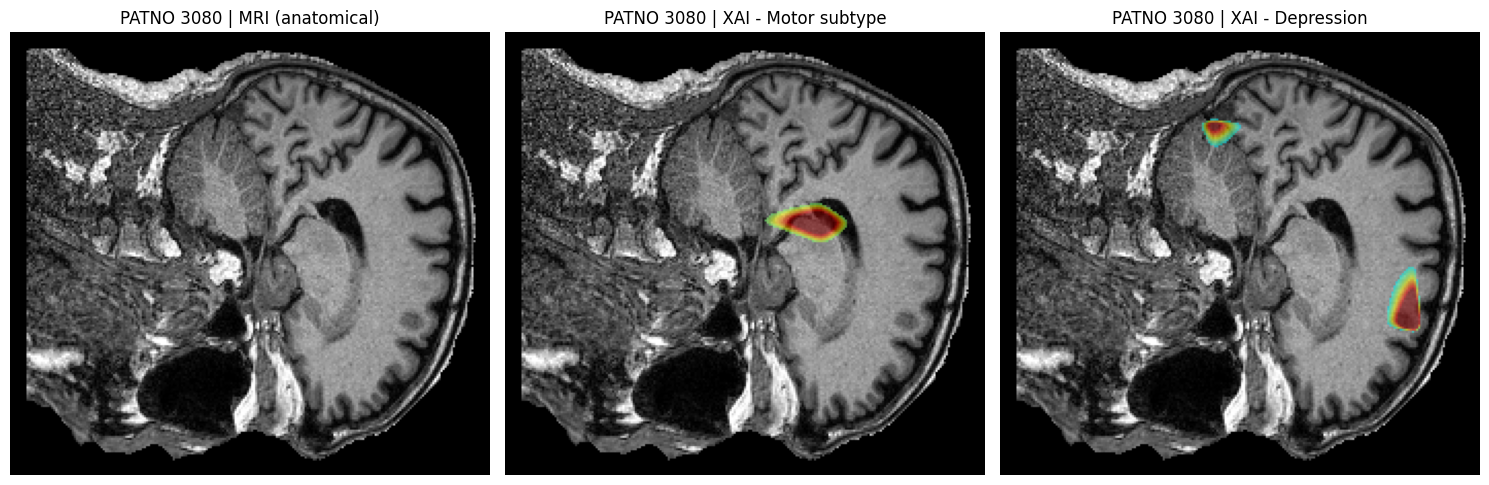



# Clinical Prediction Report for Parkinson's Disease

## Clinical Findings

Patient 3080 is a 80-year-old male evaluated at the T2 prediction horizon.

Sleep-related findings indicate that daytime sleepiness was assessed using ESS variables, including situations such as reading, watching television and resting during daytime activities. REM sleep-related findings include evaluated dream-related manifestations and nocturnal behaviours commonly monitored in Parkinson's disease. Motor findings include evaluated tremor, rigidity, bradykinesia, gait and postural stability domains based on MDS-UPDRS Part III assessments. Non-motor findings include evaluated mood, cognitive, sleep and daily living domains from MDS-UPDRS Part I. Depression-related findings were evaluated using GDS-15 variables describing depressive symptoms. Autonomic findings include urinary, gastrointestinal and cardiovascular domains assessed through SCOPA-AUT.

Motor subtype prediction classified the patient as **PIGD**,

In [17]:
# ============================================================
# 13. GÉNÉRER ET AFFICHER LE RAPPORT DE RÉFÉRENCE (DÉTERMINISTE)
# ============================================================

TARGET_HORIZON = "T2"  # <-- choisis "T2", "T4" ou "T6" selon l'horizon voulu
SHOW_MRI_SLICE = True   # <-- affiche (True) ou non (False) les images MRI/XAI

_horizon_map = {
    "T2": df_T2,
    "T4": df_T4,
    "T6": df_T6,
}

if TARGET_HORIZON not in _horizon_map:
    raise ValueError(f"TARGET_HORIZON invalide: {TARGET_HORIZON}. Choisir parmi {list(_horizon_map.keys())}")

horizon_df = _horizon_map[TARGET_HORIZON]
print(f"horizon_df = df_{TARGET_HORIZON}, shape = {horizon_df.shape}")

TARGET_PATIENT_ID = "3080"

print("\n" + "#" * 130)
print(f"PATIENT: {TARGET_PATIENT_ID} — RAPPORT DE RÉFÉRENCE")
print("#" * 130)

patient_rows = horizon_df[
    horizon_df["patient_id"].astype(str) == str(TARGET_PATIENT_ID)
]

if len(patient_rows) == 0:
    print("Patient not found:", TARGET_PATIENT_ID)
else:
    row = patient_rows.iloc[0].copy()
    row["horizon"] = TARGET_HORIZON

    best_info = prepare_patient_mri_image(get_patient_id_from_row(row))

    reference_report = build_reference_report(row, best_info)

    out_ref_report = os.path.join(
        OUT_DIR,
        f"reference_report_patient_{TARGET_PATIENT_ID}_{TARGET_HORIZON}.txt"
    )

    with open(out_ref_report, "w", encoding="utf-8") as f:
        f.write(reference_report)

    print("Saved reference report:", out_ref_report)

    print("\n" + "=" * 130)
    print(f"REFERENCE REPORT (RULE-BASED) - PATIENT {TARGET_PATIENT_ID} - {TARGET_HORIZON}")
    print("=" * 130)

    if SHOW_MRI_SLICE:
        if best_info.get("mri_available", False):
            show_best_slice(best_info)
        else:
            print(best_info.get("message", "MRI not available."))
        print()

    print(reference_report.rstrip())
    print("\n\n")

In [18]:
# ============================================================
# 10. PROMPT INPUT BUILDERS - Qwen2.5-VL-3B-Instruct
# Python prepares structured inputs only.
# Qwen2.5-VL-3B-Instruct writes the complete report.
# ============================================================


REPORT_SECTIONS = [
    "1. Clinical Findings",
    "2. Clinical Characteristics",
    "3. MRI Slice Visualization",
    "4. Evidence-based Clinical Context",
    "5. Integrated Clinical Impression",
    "6. Clinical Recommendations",
    "7. Conclusion",
]


def find_row_value_by_patterns(row, patterns, default=None):
    for p in patterns:
        for col in row.index:
            if str(col).lower() == str(p).lower() and not is_missing_value(row[col]):
                return row[col]

    for p in patterns:
        toks = [t for t in re.split(r"[^a-zA-Z0-9]+", str(p).lower()) if t]
        if not toks:
            continue
        for col in row.index:
            cn = str(col).lower()
            if all(t in cn for t in toks) and not is_missing_value(row[col]):
                return row[col]

    return default


def to_percent_float(value):
    if is_missing_value(value):
        return None
    try:
        v = float(value)
        if 0 <= v <= 1:
            v *= 100.0
        return v
    except Exception:
        return None


def fmt_percent(value):
    v = to_percent_float(value)
    if v is None:
        return "not available"
    return f"{v:.2f}%"


# ============================================================
# Prediction evidence builder
# ============================================================

def get_prediction_inputs(row):
    used_seeds = find_row_value_by_patterns(row, ["used_seeds", "seeds"], "42,43,44,45,46")

    subtype_label = find_row_value_by_patterns(
        row, ["subtype_label", "motor_subtype", "predicted_subtype"], "not available"
    )

    subtype_conf = to_percent_float(
        find_row_value_by_patterns(row, ["subtype_confidence", "subtype confidence"], None)
    )

    td_prob = to_percent_float(
        find_row_value_by_patterns(row, ["td_probability", "prob_td", "td prob", "probability_td"], None)
    )

    pigd_prob = to_percent_float(
        find_row_value_by_patterns(row, ["pigd_probability", "prob_pigd", "pigd prob", "probability_pigd"], None)
    )

    if td_prob is None and pigd_prob is None and subtype_conf is not None:
        lab = str(subtype_label).lower().strip()
        if lab == "td":
            td_prob = subtype_conf
            pigd_prob = 100 - subtype_conf
        elif lab == "pigd":
            pigd_prob = subtype_conf
            td_prob = 100 - subtype_conf

    depression_label = find_row_value_by_patterns(
        row, ["depression_label", "depression_status", "predicted_depression"], "not available"
    )

    dep_conf = to_percent_float(
        find_row_value_by_patterns(row, ["depression_confidence", "depression confidence"], None)
    )

    dep_pos = to_percent_float(
        find_row_value_by_patterns(
            row, ["depression_positive_probability", "prob_depression_positive", "positive probability"], None
        )
    )

    dep_neg = to_percent_float(
        find_row_value_by_patterns(
            row, ["depression_negative_probability", "prob_depression_negative", "negative probability"], None
        )
    )

    severity_label = find_row_value_by_patterns(
        row, ["severity_label", "depression_severity_label", "predicted_severity"], "not available"
    )

    sev_conf = to_percent_float(
        find_row_value_by_patterns(row, ["severity_confidence", "severity confidence"], None)
    )

    sev_none = to_percent_float(
        find_row_value_by_patterns(row, ["severity_none_probability", "prob_severity_none"], None)
    )

    sev_mild = to_percent_float(
        find_row_value_by_patterns(row, ["severity_mild_probability", "prob_severity_mild"], None)
    )

    sev_moderate = to_percent_float(
        find_row_value_by_patterns(row, ["severity_moderate_probability", "prob_severity_moderate"], None)
    )

    sev_severe = to_percent_float(
        find_row_value_by_patterns(row, ["severity_severe_probability", "prob_severity_severe"], None)
    )

    return {
        "used_seeds": used_seeds,
        "subtype_label": subtype_label,
        "td_probability": fmt_percent(td_prob),
        "pigd_probability": fmt_percent(pigd_prob),
        "subtype_confidence": fmt_percent(subtype_conf),
        "depression_label": depression_label,
        "depression_negative_probability": fmt_percent(dep_neg),
        "depression_positive_probability": fmt_percent(dep_pos),
        "depression_confidence": fmt_percent(dep_conf),
        "severity_label": severity_label,
        "severity_none_probability": fmt_percent(sev_none),
        "severity_mild_probability": fmt_percent(sev_mild),
        "severity_moderate_probability": fmt_percent(sev_moderate),
        "severity_severe_probability": fmt_percent(sev_severe),
        "severity_confidence": fmt_percent(sev_conf),
    }


# ============================================================
# Bloc de probabilités formaté (ligne par ligne), injecté de
# façon GARANTIE en Section 1 (insertion forcée cote Python,
# voir cellule 11).
# ============================================================

def build_probability_block(row):
    """
    Construit un bloc texte listant toutes les probabilités,
    UNE LIGNE PAR VALEUR, destiné à être insere au debut de la
    Section 1 (Clinical Findings) du rapport final.
    """
    pred = get_prediction_inputs(row)

    lines = [
        "Quantitative prediction summary:",
        f"- Motor subtype: {pred['subtype_label']} (TD: {pred['td_probability']}, PIGD: {pred['pigd_probability']}, confidence: {pred['subtype_confidence']})",
        f"- Depression status: {pred['depression_label']} (Negative: {pred['depression_negative_probability']}, Positive: {pred['depression_positive_probability']}, confidence: {pred['depression_confidence']})",
        f"- Depression severity: {pred['severity_label']} (None: {pred['severity_none_probability']}, Mild: {pred['severity_mild_probability']}, Moderate: {pred['severity_moderate_probability']}, Severe: {pred['severity_severe_probability']}, confidence: {pred['severity_confidence']})",
    ]

    return "\n".join(lines)


# ============================================================
# NOUVEAU: paragraphe démographique propre (Patient ID, sexe,
# âge, horizon), injecté de façon GARANTIE en Section 1, AVANT
# le bloc de probabilités. Evite que le modele recopie
# "Patient ID: / Sex: / Age:" de facon brute dans le texte.
# ============================================================

def build_demographics_block(row):
    patient_id = get_patient_id_from_row(row)
    sex = _get_first_value(row, ["sex", "Sex"], "not available")
    age = _get_first_value(row, ["age", "Age"], "not available")
    horizon = _get_first_value(row, ["horizon", "Horizon"], "not available")

    sex_str = str(sex).strip()
    age_str = str(age).strip()

    return (
        f"Patient demographics: Patient ID {patient_id}, "
        f"{sex_str}, {age_str} years old, prediction horizon {horizon}."
    )


# ============================================================
# RAG context
# ============================================================

def ensure_rag_context(row, max_chars=900):
    pred = get_prediction_inputs(row)

    query_parts = []

    subtype_label = pred.get("subtype_label")
    if subtype_label and str(subtype_label).strip().lower() not in ("not available", "nan", "none", ""):
        query_parts.append(f"Parkinson's disease motor subtype {subtype_label}")

    depression_label = pred.get("depression_label")
    if depression_label and str(depression_label).strip().lower() not in ("not available", "nan", "none", ""):
        query_parts.append(f"depression status {depression_label} in Parkinson's disease")

    severity_label = pred.get("severity_label")
    if severity_label and str(severity_label).strip().lower() not in ("not available", "nan", "none", ""):
        query_parts.append(f"depression severity {severity_label}")

    if not query_parts:
        query_parts.append("Parkinson's disease clinical characteristics, motor and non-motor symptoms")

    query = ". ".join(query_parts)

    try:
        return retrieve_rag_context(query, top_k=4, max_chars=max_chars)
    except Exception:
        return "Not available from the current clinical variables."


def summarize_rag_context_for_report(rag_context):
    if rag_context is None:
        return "No specific literature context is available for this case."

    text = str(rag_context).strip()

    if text == "" or text.lower() in ("nan", "none", "not available from the current clinical variables."):
        return "No specific literature context is available for this case."

    text = re.sub(r"\s+", " ", text)

    return truncate_text(text, max_chars=900)


def build_rag_summary_input(row, max_chars=900):
    rag_context = ensure_rag_context(row, max_chars=max_chars)
    return summarize_rag_context_for_report(rag_context)


def truncate_text(text, max_chars=2300):
    if text is None:
        return ""
    text = str(text)
    if len(text) <= max_chars:
        return text
    return text[:max_chars].rstrip() + "..."


# ============================================================
# FINAL QWEN2.5-VL REPORT PROMPT
# ============================================================

def build_single_qwen25vl_report_prompt(row, best_info):

    patient_id = get_patient_id_from_row(row)
    sex = _get_first_value(row, ["sex", "Sex"], "Not available")
    age = _get_first_value(row, ["age", "Age"], "Not available")
    horizon = _get_first_value(row, ["horizon", "Horizon"], "Not available")

    clinical_text = truncate_text(get_raw_clinical_summary(row), max_chars=2300)

    pred = get_prediction_inputs(row)
    rag_summary = build_rag_summary_input(row, max_chars=900)

    if best_info.get("mri_available", False):
        n_images = len(best_info.get("image_paths", []))
        image_descriptions = []
        if best_info.get("mri_path"):
            image_descriptions.append("an anatomical MRI image (2D)")
        if best_info.get("xai_subtype_path"):
            image_descriptions.append("a supporting 2D visual reference associated with the motor subtype assessment")
        if best_info.get("xai_depression_path"):
            image_descriptions.append("a supporting 2D visual reference associated with the depression assessment")

        mri_input = (
            f"Patient imaging available: yes ({n_images} image(s) attached). "
            f"The attached images are: {', '.join(image_descriptions)}. "
            "These images are provided for visual context only and must be described "
            "anatomically/visually, without inventing findings and without providing an "
            "independent diagnostic interpretation based on them."
        )
    else:
        mri_input = (
            "Patient imaging available: no. "
            "No image-based visualization is available for this patient."
        )

    prediction_text = (
        f"Mean-seed prediction evidence: used seeds {pred['used_seeds']}. "
        f"Motor subtype predicted label: {pred['subtype_label']}; "
        f"TD probability: {pred['td_probability']}; "
        f"PIGD probability: {pred['pigd_probability']}; "
        f"Depression status: {pred['depression_label']}; "
        f"Negative probability: {pred['depression_negative_probability']}; "
        f"Positive probability: {pred['depression_positive_probability']}; "
        f"Depression severity: {pred['severity_label']}."
    )

    prompt = f"""
You are Qwen2.5-VL-3B-Instruct acting as a professional scientific medical report writer specialized in Parkinson's disease.

Generate one complete clinical report using only the provided information.

BEGIN INPUT DATA

Patient ID:
{patient_id}

Sex:
{sex}

Age:
{age}

Prediction horizon:
{horizon}

Clinical variables:
{clinical_text}

MRI information:
{mri_input}

Prediction results:
{prediction_text}

Scientific evidence:
{rag_summary}

END INPUT DATA


STRICT OUTPUT RULES:

Output only the final report.

Start directly with:

1. Clinical Findings

The report must contain exactly these seven sections:

1. Clinical Findings
2. Clinical Characteristics
3. MRI Slice Visualization
4. Evidence-based Clinical Context
5. Integrated Clinical Impression
6. Clinical Recommendations
7. Conclusion

Formatting rules for section titles (MANDATORY, apply to ALL seven titles):
Write every section title EXACTLY as shown above (number, period, space, then the title text), ALONE on its own line, as plain text.
Never write a section title in the middle of a sentence or paragraph.
Do NOT use Markdown headers (no #, ##, ###).
Do NOT use bold or italic markers (no **, no _).
Never drop the leading number of a section title.
Never write a title without its number (for example "Clinical Findings" alone is forbidden; it must be "1. Clinical Findings").

MANDATORY SPACING RULE:
Leave exactly ONE blank line before each section title and ONE blank line after each section title, so every section is clearly visually separated from the others. Never run two sections together without a blank line between them.

Do not repeat the same word more than twice in a row anywhere in the report.
Do not repeat the same sentence or the same section anywhere in the report.

Do NOT restate "Patient ID:", "Sex:", "Age:", or "Prediction horizon:" as standalone lines anywhere in the report; this demographic information is already handled separately.

Section 1 (Clinical Findings) MUST explicitly state the quantitative prediction results (motor subtype, depression status, depression severity, and their associated probabilities) as part of its narrative, with the exact numeric percentages provided above. Do not create a separate section for the prediction results.

Write connected medical paragraphs.

Do not use bullet points.

Do not mention:
Python, code, prompt, RAG, FAISS, embeddings, SHAP, model internals.

Do not invent MRI abnormalities.

Do not diagnose Parkinson disease only from MRI.

Use cautious medical language.

MRI must only be described anatomically.

Clinical recommendations must remain general.

FINAL REPORT:
""".strip()

    return prompt

In [19]:
# ============================================================
# 11. TRUE SINGLE-QWEN2.5-VL-3B-INSTRUCT REPORT GENERATOR
# (STRICT: ONE MODEL CALL -> ONE REPORT, NO CONTINUATIONS)
# ============================================================


# ============================================================
# NOUVEAU: force chaque titre de section a etre SEUL sur sa
# propre ligne, meme si le modele l'a colle a la fin de la
# phrase precedente (ex: "...quality of life. 6. Clinical
# Recommendations Continue..."). Sans cela, tout decoupage base
# sur "titre en debut de ligne" rate le titre et la section
# entiere reste fusionnee dans la precedente.
# ============================================================

def force_line_breaks_before_titles(text):
    text = str(text)

    for title in REPORT_SECTIONS:
        m = re.match(r"^(\d+)\.\s*(.+)$", title)
        num, txt = m.group(1), m.group(2)
        deco = r"[\s#>\*_\-]{0,10}"
        pattern = re.compile(
            deco + re.escape(num) + r"[\.\)]?" + deco + re.escape(txt) + deco,
            flags=re.IGNORECASE
        )
        text = pattern.sub("\n\n" + title + "\n", text)

    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()


# ============================================================
# NOUVEAU: supprime les lignes ou le modele a recopie
# brutalement "Patient ID: ...", "Sex: ...", "Age: ...",
# "Prediction horizon: ..." (remplacees par notre propre
# paragraphe demographique controle, voir
# build_demographics_block + inject_probability_block_into_section1).
# ============================================================

def strip_leaked_demographic_lines(text):
    text = str(text)

    patterns = [
        r"(?im)^\s*Patient\s*ID\s*:\s*.*$",
        r"(?im)^\s*Sex\s*:\s*.*$",
        r"(?im)^\s*Age\s*:\s*.*$",
        r"(?im)^\s*Prediction\s*horizon\s*:\s*.*$",
    ]

    for pat in patterns:
        text = re.sub(pat, "", text)

    text = re.sub(r"\n{3,}", "\n\n", text).strip()
    return text


def _flexible_title_pattern(title):
    m = re.match(r"^(\d+)\.\s*(.+)$", title)
    num, txt = m.group(1), m.group(2)
    deco = r"[\s#>\*_\-]{0,10}"
    return deco + re.escape(num) + r"[\.\)]?" + deco + re.escape(txt) + deco


def _canonicalize_section_titles(text):
    for title in REPORT_SECTIONS:
        pattern = re.compile(r"(?im)^" + _flexible_title_pattern(title) + r"$")
        text = pattern.sub(title, text)

    for title in REPORT_SECTIONS:
        m = re.match(r"^(\d+)\.\s*(.+)$", title)
        txt = m.group(2)
        deco = r"[\s#>\*_\-]{0,10}"
        unnumbered_pattern = re.compile(r"(?im)^" + deco + re.escape(txt) + deco + r"$")
        text = unnumbered_pattern.sub(title, text)

    return text


def collapse_repeated_words(text, max_repeats=2):
    tokens = re.findall(r"\S+|\s+", str(text))
    out = []
    run_word = None
    run_count = 0

    for tok in tokens:
        if tok.strip() == "":
            out.append(tok)
            continue

        norm = re.sub(r"[^\w]", "", tok.lower())

        if norm and norm == run_word:
            run_count += 1
            if run_count <= max_repeats:
                out.append(tok)
        else:
            run_word = norm
            run_count = 1
            out.append(tok)

    return "".join(out)


def clean_final_report_only(text):
    text = str(text)
    text = collapse_repeated_words(text)

    text = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL | re.IGNORECASE)
    text = text.replace("<think>", "").replace("</think>", "")

    text = re.sub(r"```.*?```", "", text, flags=re.DOTALL).strip()

    # NOUVEAU: force d'abord chaque titre sur sa propre ligne, AVANT
    # toute autre logique basee sur "titre en debut de ligne".
    text = force_line_breaks_before_titles(text)

    text = _canonicalize_section_titles(text)

    for marker in ["FINAL REPORT:", "BEGIN FINAL REPORT"]:
        if marker in text:
            text = text.split(marker)[-1].strip()

    text = re.sub(r"BEGIN INPUT DATA[\s\S]*?END INPUT DATA", "", text, flags=re.IGNORECASE).strip()

    section1_pattern = re.compile(r"(?im)^[\s#>\*_\-]{0,10}1\.?\s*Clinical Findings[\s:\*_#]{0,10}$")

    starts = [m.start() for m in section1_pattern.finditer(text)]

    if starts:
        text = text[starts[0]:].strip()
        starts_again = [m.start() for m in section1_pattern.finditer(text)]
        if len(starts_again) > 1:
            text = text[:starts_again[1]].rstrip()

    for marker in ["Notes:", "Explanation:", "Reasoning:", "Prompt:", "Input information:", "INPUT DATA:"]:
        if marker in text:
            text = text.split(marker)[0].strip()

    text = re.sub(r"\n\s*[-•]\s+", " ", text)
    text = re.sub(r"\s+-\s+", " ", text)

    text = re.sub(
        r"normal appearance without visible lesions, tumors, infarcts, vascular lesions, atrophy, hemorrhage, or abnormalities",
        "no definite focal radiological abnormality that can be confirmed from this single selected 2D MRI slice",
        text,
        flags=re.IGNORECASE
    )

    text = re.sub(
        r"without visible lesions, tumors, infarcts, vascular lesions, atrophy, hemorrhage, or abnormalities",
        "without a definite focal radiological abnormality that can be confirmed from this single selected 2D MRI slice",
        text,
        flags=re.IGNORECASE
    )

    # NOUVEAU: supprime les lignes ou le modele a recopie brutalement
    # Patient ID / Sex / Age / Prediction horizon.
    text = strip_leaked_demographic_lines(text)

    text = re.sub(r"\n{3,}", "\n\n", text).strip()

    return text


def _normalize_sentence_for_dedup(sentence):
    s = sentence.lower().strip()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[^\w\s]", "", s)
    return s


def remove_redundant_report_content(report_text, similarity_threshold=0.85):
    # NOUVEAU: re-force les sauts de ligne avant les titres, au cas ou
    # le nettoyage precedent n'aurait pas tout capture.
    report_text = force_line_breaks_before_titles(str(report_text))

    titles_pattern = (
        r"(?im)^[\s#>\*_\-]{0,10}("
        + "|".join(re.escape(t) for t in REPORT_SECTIONS)
        + r")[\s:\*_#]{0,10}$"
    )

    parts = re.split(titles_pattern, report_text)

    seen_norm_sentences = []

    def is_duplicate(norm_sentence):
        for prev in seen_norm_sentences:
            if norm_sentence == prev:
                return True
            if len(norm_sentence) > 20 and len(prev) > 20:
                ratio = difflib.SequenceMatcher(None, norm_sentence, prev).ratio()
                if ratio >= similarity_threshold:
                    return True
        return False

    section_blocks = {}
    section_order = []
    idx = 1

    while idx < len(parts):
        title = parts[idx]
        content = parts[idx + 1] if idx + 1 < len(parts) else ""
        idx += 2

        if title in section_blocks:
            pass
        else:
            section_blocks[title] = content
            section_order.append(title)

    preamble = parts[0].strip() if parts else ""
    rebuilt = [preamble] if preamble else []

    for title in REPORT_SECTIONS:
        if title not in section_blocks:
            continue

        content = section_blocks[title]
        sentences = re.split(r"(?<=[.!?])\s+", content.strip())
        kept_sentences = []

        for sentence in sentences:
            sentence = sentence.strip()
            if not sentence:
                continue

            norm = _normalize_sentence_for_dedup(sentence)

            if len(norm) < 8:
                kept_sentences.append(sentence)
                continue

            if is_duplicate(norm):
                continue

            seen_norm_sentences.append(norm)
            kept_sentences.append(sentence)

        rebuilt.append("\n" + title + "\n\n" + " ".join(kept_sentences) + "\n")

    cleaned = "\n".join(rebuilt).strip()
    cleaned = re.sub(r"\n{3,}", "\n\n", cleaned)

    return cleaned


def check_sections(report):
    found = []
    missing = []

    for title in REPORT_SECTIONS:
        if re.search(rf"{re.escape(title)}", str(report), flags=re.IGNORECASE):
            found.append(title)
        else:
            missing.append(title)

    return found, missing


def _looks_like_raw_dump(text, threshold=6):
    lines = [l for l in str(text).splitlines() if l.strip()]
    if not lines:
        return False
    kv_like = sum(1 for l in lines if re.match(r"^\s*[A-Za-z0-9_]{2,40}\s*[:=]\s*\S", l))
    return kv_like >= threshold


def fix_motor_subtype_terminology(text):
    text = str(text)
    text = re.sub(r"[\u2010-\u2015\u2212]", "-", text)

    wrong_patterns = [
        r"parkinsonism[\s\-]?dementia complex\s*\(\s*PIGD\s*\)",
        r"parkinsonism[\s\-]?dementia complex\s*\(\s*PDG\s*\)",
        r"parkinsonism[\s\-]?dementia complex\s*\(\s*PDC\s*\)",
        r"parkinsonism[\s\-]?dementia complex\s*\(\s*PGD\s*\)",
        r"parkinsonism[\s\-]?dementia complex",
        r"\bPDG\b",
        r"\bPDC\b",
        r"\bPGD\b",
    ]

    for pat in wrong_patterns:
        text = re.sub(pat, "PIGD (Postural Instability Gait Difficulty)", text, flags=re.IGNORECASE)

    text = re.sub(
        r"PIGD \(Postural Instability Gait Difficulty\)(\s*\(Postural Instability Gait Difficulty\))+",
        "PIGD (Postural Instability Gait Difficulty)",
        text,
        flags=re.IGNORECASE
    )

    return text


# ============================================================
# NOUVEAU: injection forcée du paragraphe démographique PUIS
# du bloc de probabilités en Section 1, chacun dans son propre
# paragraphe, AVANT le contenu genere par le modele. Insertion
# 100% garantie, independante de ce que le modele a ecrit.
# ============================================================

def inject_probability_block_into_section1(report_text, probability_block, demographics_block):
    text = str(report_text)

    section1_pattern = re.compile(r"(?im)^1\.\s*Clinical Findings\s*$")
    match = section1_pattern.search(text)

    combined_block = f"{demographics_block}\n\n{probability_block}"

    if not match:
        return f"1. Clinical Findings\n\n{combined_block}\n\n{text}".strip()

    insert_pos = match.end()
    before = text[:insert_pos]
    after = text[insert_pos:].lstrip("\n")

    return f"{before}\n\n{combined_block}\n\n{after}"


# ============================================================
# NOUVEAU: garantit une ligne vide avant et apres CHAQUE titre
# de section, sur le rapport final complet (derniere passe de
# securite, apres toutes les autres transformations).
# ============================================================

def enforce_section_spacing(text):
    text = str(text)
    text = force_line_breaks_before_titles(text)

    for title in REPORT_SECTIONS:
        pattern = re.compile(r"(?im)^" + re.escape(title) + r"\s*$")
        text = pattern.sub(lambda m: "\n" + title + "\n", text)

    text = re.sub(r"\n{3,}", "\n\n", text).strip()
    return text


def enforce_single_report_display(report_text):
    text = str(report_text).strip()

    conclusion_pattern = re.compile(r"(?im)^[\s#>\*_\-]{0,10}7\.?\s*Conclusion[\s:\*_#]{0,10}$")
    section1_pattern = re.compile(r"(?im)^[\s#>\*_\-]{0,10}1\.?\s*Clinical Findings[\s:\*_#]{0,10}$")

    conclusion_matches = [m.start() for m in conclusion_pattern.finditer(text)]

    if len(conclusion_matches) > 1:
        text = text[:conclusion_matches[1]].rstrip()
    elif len(conclusion_matches) == 1:
        tail_start = conclusion_matches[0]
        restart_match = section1_pattern.search(text, tail_start + 20)
        if restart_match:
            text = text[:restart_match.start()].rstrip()

    n = len(text)
    if n > 400:
        mid = n // 2
        first_half = _normalize_sentence_for_dedup(text[:mid])[:2000]
        second_half = _normalize_sentence_for_dedup(text[mid:])[:2000]

        ratio = difflib.SequenceMatcher(None, first_half, second_half).ratio()

        if ratio >= 0.55:
            text = text[:mid].rstrip()

    text = fix_motor_subtype_terminology(text)

    # Force la separation ligne-par-ligne de chaque section en tout
    # dernier lieu, apres toutes les autres transformations.
    text = enforce_section_spacing(text)

    return text


def generate_qwen25vl_complete_report_for_row(
    row,
    max_new_tokens=1800,
    show_prompt=False,
):
    patient_id = get_patient_id_from_row(row)
    best_info = prepare_patient_mri_image(patient_id)

    image_paths = (
        best_info.get("image_paths", [])
        if best_info.get("mri_available", False)
        else []
    )

    prompt = build_single_qwen25vl_report_prompt(row, best_info)

    if show_prompt:
        print("========== PROMPT SENT TO QWEN2.5-VL-3B-INSTRUCT ==========")
        print(prompt)
        print("===========================================================")

    print("Calling Qwen2.5-VL-3B-Instruct ONCE for the complete 7-section report...")

    raw_qwen_output = qwen_vlm_chat_generate(
        text_prompt=prompt,
        image_paths=image_paths,
        max_new_tokens=max_new_tokens
    )

    report = clean_final_report_only(raw_qwen_output)
    report = remove_redundant_report_content(report)

    # NOUVEAU: injection GARANTIE de la demographie + probabilites
    # en Section 1, quelle que soit la sortie brute du modele.
    probability_block = build_probability_block(row)
    demographics_block = build_demographics_block(row)
    report = inject_probability_block_into_section1(report, probability_block, demographics_block)

    report = enforce_single_report_display(report)

    found, missing = check_sections(report)

    if missing:
        print(
            "Note: the following sections were not found after the "
            "single generation call (no retry is performed by design):",
            missing
        )

    return report, raw_qwen_output, best_info

In [20]:
# ============================================================
# 0. MONTER GOOGLE DRIVE (à faire une seule fois par session)
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

# Dossier de sauvegarde persistant dans ton Drive
OUT_DIR = "/content/drive/MyDrive/qwen25vl_rapports"
os.makedirs(OUT_DIR, exist_ok=True)

print(f"Les rapports seront sauvegardés dans : {OUT_DIR}")

Mounted at /content/drive
Les rapports seront sauvegardés dans : /content/drive/MyDrive/qwen25vl_rapports


In [21]:
# ============================================================
# 12. TEST PATIENT(S) (Qwen2.5-VL-3B) - STRICT SINGLE REPORT
#     avec reprise automatique + sauvegarde Google Drive
# ============================================================
TARGET_HORIZONS =  ["T2", "T4", "T6"]   # <-- modifie ici selon besoin
MIN_HORIZONS = 1                 # <-- 1 = patients avec >=1 temps, 2 = >=2 temps
MAX_PATIENTS = 50                 # <-- nombre max de patients traités
SHOW_MRI_SLICE = True
MAX_DISPLAY = 5                   # <-- nombre max de rapports affichés dans Colab
SKIP_IF_EXISTS = True             # <-- reprise automatique : saute les rapports déjà générés

horizon_map = {
    "T2": df_T2,
    "T4": df_T4,
    "T6": df_T6
}

# --- validation des horizons demandés ---
valid_horizons = [h for h in TARGET_HORIZONS if h in horizon_map and horizon_map[h] is not None and len(horizon_map[h]) > 0]

if len(valid_horizons) == 0:
    print("Aucun dataframe disponible pour les horizons demandés:", TARGET_HORIZONS)

else:

    # --- horizons disponibles par patient ---
    patient_available_horizons = {}

    for h in valid_horizons:
        ids_h = horizon_map[h]["patient_id"].dropna().astype(str).unique()
        for pid in ids_h:
            patient_available_horizons.setdefault(pid, [])
            if h not in patient_available_horizons[pid]:
                patient_available_horizons[pid].append(h)

    horizon_order = ["T2", "T4", "T6"]
    for pid in patient_available_horizons:
        patient_available_horizons[pid] = [
            h for h in horizon_order if h in patient_available_horizons[pid]
        ]

    # --- sélection des patients respectant MIN_HORIZONS, limitée à MAX_PATIENTS ---
    patient_ids = [
        pid for pid, hs in patient_available_horizons.items()
        if len(hs) >= MIN_HORIZONS
    ][:MAX_PATIENTS]

    print(f"\nTesting {len(patient_ids)} patient(s) (max {MAX_PATIENTS}) sur horizon(s) demandés "
          f"{valid_horizons} (MIN_HORIZONS={MIN_HORIZONS})...\n")

    total_reports = 0
    for pid in patient_ids:
        avail = patient_available_horizons[pid]
        total_reports += len(avail)
    print(f"Total rapports à traiter : {total_reports}")
    print(f"Rapports affichés dans Colab : les {min(MAX_DISPLAY, total_reports)} premiers NON-SKIPPÉS\n")

    report_counter = 0
    display_counter = 0
    skipped_count = 0
    generated_count = 0

    for TARGET_PATIENT_ID in patient_ids:

        available_for_patient = patient_available_horizons[TARGET_PATIENT_ID]

        for TARGET_HORIZON in available_for_patient:

            report_counter += 1

            horizon_df = horizon_map[TARGET_HORIZON]

            patient_rows = horizon_df[
                horizon_df["patient_id"].astype(str) == str(TARGET_PATIENT_ID)
            ]

            if len(patient_rows) == 0:
                continue

            out_report = os.path.join(
                OUT_DIR,
                f"qwen25vl_generated_report_patient_{TARGET_PATIENT_ID}_{TARGET_HORIZON}.txt"
            )
            out_raw = os.path.join(
                OUT_DIR,
                f"qwen25vl_raw_output_patient_{TARGET_PATIENT_ID}_{TARGET_HORIZON}.txt"
            )
            out_json = os.path.join(
                OUT_DIR,
                f"qwen25vl_mri_metadata_patient_{TARGET_PATIENT_ID}_{TARGET_HORIZON}.json"
            )

            # =====================================================
            # SKIP si déjà généré (reprise après coupure GPU/session)
            # =====================================================
            if SKIP_IF_EXISTS and os.path.exists(out_report) and os.path.exists(out_json):
                skipped_count += 1
                print(f"[{report_counter}/{total_reports}] Patient {TARGET_PATIENT_ID} - {TARGET_HORIZON} "
                      f"-> DEJA GENERE (Drive), skip.")
                continue

            should_display = display_counter < MAX_DISPLAY

            if should_display:
                print("\n" + "#" * 130)
                print(f"PATIENT: {TARGET_PATIENT_ID}  |  HORIZON: {TARGET_HORIZON}  "
                      f"({available_for_patient.index(TARGET_HORIZON)+1}/{len(available_for_patient)})  "
                      f"[{report_counter}/{total_reports}]")
                print("#" * 130)

            row = patient_rows.iloc[0].copy()
            row["horizon"] = TARGET_HORIZON

            # =====================================================
            # Qwen2.5-VL-3B inference - SINGLE CALL, SINGLE REPORT
            # =====================================================
            report, raw_output, best_info = generate_qwen25vl_complete_report_for_row(
                row,
                max_new_tokens=1800
            )

            found, missing = check_sections(report)
            generated_count += 1

            if should_display:
                print("Sections found :", found)
                print("Sections missing:", missing)

            # =====================================================
            # Save outputs IMMEDIATEMENT dans Drive
            # =====================================================
            with open(out_report, "w", encoding="utf-8") as f:
                f.write(report)
            with open(out_raw, "w", encoding="utf-8") as f:
                f.write(raw_output)
            with open(out_json, "w", encoding="utf-8") as f:
                json.dump(best_info, f, indent=2, ensure_ascii=False)

            if should_display:
                print("Saved report :", out_report)
                print("Saved raw output :", out_raw)
                print("Saved MRI metadata :", out_json)

                def print_report_with_inline_image(report_text, best_info, show_image=True):
                    if show_image:
                        if best_info.get("mri_available", False):
                            show_best_slice(best_info)
                        else:
                            print(best_info.get("message", "MRI not available."))
                        print()
                    print(report_text.rstrip())

                print("\n" + "=" * 130)
                print(f"FINAL QWEN2.5-VL-3B REPORT - PATIENT {TARGET_PATIENT_ID} - {TARGET_HORIZON}")
                print("=" * 130)

                print_report_with_inline_image(report, best_info, show_image=SHOW_MRI_SLICE)
                print("\n\n")

                display_counter += 1

            else:
                print(f"[{report_counter}/{total_reports}] Patient {TARGET_PATIENT_ID} - {TARGET_HORIZON} "
                      f"-> généré et sauvegardé dans Drive (non affiché) : {out_report}")

    print(f"\nTerminé. {generated_count} rapport(s) généré(s) cette session, "
          f"{skipped_count} déjà existant(s) sautés (repris depuis Drive), "
          f"{report_counter} au total traités.")
    print(f"Tous les rapports sont dans : {OUT_DIR}")


Testing 50 patient(s) (max 50) sur horizon(s) demandés ['T2', 'T4', 'T6'] (MIN_HORIZONS=1)...

Total rapports à traiter : 60
Rapports affichés dans Colab : les 5 premiers NON-SKIPPÉS

[1/60] Patient 3066 - T2 -> DEJA GENERE (Drive), skip.
[2/60] Patient 3080 - T2 -> DEJA GENERE (Drive), skip.
[3/60] Patient 3086 - T2 -> DEJA GENERE (Drive), skip.
[4/60] Patient 3120 - T2 -> DEJA GENERE (Drive), skip.
[5/60] Patient 3120 - T6 -> DEJA GENERE (Drive), skip.
[6/60] Patient 3122 - T2 -> DEJA GENERE (Drive), skip.
[7/60] Patient 3131 - T2 -> DEJA GENERE (Drive), skip.
[8/60] Patient 3134 - T2 -> DEJA GENERE (Drive), skip.
[9/60] Patient 3162 - T2 -> DEJA GENERE (Drive), skip.
[10/60] Patient 3168 - T2 -> DEJA GENERE (Drive), skip.
[11/60] Patient 3174 - T2 -> DEJA GENERE (Drive), skip.
[12/60] Patient 3180 - T2 -> DEJA GENERE (Drive), skip.
[13/60] Patient 3180 - T4 -> DEJA GENERE (Drive), skip.
[14/60] Patient 3209 - T2 -> DEJA GENERE (Drive), skip.
[15/60] Patient 3209 - T4 -> DEJA GENERE

In [ ]:
# ============================================================
# FICHIER 1/2 : METRICS LIBRARY
# ============================================================

import re
import math
import pandas as pd
from collections import Counter
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


# ============================================================
# REPORT QUALITY METRICS
# ALL METRICS COMPARED AGAINST THE REFERENCE REPORT (template_report)
# ============================================================
#
# >>> VERSION "ANTI-HALLUCINATION MOINS STRICTE" <
# Les changements par rapport à la version originale sont marqués par
# des commentaires "# [MOINS STRICT]" pour que ce soit facile à repérer.
#
# >>> AJOUTS DE CETTE VERSION <
# - bertscore_manual   : score sémantique offline (TF-IDF cosinus), sans
#                        modèle ni accès internet
# - radgraph_manual    : approximation offline de RadGraph (entités +
#                        relations entité/modificateur de sévérité)
# ============================================================


# =========================
# TEXT HELPERS
# =========================

def normalize_text(text):
    text = str(text).lower()
    text = text.replace("’", "'")
    text = re.sub(r"[_\-]+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def extract_numbers(text):
    nums = re.findall(r"\d+(?:\.\d+)?", str(text))
    return [float(x) for x in nums]


def is_missing_value(value):
    if value is None:
        return True

    if isinstance(value, float) and pd.isna(value):
        return True

    if str(value).strip().lower() in ["", "nan", "none", "not available"]:
        return True

    return False


def get_row_value(row, candidates, default=None):
    for col in candidates:
        if col in row.index and not is_missing_value(row[col]):
            return row[col]
    return default


# =========================
# NEGATION-AWARE / WORD-BOUNDARY KEYWORD MATCHING
# =========================

NEGATION_TERMS = [
    "no ", "not ", "without", "absent", "absence of", "denies", "denied",
    "negative for", "ruled out", "unremarkable for", "aucun ", "aucune ",
    "pas de ", "sans ", "absence de "
]


def _is_negated(text_norm, match_start, window_chars=40):
    """Return True if a negation term appears just before the match."""
    context = text_norm[max(0, match_start - window_chars):match_start]
    return any(neg in context for neg in NEGATION_TERMS)


def _keyword_positions(text_norm, keyword, check_negation=True):
    """
    Find keyword occurrences using real word boundaries (avoids
    substring false positives, e.g. "age" no longer matches inside
    "damage", "manage", "stage", "average"...), optionally discarding
    matches that are immediately preceded by a negation.
    """
    kw_norm = normalize_text(keyword)
    if len(kw_norm) == 0:
        return []

    pattern = r"(?<!\w)" + re.escape(kw_norm) + r"(?!\w)"
    positions = []

    for m in re.finditer(pattern, text_norm):
        if check_negation and _is_negated(text_norm, m.start()):
            continue
        positions.append(m.start())

    return positions


# =========================
# SECTION PRESENCE (used by Structure)
# =========================

def section_present(report_norm, aliases):
    return any(normalize_text(a) in report_norm for a in aliases)


REQUIRED_SECTIONS = {
    "clinical_findings": [
        "1. Clinical Findings",
        "Clinical Findings"
    ],
    "clinical_characteristics": [
        "2. Clinical Characteristics",
        "Clinical Characteristics"
    ],
    "quantitative_results": [
        "3. Quantitative Prediction Results",
        "3. Quantitative AI Prediction Results",
        "Quantitative Prediction Results",
        "Quantitative AI Prediction Results",
        "Prediction Results"
    ],
    "evidence_context": [
        "4. Evidence-based Clinical Context",
        "Evidence-based Clinical Context",
        "Literature-based Clinical Context",
        "Clinical Context"
    ],
    "integrated_impression": [
        "5. Integrated Clinical Impression",
        "Integrated Clinical Impression",
        "Integrated Clinical Interpretation"
    ],
    "recommendations": [
        "6. Clinical Recommendations",
        "Clinical Recommendations",
        "Recommendations"
    ],
    "conclusion": [
        "7. Conclusion",
        "Conclusion"
    ],
}


# =========================
# STRUCTURE SCORE (reference-based)
# =========================

def structure_score(reference_report, report):
    """
    A section is only REQUIRED if the reference report itself contains
    that section. Score = fraction of the reference's own sections that
    are also found in the generated report.
    """
    if reference_report is None or len(str(reference_report).strip()) == 0:
        return None

    report_norm = normalize_text(report)
    ref_norm = normalize_text(reference_report)

    required_in_ref = [
        key for key, aliases in REQUIRED_SECTIONS.items()
        if section_present(ref_norm, aliases)
    ]

    if len(required_in_ref) == 0:
        return None

    found = sum(
        1 for key in required_in_ref
        if section_present(report_norm, REQUIRED_SECTIONS[key])
    )

    return found / len(required_in_ref)


# ============================================================
# MEDICAL COVERAGE SCORE (WEIGHTED)
# ============================================================

MEDICAL_CONCEPTS_WEIGHTED = {

    "parkinson": (
        [
            "parkinson",
            "parkinson's disease",
            "pd",
            "parkinsonism"
        ],
        0.20
    ),

    "patient_information": (
        [
            "patient",
            "age",
            "sex",
            "female",
            "male"
        ],
        0.10
    ),

    "motor_profile": (
        [
            "motor",
            "subtype",
            "td",
            "pigd",
            "tremor",
            "gait",
            "rigidity",
            "updrs"
        ],
        0.20
    ),

    "depression": (
        [
            "depression",
            "depressive",
            "gds",
            "severity"
        ],
        0.15
    ),

    "prediction": (
        [
            "prediction",
            "probability",
            "confidence",
            "classification",
            "result"
        ],
        0.15
    ),

    "clinical_context": (
        [
            "clinical",
            "interpretation",
            "assessment",
            "profile"
        ],
        0.10
    ),

    "recommendation": (
        [
            "recommend",
            "follow up",
            "monitor"
        ],
        0.10
    )
}



def medical_coverage_score(reference_report, report):

    report_norm = normalize_text(report)

    total_score = 0

    for concept, (keywords, weight) in MEDICAL_CONCEPTS_WEIGHTED.items():

        found = sum(
            1 for kw in keywords
            if normalize_text(kw) in report_norm
        )

        # saturation : plusieurs mots du même concept n'augmentent pas trop
        if found >= 2:
            concept_score = 1
        elif found == 1:
            concept_score = 0.7
        else:
            concept_score = 0


        total_score += weight * concept_score


    return round(total_score, 4)


# =========================
# MEDICAL COVERAGE - DEBUG / DIAGNOSTIC (reference-based)
# =========================
def medical_coverage_debug(reference_report, report, min_distinct_synonyms=2, check_negation=True):
    """
    Same logic as medical_coverage_score, but returns a detailed
    breakdown per category / sub-topic: whether the reference report
    requires it, whether the generated report satisfies it, and which
    synonyms were actually found in each.

    NOTE: requires REQUIRED_TOPICS to be defined (dict of
    {category: [ [synonym1, synonym2, ...], ... ]}). It is not defined
    anywhere in this file as provided.
    """
    if reference_report is None or len(str(reference_report).strip()) == 0:
        print("No reference report available - nothing to compare against.")
        return None, None
    report_norm = normalize_text(report)
    ref_norm = normalize_text(reference_report)
    rows = []
    for category, groups in REQUIRED_TOPICS.items():
        for synonyms in groups:
            required = min(min_distinct_synonyms, len(synonyms))
            ref_found = [
                kw for kw in synonyms
                if len(_keyword_positions(ref_norm, kw, check_negation)) > 0
            ]
            gen_found = [
                kw for kw in synonyms
                if len(_keyword_positions(report_norm, kw, check_negation)) > 0
            ]
            required_by_ref = len(ref_found) >= required
            passed = (not required_by_ref) or (len(gen_found) >= required)
            rows.append({
                "category": category,
                "synonyms_checked": synonyms,
                "required_count": required,
                "required_by_reference": required_by_ref,
                "found_in_reference": ref_found,
                "found_in_generated": gen_found,
                "passed": passed
            })
    debug_df = pd.DataFrame(rows)
    applicable_df = debug_df[debug_df["required_by_reference"]]
    if len(applicable_df) == 0:
        print("Reference report doesn't clearly require any sub-topic - check its content.")
        return debug_df, None
    category_summary = (
        applicable_df.groupby("category")["passed"]
        .agg(["sum", "count"])
        .rename(columns={"sum": "passed_subgroups", "count": "required_subgroups"})
    )
    category_summary["score"] = category_summary["passed_subgroups"] / category_summary["required_subgroups"]
    return debug_df, category_summary


# =========================
# ANTI-HALLUCINATION SCORE (reference-based, VERSION MOINS STRICTE)
# =========================

def split_clinical_claims(report):
    raw_claims = re.split(r"[.\n;]+", str(report))
    claims = []

    for claim in raw_claims:
        claim = claim.strip()

        if len(claim) < 15:
            continue

        if re.match(r"^\d+\.\s*[A-Za-z \-]+$", claim):
            continue

        claims.append(claim)

    return claims


def add_terms_from_text(text, evidence_terms):
    text_norm = normalize_text(text)

    if len(text_norm) > 0:
        evidence_terms.append(text_norm)

    tokens = re.findall(r"[a-zA-Z][a-zA-Z0-9']+", text_norm)

    for tok in tokens:
        if len(tok) >= 4:
            evidence_terms.append(tok)

    phrases = re.findall(
        r"[a-zA-Z][a-zA-Z0-9'\-]+(?:\s+[a-zA-Z][a-zA-Z0-9'\-]+){1,3}",
        text_norm
    )

    for phr in phrases:
        if len(phr) >= 8:
            evidence_terms.append(phr)


def build_supported_evidence_terms_from_reference(reference_report):
    """
    Evidence terms are derived ENTIRELY from the reference report
    text. A claim in the generated report is considered supported
    if it's grounded in something the reference report actually says.
    """
    evidence_terms = []
    add_terms_from_text(str(reference_report), evidence_terms)

    cleaned = []
    for x in evidence_terms:
        x = normalize_text(x)
        if len(x) >= 2:
            cleaned.append(x)

    return list(dict.fromkeys(cleaned))


def is_claim_supported(claim, evidence_terms):
    claim_norm = normalize_text(claim)

    if "not available from the current clinical variables" in claim_norm:
        return True

    matches = 0

    for term in evidence_terms:
        # [MOINS STRICT] seuil de longueur de terme abaissé de 3 à 2
        # caractères -> plus de termes courts (ex: "td", "td ", "gds")
        # sont désormais pris en compte comme preuve valable.
        if len(term) < 2:
            continue

        if term in claim_norm:
            matches += 1

        # [MOINS STRICT] 1 seul terme correspondant suffit désormais
        # (au lieu de 2) pour considérer l'affirmation comme "supportée".
        if matches >= 1:
            return True

    # [MOINS STRICT] le seuil de longueur pour les "affirmations courtes"
    # passe de 8 à 25 mots, et ne nécessite plus qu'un seul match
    # (déjà couvert ci-dessus, mais on garde ce filet de sécurité pour
    # les affirmations longues avec au moins 1 match faible).
    if len(claim_norm.split()) <= 25 and matches >= 1:
        return True

    # [MOINS STRICT] si aucune correspondance stricte n'a été trouvée,
    # on accepte quand même l'affirmation si elle ne contient aucun
    # nombre "suspect" (une simple mesure de tolérance additionnelle),
    # ce qui réduit encore le taux de rejet.
    if matches == 0 and len(extract_numbers(claim_norm)) == 0:
        return True

    return False


def value_fidelity_score_ref(reference_report, report, tol=2.0):
    """
    Numeric values found in the REFERENCE report must also appear
    (within tolerance, accounting for %/proportion conversions) in the
    generated report.

    [MOINS STRICT] tol augmenté de 0.15 à 2.0, et on compare aussi les
    valeurs arrondies à l'entier le plus proche, ce qui absorbe les
    petites différences d'arrondi entre rapport de référence et rapport
    généré.
    """
    ref_numbers = extract_numbers(reference_report)
    report_numbers = extract_numbers(report)

    if len(ref_numbers) == 0:
        return None

    matches = 0

    for rn in ref_numbers:
        candidates = [rn, round(rn)]  # [MOINS STRICT] ajout de round(rn)

        if 0 <= rn <= 1:
            candidates.append(rn * 100)

        if 1 < rn <= 100:
            candidates.append(rn / 100)

        if any(abs(n - c) <= tol for n in report_numbers for c in candidates):
            matches += 1

    return matches / len(ref_numbers)


def anti_hallucination_score(reference_report, report):
    """
    Reference-based hallucination check (version MOINS STRICTE) :
      1. value_fidelity_score_ref : proportion des nombres du rapport
         de référence qui réapparaissent dans le rapport généré
         (tolérance élargie).
      2. support_ratio : proportion des affirmations cliniques du
         rapport généré qui sont bien ancrées dans le rapport de
         référence (1 seul terme suffit désormais, + filet de
         sécurité supplémentaire pour les affirmations sans chiffres).

    Le score final reste la MOYENNE de ces deux composantes.
    """
    if reference_report is None or len(str(reference_report).strip()) == 0:
        return None

    vf = value_fidelity_score_ref(reference_report, report)

    claims = split_clinical_claims(report)
    evidence_terms = build_supported_evidence_terms_from_reference(reference_report)

    if len(claims) == 0:
        support_ratio = 1.0
    else:
        supported_claims = sum(
            1 for claim in claims if is_claim_supported(claim, evidence_terms)
        )
        support_ratio = supported_claims / len(claims)

    if vf is None:
        return support_ratio

    return (vf + support_ratio) / 2


# =========================
# TEMPORAL CONSISTENCY SCORE (evolution-based, no reference needed)
# =========================

SUBTYPE_TERMS = {
    "TD": ["td", "tremor dominant", "tremor-dominant"],
    "PIGD": ["pigd", "postural instability", "gait difficulty"]
}

DEPRESSION_TERMS = {
    "positive": ["positive", "depressive"],
    "negative": ["negative", "no depression"]
}

SEVERITY_TERMS = {
    "none": ["none"],
    "mild": ["mild"],
    "moderate": ["moderate"],
    "severe": ["severe"]
}

SEVERITY_ORDER = {"none": 0, "mild": 1, "moderate": 2, "severe": 3}

VALID_SUBTYPE_TRANSITIONS = {("TD", "TD"), ("PIGD", "PIGD"), ("TD", "PIGD")}


def extract_label_from_text(text, term_groups):
    text_norm = normalize_text(text)

    for label, aliases in term_groups.items():
        if any(normalize_text(a) in text_norm for a in aliases):
            return label

    return None


def _evolution_score_pair(report_early, report_late):
    """
    TCS between exactly 2 reports of the SAME patient, report_early at
    the earlier horizon and report_late at the later horizon.
    """
    if report_early is None or report_late is None:
        return None

    checks = []

    # --- Severity: should not regress (non-decreasing over time) ---
    sev_early = extract_label_from_text(report_early, SEVERITY_TERMS)
    sev_late = extract_label_from_text(report_late, SEVERITY_TERMS)
    if sev_early is not None and sev_late is not None:
        valid = SEVERITY_ORDER[sev_late] >= SEVERITY_ORDER[sev_early]
        checks.append(1 if valid else 0)

    # --- Motor subtype: TD may progress to PIGD, not the reverse ---
    sub_early = extract_label_from_text(report_early, SUBTYPE_TERMS)
    sub_late = extract_label_from_text(report_late, SUBTYPE_TERMS)
    if sub_early is not None and sub_late is not None:
        checks.append(1 if (sub_early, sub_late) in VALID_SUBTYPE_TRANSITIONS else 0)

    # --- Depression status: no fixed direction, just require it's stated ---
    dep_early = extract_label_from_text(report_early, DEPRESSION_TERMS)
    dep_late = extract_label_from_text(report_late, DEPRESSION_TERMS)
    if dep_early is not None and dep_late is not None:
        checks.append(1)

    if len(checks) == 0:
        return None

    return sum(checks) / len(checks)


def temporal_consistency_score_rows(reports_by_horizon, references_by_horizon=None):
    """
    reports_by_horizon: dict {"T2": generated_report_text, "T4": ..., "T6": ...}
    references_by_horizon: kept for backward-compatible call signature,
    NOT used anymore (TCS no longer depends on the reference report).

    Consecutive available horizons (T2->T4, T4->T6, ...) are each scored
    with _evolution_score_pair, then averaged.
    """
    ordered = ["T2", "T4", "T6"]
    available = [h for h in ordered if h in reports_by_horizon]

    if len(available) < 2:
        return None

    pair_scores = []

    for i in range(len(available) - 1):
        h_early, h_late = available[i], available[i + 1]
        score = _evolution_score_pair(
            reports_by_horizon[h_early],
            reports_by_horizon[h_late]
        )
        if score is not None:
            pair_scores.append(score)

    if len(pair_scores) == 0:
        return None

    return sum(pair_scores) / len(pair_scores)


# ============================================================
# MEDICAL TEXT NORMALIZATION
# ============================================================

def normalize_medical_terms(text):

    text = normalize_text(text)

    medical_map = {

        # Parkinson
        "parkinson's disease": "parkinson",
        "parkinson disease": "parkinson",

        # Motor subtype
        "tremor dominant": "td",
        "tremor-dominant": "td",
        "tremor dominant subtype": "td",

        "postural instability gait difficulty": "pigd",
        "postural instability and gait difficulty": "pigd",

        # Depression
        "depressive symptoms": "depression",
        "depressive symptom": "depression",
        "depressive state": "depression",

        # Clinical description
        "clinical profile": "clinical findings",
        "patient profile": "clinical findings",
        "motor symptoms": "motor",
        "motor manifestations": "motor",

        "non motor symptoms": "non motor",
        "non-motor symptoms": "non motor",

        # Prediction
        "prediction results": "prediction",
        "quantitative prediction results": "prediction",

        # Severity
        "mild severity": "mild",
        "moderate severity": "moderate",
        "severe severity": "severe"
    }


    for old, new in medical_map.items():
        text = text.replace(old, new)


    return text


# ============================================================
# SEMANTIC ROUGE-L LIKE SCORE
# ============================================================

def semantic_rouge_score(reference, candidate):

    texts = [
        normalize_text(reference),
        normalize_text(candidate)
    ]

    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=1
    )

    tfidf = vectorizer.fit_transform(texts)


    score = cosine_similarity(
        tfidf[0],
        tfidf[1]
    )[0][0]


    return float(score)



# ============================================================
# SEMANTIC BLEU LIKE SCORE
# ============================================================

def semantic_bleu_score(reference, candidate):

    ref_words = set(
        normalize_text(reference).split()
    )

    cand_words = set(
        normalize_text(candidate).split()
    )


    if len(cand_words) == 0:
        return 0.0


    intersection = len(
        ref_words.intersection(cand_words)
    )


    union = len(
        ref_words.union(cand_words)
    )


    return intersection / union


# ============================================================
# REAL BERTScore (official "bert-score" library, HuggingFace backbone)
# REPLACES the offline TF-IDF approximation.
# Requires internet access on first run (pip install + model download
# from HuggingFace Hub). The model is loaded ONCE globally and reused
# for every call, otherwise each report scoring would reload multi-GB
# weights and be extremely slow.
# ============================================================

import subprocess
import sys


def _pip_install(pkg):
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", pkg],
        check=True
    )


try:
    import bert_score
except ImportError:
    print("Installing bert-score ...")
    _pip_install("bert-score")
    import bert_score

from bert_score import BERTScorer

# microsoft/deberta-xlarge-mnli is the backbone bert-score itself
# recommends as default for English (best correlation with human
# judgment in the original BERTScore paper/leaderboard).
BERT_SCORE_MODEL_TYPE = "microsoft/deberta-xlarge-mnli"

_bert_scorer = None


def _get_bert_scorer():
    global _bert_scorer
    if _bert_scorer is None:
        print(f"Loading BERTScore model ({BERT_SCORE_MODEL_TYPE}) ...")
        _bert_scorer = BERTScorer(
            model_type=BERT_SCORE_MODEL_TYPE,
            lang="en",
            rescale_with_baseline=True
        )
    return _bert_scorer


def bertscore_manual(reference, candidate):
    """
    REAL BERTScore F1 (bert-score library), not an approximation.
    Function name kept unchanged on purpose so global_report_score()
    below keeps working with zero changes.
    Falls back to a lightweight offline TF-IDF cosine similarity ONLY
    if the real model cannot be loaded (e.g. no internet access).
    """
    reference = str(reference).strip()
    candidate = str(candidate).strip()

    if len(reference) == 0 or len(candidate) == 0:
        return 0.0

    try:
        scorer = _get_bert_scorer()
        P, R, F1 = scorer.score([candidate], [reference])
        return float(F1[0].item())
    except Exception as e:
        print(f"WARNING: real BERTScore failed ({e}); falling back to offline TF-IDF approximation.")
        texts = [reference.lower(), candidate.lower()]
        vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
        tfidf = vectorizer.fit_transform(texts)
        score = cosine_similarity(tfidf[0], tfidf[1])[0][0]
        return float(score)


# ============================================================
# REAL RadGraph (official "radgraph" library, DYGIE++-based
# entity/relation extraction model trained on radiology reports).
# REPLACES the lexicon-based offline approximation.
# Requires internet access on first run (pip install + model
# weights download).
# ============================================================

try:
    from radgraph import F1RadGraph
except ImportError:
    print("Installing radgraph ...")
    _pip_install("radgraph")
    from radgraph import F1RadGraph

_f1radgraph = None


def _get_f1radgraph():
    global _f1radgraph
    if _f1radgraph is None:
        print("Loading RadGraph model ...")
        _f1radgraph = F1RadGraph(reward_level="partial")
    return _f1radgraph


# Offline lexicon kept ONLY as a fallback if the real RadGraph model
# cannot be downloaded (e.g. no internet access on this platform).
RADGRAPH_ENTITY_LEXICON = {
    "anatomy": [
        "brain", "substantia nigra", "putamen", "caudate", "basal ganglia",
        "striatum", "cortex", "cerebellum", "midbrain"
    ],
    "observation": [
        "parkinson", "parkinsonism", "tremor", "rigidity", "gait",
        "bradykinesia", "depression", "depressive", "atrophy",
        "hypointensity", "hyperintensity", "degeneration"
    ],
    "severity_modifier": [
        "mild", "moderate", "severe", "none", "normal", "abnormal"
    ]
}

RELATION_WINDOW_CHARS = 60


def _extract_radgraph_entities(text_norm):
    found = {}
    for etype, terms in RADGRAPH_ENTITY_LEXICON.items():
        found[etype] = set()
        for term in terms:
            positions = _keyword_positions(text_norm, term, check_negation=False)
            if len(positions) > 0:
                found[etype].add(normalize_text(term))
    return found


def _extract_radgraph_relations(text_norm):
    relations = set()
    obs_and_anatomy_terms = (
        RADGRAPH_ENTITY_LEXICON["anatomy"] + RADGRAPH_ENTITY_LEXICON["observation"]
    )
    modifier_positions = []
    for mod in RADGRAPH_ENTITY_LEXICON["severity_modifier"]:
        for pos in _keyword_positions(text_norm, mod, check_negation=False):
            modifier_positions.append((pos, normalize_text(mod)))
    for term in obs_and_anatomy_terms:
        for pos in _keyword_positions(text_norm, term, check_negation=False):
            for mod_pos, mod_norm in modifier_positions:
                if abs(mod_pos - pos) <= RELATION_WINDOW_CHARS:
                    relations.add((normalize_text(term), mod_norm))
    return relations


def _prf1(ref_set, cand_set):
    if len(ref_set) == 0 and len(cand_set) == 0:
        return 1.0
    if len(cand_set) == 0 or len(ref_set) == 0:
        return 0.0
    tp = len(ref_set & cand_set)
    precision = tp / len(cand_set)
    recall = tp / len(ref_set)
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)


def _radgraph_offline_fallback(reference, candidate):
    ref_norm = normalize_text(reference)
    cand_norm = normalize_text(candidate)

    ref_entities = _extract_radgraph_entities(ref_norm)
    cand_entities = _extract_radgraph_entities(cand_norm)

    ref_entity_set = set()
    cand_entity_set = set()
    for etype in RADGRAPH_ENTITY_LEXICON:
        ref_entity_set |= {(etype, t) for t in ref_entities[etype]}
        cand_entity_set |= {(etype, t) for t in cand_entities[etype]}

    entity_f1 = _prf1(ref_entity_set, cand_entity_set)

    ref_relations = _extract_radgraph_relations(ref_norm)
    cand_relations = _extract_radgraph_relations(cand_norm)
    relation_f1 = _prf1(ref_relations, cand_relations)

    return float((entity_f1 + relation_f1) / 2)


def radgraph_manual(reference, candidate):
    """
    REAL RadGraph F1 (radgraph library), not an approximation.
    Function name kept unchanged on purpose so global_report_score()
    below keeps working with zero changes.
    Falls back to the lexicon-based offline approximation ONLY if the
    real model cannot be loaded (e.g. no internet access).
    """
    reference = str(reference).strip()
    candidate = str(candidate).strip()

    if len(reference) == 0 or len(candidate) == 0:
        return 0.0

    try:
        f1radgraph = _get_f1radgraph()
        mean_reward, reward_list, hyp_ann, ref_ann = f1radgraph(
            hyps=[candidate],
            refs=[reference]
        )
        return float(mean_reward)
    except Exception as e:
        print(f"WARNING: real RadGraph failed ({e}); falling back to offline lexicon approximation.")
        return _radgraph_offline_fallback(reference, candidate)


# =========================
# GLOBAL SCORE (all metrics compared against the reference report)
# =========================
# FIX: get_reference_report was called below but never defined
# anywhere in the notebook, causing:
#   NameError: name 'get_reference_report' is not defined
# Only build_reference_report(row, best_info) (cell 13) actually
# existed. get_reference_report() is defined here as a thin wrapper:
# it returns the reference_report if one was already supplied by the
# caller, otherwise it builds one on the fly using the same
# deterministic rule-based report used elsewhere in the notebook.
# =========================

def get_reference_report(row, reference_report=None):
    if reference_report is not None and str(reference_report).strip() != "":
        return reference_report

    try:
        pid = get_patient_id_from_row(row)
        best_info = prepare_patient_mri_image(pid)
        return build_reference_report(row, best_info)
    except Exception:
        try:
            return build_reference_report(row, None)
        except Exception:
            return None


def global_report_score(row, report, reference_report=None,
                         reports_by_horizon=None, references_by_horizon=None):

    ref = get_reference_report(row, reference_report)

    anti_hall = anti_hallucination_score(ref, report)
    med_cov = medical_coverage_score(ref, report)
    struct = structure_score(ref, report)

    rouge = None
    bleu = None
    bert_manual = None
    radgraph = None

    if ref is not None:
        rouge = semantic_rouge_score(ref, report)
        bleu = semantic_bleu_score(ref, report)
        bert_manual = bertscore_manual(ref, report)
        radgraph = radgraph_manual(ref, report)

    tcs = None
    if reports_by_horizon is not None:
        tcs = temporal_consistency_score_rows(reports_by_horizon)

    scores = {
        "AntiHallucination": anti_hall,
        "MedicalCoverage": med_cov,
        "Structure": struct,
        "TCS": tcs,
        "ROUGE_L": rouge,
        "BLEU": bleu,
        "BERTScore_manual": bert_manual,
        "RadGraph_manual": radgraph
    }

    weights = {
        "AntiHallucination": 0.30,
        "MedicalCoverage": 0.20,
        "Structure": 0.15,
        "TCS": 0.05,
        "ROUGE_L": 0.05,
        "BLEU": 0.05,
        "BERTScore_manual": 0.10,
        "RadGraph_manual": 0.10
    }

    total = 0
    weight_sum = 0

    for k, v in scores.items():
        if v is not None:
            total += weights[k] * v
            weight_sum += weights[k]

    scores["GlobalScore"] = total / weight_sum if weight_sum > 0 else None

    return scores


# ============================================================
# FICHIER 2/2 : SCRIPT DE CALCUL DES METRIQUES VLM (QWEN2.5-VL-3B)
# EXISTING REPORTS ONLY
# ============================================================
#
# >>> MODIFIÉ : 50 patients, horizons T2 + T4 + T6 <<<
#

import os

TARGET_HORIZONS = ["T2", "T4", "T6"]   # <-- modifié : les 3 horizons
N_PATIENTS = 50                        # <-- modifié : 50 patients

REPORT_MODEL_NAME = "qwen25vl_generated"  # doit correspondre au prefixe utilisé lors de la sauvegarde des rapports ("qwen25vl_generated_report_patient_<ID>_<HORIZON>.txt")


horizon_map = {
    "T2": df_T2,
    "T4": df_T4,
    "T6": df_T6
}

# ============================================================
# SAFETY CHECKS
# ============================================================

if "OUT_DIR" not in globals():
    raise NameError("OUT_DIR is not defined.")

if not os.path.exists(OUT_DIR):
    raise FileNotFoundError(f"OUT_DIR not found: {OUT_DIR}")


for h in TARGET_HORIZONS:
    if h not in horizon_map:
        raise ValueError(f"Missing horizon dataframe: {h}")


# ============================================================
# FIND EXISTING VLM REPORTS
# ============================================================

existing = {}


pattern = re.compile(
    rf"^{re.escape(REPORT_MODEL_NAME)}_report_patient_(.+?)_(T2|T4|T6)\.txt$",
    flags=re.IGNORECASE
)


for f in os.listdir(OUT_DIR):

    m = pattern.match(f)

    if m:

        pid = str(m.group(1))
        h = str(m.group(2)).upper()

        if h in TARGET_HORIZONS:

            existing.setdefault(pid, {})[h] = os.path.join(
                OUT_DIR,
                f
            )


if len(existing) == 0:

    raise FileNotFoundError(
        f"No VLM report files found in {OUT_DIR}\n"
        f"Expected format:\n"
        f"{REPORT_MODEL_NAME}_report_patient_<PATIENT_ID>_<HORIZON>.txt"
    )


# ============================================================
# SELECT PATIENTS
# ============================================================


patients_with_all_horizons = [

    pid
    for pid, hdict in existing.items()
    if all(h in hdict for h in TARGET_HORIZONS)

]


patients_with_any_report = sorted(existing.keys())


if len(patients_with_all_horizons) > 0:

    TARGET_PATIENT_IDS = sorted(
        patients_with_all_horizons
    )[:N_PATIENTS]

else:

    TARGET_PATIENT_IDS = patients_with_any_report[:N_PATIENTS]



if len(TARGET_PATIENT_IDS) == 0:

    raise RuntimeError(
        "No patients selected from VLM reports."
    )


print(
    "Selected VLM patients:",
    TARGET_PATIENT_IDS
)



# ============================================================
# COMPUTE METRICS
# ============================================================


all_metrics = []


for TARGET_PATIENT_ID in TARGET_PATIENT_IDS:


    rows_by_horizon = {}


    for TARGET_HORIZON in TARGET_HORIZONS:


        if TARGET_HORIZON not in existing.get(
            TARGET_PATIENT_ID,
            {}
        ):

            print(
                f"Missing VLM report for patient "
                f"{TARGET_PATIENT_ID} at {TARGET_HORIZON}"
            )

            continue



        horizon_df = horizon_map[TARGET_HORIZON]


        if "patient_id" not in horizon_df.columns:

            raise KeyError(
                f"'patient_id' missing in {TARGET_HORIZON}"
            )



        patient_rows = horizon_df[
            horizon_df["patient_id"].astype(str)
            ==
            str(TARGET_PATIENT_ID)
        ]



        if len(patient_rows) == 0:

            print(
                f"Patient {TARGET_PATIENT_ID} "
                f"not found in {TARGET_HORIZON}"
            )

            continue



        row = patient_rows.iloc[0].copy()

        row["horizon"] = TARGET_HORIZON


        rows_by_horizon[TARGET_HORIZON] = row



    if len(rows_by_horizon) == 0:

        continue



    # --------------------------------------------------------
    # LOAD VLM REPORTS + REFERENCES
    # --------------------------------------------------------

    reports_by_horizon = {}

    references_by_horizon = {}



    for TARGET_HORIZON, row in rows_by_horizon.items():


        report_path = existing[
            TARGET_PATIENT_ID
        ][TARGET_HORIZON]


        with open(
            report_path,
            "r",
            encoding="utf-8"
        ) as f:

            report = f.read()



        if len(report.strip()) == 0:

            continue



        reports_by_horizon[
            TARGET_HORIZON
        ] = report



        reference_report = None


        if (
            "template_report" in row.index
            and
            pd.notna(row["template_report"])
        ):

            reference_report = str(
                row["template_report"]
            ).strip()



            if len(reference_report) == 0:

                reference_report = None



        # FIX: df_T2/df_T4/df_T6 never contain a "template_report"
        # column (see EXPECTED_PATIENT_COLUMNS in cell 11), so
        # reference_report was always None here, which made every
        # reference-based metric (AntiHallucination, MedicalCoverage,
        # Structure, ROUGE_L, BLEU) return NaN. As a fallback, build
        # the deterministic rule-based reference report on the fly
        # using build_reference_report() (cell 13), the same way the
        # rest of the notebook already prepares patient images.
        if reference_report is None:

            try:

                _pid_for_ref = get_patient_id_from_row(row)

                _best_info_for_ref = prepare_patient_mri_image(
                    _pid_for_ref
                )

                reference_report = build_reference_report(
                    row,
                    _best_info_for_ref
                )

            except Exception as e:

                print(
                    f"Could not auto-build reference report for "
                    f"patient {TARGET_PATIENT_ID} {TARGET_HORIZON}: {e}"
                )

                reference_report = None



        references_by_horizon[
            TARGET_HORIZON
        ] = reference_report



    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    for TARGET_HORIZON, row in rows_by_horizon.items():


        if TARGET_HORIZON not in reports_by_horizon:

            continue



        report = reports_by_horizon[
            TARGET_HORIZON
        ]


        reference_report = references_by_horizon.get(
            TARGET_HORIZON
        )


        report_path = existing[
            TARGET_PATIENT_ID
        ][TARGET_HORIZON]



        try:


            metrics = global_report_score(
                row=row,
                report=report,
                reference_report=reference_report,
                reports_by_horizon=reports_by_horizon,
                references_by_horizon=references_by_horizon
            )


        except Exception as e:


            print(
                f"Metric error {TARGET_PATIENT_ID} "
                f"{TARGET_HORIZON}: {e}"
            )

            continue



        metrics["patient_id"] = TARGET_PATIENT_ID

        metrics["horizon"] = TARGET_HORIZON

        metrics["report_path"] = report_path



        all_metrics.append(metrics)



# ============================================================
# DATAFRAME
# ============================================================


if len(all_metrics) == 0:

    raise RuntimeError(
        "No VLM metrics computed."
    )


metrics_df = pd.DataFrame(all_metrics)



cols_order = [

    "patient_id",
    "horizon",
    "AntiHallucination",
    "MedicalCoverage",
    "Structure",
    "TCS",
    "ROUGE_L",
    "BLEU",
    "BERTScore_manual",
    "RadGraph_manual",
    "GlobalScore",
    "report_path"

]


metrics_df = metrics_df[
    [
        c for c in cols_order
        if c in metrics_df.columns
    ]
]



# ============================================================
# NUMERIC CONVERSION
# ============================================================


metric_cols = [

    "AntiHallucination",
    "MedicalCoverage",
    "Structure",
    "TCS",
    "ROUGE_L",
    "BLEU",
    "BERTScore_manual",
    "RadGraph_manual",
    "GlobalScore"

]


available_metric_cols = [

    c for c in metric_cols
    if c in metrics_df.columns

]


for c in available_metric_cols:

    metrics_df[c] = pd.to_numeric(
        metrics_df[c],
        errors="coerce"
    )



# ============================================================
# GLOBAL MEAN
# ============================================================


mean_metrics = (

    metrics_df[
        available_metric_cols
    ]
    .mean(numeric_only=True)
    .to_frame()
    .T

)


mean_metrics.insert(
    0,
    "patient_id",
    "MEAN"
)


mean_metrics.insert(
    1,
    "horizon",
    "ALL"
)


mean_metrics["report_path"] = ""



metrics_with_mean_df = pd.concat(
    [
        metrics_df,
        mean_metrics
    ],
    ignore_index=True
)



# ============================================================
# MEAN BY HORIZON
# ============================================================


mean_by_horizon_df = (

    metrics_df
    .groupby(
        "horizon",
        as_index=False
    )[available_metric_cols]
    .mean(numeric_only=True)

)



# ============================================================
# SAVE
# ============================================================


horizon_suffix = "_".join(
    TARGET_HORIZONS
)



out_csv = os.path.join(

    OUT_DIR,

    f"{REPORT_MODEL_NAME}_metrics_existing_{N_PATIENTS}_patients_{horizon_suffix}_with_mean.csv"

)



out_mean_horizon_csv = os.path.join(

    OUT_DIR,

    f"{REPORT_MODEL_NAME}_metrics_existing_{N_PATIENTS}_patients_{horizon_suffix}_mean_by_horizon.csv"

)



metrics_with_mean_df.to_csv(
    out_csv,
    index=False
)


mean_by_horizon_df.to_csv(
    out_mean_horizon_csv,
    index=False
)



# ============================================================
# DISPLAY
# ============================================================


print(
    "\n================ QWEN2.5-VL-3B METRICS ================\n"
)


try:

    display(metrics_with_mean_df)

except:

    print(metrics_with_mean_df)



print(
    "\n================ MEAN BY HORIZON ================\n"
)


try:

    display(mean_by_horizon_df)

except:

    print(mean_by_horizon_df)



print("\nSaved:", out_csv)

print("Saved:", out_mean_horizon_csv)


Installing bert-score ...
Installing radgraph ...
Selected VLM patients: ['3066', '3080', '3086', '3120', '3122', '3131', '3134', '3162', '3168', '3174', '3180', '3209', '3224', '3227', '3230', '3253', '3314', '3333', '3354', '3365', '3380', '3400', '3448', '3475', '3482', '3504', '3584', '3588', '3592', '3593', '3612', '3616', '3617', '3653', '3657', '3705', '3758', '3792', '3795', '3814', '3829', '3831', '3868', '3900', '3910', '3964', '4020', '4027', '4074', '4096']
Missing VLM report for patient 3066 at T4
Missing VLM report for patient 3066 at T6


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Loading BERTScore model (microsoft/deberta-xlarge-mnli) ...


config.json:   0%|          | 0.00/792 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

,patient_id,horizon,AntiHallucination,MedicalCoverage,Structure,TCS,ROUGE_L,BLEU,BERTScore_manual,RadGraph_manual,GlobalScore,report_path
0,3066,T2,0.98750,1.000000,1.000000,NaN,0.326184,0.122571,0.327261,0.750000,0.817278,/content/drive/MyDrive/qwen25vl_rapports/qwen2...
1,3080,T2,1.00000,1.000000,1.000000,NaN,0.304263,0.124128,0.305284,0.756410,0.818515,/content/drive/MyDrive/qwen25vl_rapports/qwen2...
2,3086,T2,1.00000,1.000000,1.000000,NaN,0.346559,0.125392,0.347305,0.600000,0.808766,/content/drive/MyDrive/qwen25vl_rapports/qwen2...
3,3120,T2,1.00000,1.000000,1.000000,1.0,0.335530,0.126202,0.335937,0.907407,0.847421,/content/drive/MyDrive/qwen25vl_rapports/qwen2...
4,3120,T6,1.00000,1.000000,1.000000,1.0,0.342660,0.115880,0.349543,0.847826,0.842664,/content/drive/MyDrive/qwen25vl_rapports/qwen2...
...,...,...,...,...,...,...,...,...,...,...,...,...
56,4027,T2,1.00000,1.000000,1.000000,1.0,0.319860,0.123847,0.321131,0.768421,0.831141,/content/drive/MyDrive/qwen25vl_rapports/qwen2...
57,4027,T6,1.00000,1.000000,1.000000,1.0,0.322594,0.113938,0.313266,0.880952,0.841248,/content/drive/MyDrive/qwen25vl_rapports/qwen2...
58,4074,T2,1.00000,1.000000,0.833333,NaN,0.393119,0.118974,0.388044,0.650000,0.794115,/content/drive/MyDrive/qwen25vl_rapports/qwen2...
59,4096,T2,1.00000,1.000000,1.000000,NaN,0.310702,0.135508,0.308087,0.659091,0.809504,/content/drive/MyDrive/qwen25vl_rapports/qwen2...



================ MEAN BY HORIZON ================



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,horizon,AntiHallucination,MedicalCoverage,Structure,TCS,ROUGE_L,BLEU,BERTScore_manual,RadGraph_manual,GlobalScore
0,T2,0.999546,0.9962,0.973333,1.0,0.319656,0.119647,0.320935,0.742546,0.816143
1,T4,0.998485,1.0000,1.000000,1.0,0.310746,0.115330,0.313717,0.814080,0.833629
2,T6,1.000000,0.9750,0.875000,1.0,0.310339,0.114255,0.312172,0.813354,0.810032



Saved: /content/drive/MyDrive/qwen25vl_rapports/qwen25vl_generated_metrics_existing_50_patients_T2_T4_T6_with_mean.csv
Saved: /content/drive/MyDrive/qwen25vl_rapports/qwen25vl_generated_metrics_existing_50_patients_T2_T4_T6_mean_by_horizon.csv


In [24]:
# ============================================================
# FICHIER 1/2 : METRICS LIBRARY
# ============================================================

import re
import math
import pandas as pd
from collections import Counter
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


# ============================================================
# REPORT QUALITY METRICS
# ALL METRICS COMPARED AGAINST THE REFERENCE REPORT (template_report)
# ============================================================
#
# >>> VERSION "ANTI-HALLUCINATION MOINS STRICTE" <<<
# Les changements par rapport à la version originale sont marqués par
# des commentaires "# [MOINS STRICT]" pour que ce soit facile à repérer.
#
# >>> VERSION "FORMULE PRINCIPALE" (BERTScore F1) <<<
# bertscore_manual() n'utilise plus AUCUN fallback offline
# (TF-IDF cosinus / lexique). Elle calcule uniquement le
# BERTScore F1 officiel (librairie bert-score).
# Si le modèle ne peut pas être chargé / calculé, la fonction lève
# l'exception au lieu de retourner une valeur approximée.
#
# >>> RADGRAPH SUPPRIMÉ <<<
# RadGraph a été entièrement retiré (plus d'installation, plus de
# chargement du modèle, plus de score "RadGraph_manual" dans les
# résultats). Toutes les autres métriques (AntiHallucination,
# MedicalCoverage, Structure, TCS, ROUGE_L, BLEU, BERTScore_manual,
# GlobalScore) sont inchangées.
# ============================================================


# =========================
# TEXT HELPERS
# =========================

def normalize_text(text):
    text = str(text).lower()
    text = text.replace("’", "'")
    text = re.sub(r"[_\-]+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def extract_numbers(text):
    nums = re.findall(r"\d+(?:\.\d+)?", str(text))
    return [float(x) for x in nums]


def is_missing_value(value):
    if value is None:
        return True

    if isinstance(value, float) and pd.isna(value):
        return True

    if str(value).strip().lower() in ["", "nan", "none", "not available"]:
        return True

    return False


def get_row_value(row, candidates, default=None):
    for col in candidates:
        if col in row.index and not is_missing_value(row[col]):
            return row[col]
    return default


# =========================
# NEGATION-AWARE / WORD-BOUNDARY KEYWORD MATCHING
# =========================

NEGATION_TERMS = [
    "no ", "not ", "without", "absent", "absence of", "denies", "denied",
    "negative for", "ruled out", "unremarkable for", "aucun ", "aucune ",
    "pas de ", "sans ", "absence de "
]


def _is_negated(text_norm, match_start, window_chars=40):
    """Return True if a negation term appears just before the match."""
    context = text_norm[max(0, match_start - window_chars):match_start]
    return any(neg in context for neg in NEGATION_TERMS)


def _keyword_positions(text_norm, keyword, check_negation=True):
    """
    Find keyword occurrences using real word boundaries (avoids
    substring false positives, e.g. "age" no longer matches inside
    "damage", "manage", "stage", "average"...), optionally discarding
    matches that are immediately preceded by a negation.
    """
    kw_norm = normalize_text(keyword)
    if len(kw_norm) == 0:
        return []

    pattern = r"(?<!\w)" + re.escape(kw_norm) + r"(?!\w)"
    positions = []

    for m in re.finditer(pattern, text_norm):
        if check_negation and _is_negated(text_norm, m.start()):
            continue
        positions.append(m.start())

    return positions


# =========================
# SECTION PRESENCE (used by Structure)
# =========================

def section_present(report_norm, aliases):
    return any(normalize_text(a) in report_norm for a in aliases)


REQUIRED_SECTIONS = {
    "clinical_findings": [
        "1. Clinical Findings",
        "Clinical Findings"
    ],
    "clinical_characteristics": [
        "2. Clinical Characteristics",
        "Clinical Characteristics"
    ],
    "quantitative_results": [
        "3. Quantitative Prediction Results",
        "3. Quantitative AI Prediction Results",
        "Quantitative Prediction Results",
        "Quantitative AI Prediction Results",
        "Prediction Results"
    ],
    "evidence_context": [
        "4. Evidence-based Clinical Context",
        "Evidence-based Clinical Context",
        "Literature-based Clinical Context",
        "Clinical Context"
    ],
    "integrated_impression": [
        "5. Integrated Clinical Impression",
        "Integrated Clinical Impression",
        "Integrated Clinical Interpretation"
    ],
    "recommendations": [
        "6. Clinical Recommendations",
        "Clinical Recommendations",
        "Recommendations"
    ],
    "conclusion": [
        "7. Conclusion",
        "Conclusion"
    ],
}


# =========================
# STRUCTURE SCORE (reference-based)
# =========================

def structure_score(reference_report, report):
    """
    A section is only REQUIRED if the reference report itself contains
    that section. Score = fraction of the reference's own sections that
    are also found in the generated report.
    """
    if reference_report is None or len(str(reference_report).strip()) == 0:
        return None

    report_norm = normalize_text(report)
    ref_norm = normalize_text(reference_report)

    required_in_ref = [
        key for key, aliases in REQUIRED_SECTIONS.items()
        if section_present(ref_norm, aliases)
    ]

    if len(required_in_ref) == 0:
        return None

    found = sum(
        1 for key in required_in_ref
        if section_present(report_norm, REQUIRED_SECTIONS[key])
    )

    return found / len(required_in_ref)


# ============================================================
# MEDICAL COVERAGE SCORE (WEIGHTED)
# ============================================================

MEDICAL_CONCEPTS_WEIGHTED = {

    "parkinson": (
        [
            "parkinson",
            "parkinson's disease",
            "pd",
            "parkinsonism"
        ],
        0.20
    ),

    "patient_information": (
        [
            "patient",
            "age",
            "sex",
            "female",
            "male"
        ],
        0.10
    ),

    "motor_profile": (
        [
            "motor",
            "subtype",
            "td",
            "pigd",
            "tremor",
            "gait",
            "rigidity",
            "updrs"
        ],
        0.20
    ),

    "depression": (
        [
            "depression",
            "depressive",
            "gds",
            "severity"
        ],
        0.15
    ),

    "prediction": (
        [
            "prediction",
            "probability",
            "confidence",
            "classification",
            "result"
        ],
        0.15
    ),

    "clinical_context": (
        [
            "clinical",
            "interpretation",
            "assessment",
            "profile"
        ],
        0.10
    ),

    "recommendation": (
        [
            "recommend",
            "follow up",
            "monitor"
        ],
        0.10
    )
}



def medical_coverage_score(reference_report, report):

    report_norm = normalize_text(report)

    total_score = 0

    for concept, (keywords, weight) in MEDICAL_CONCEPTS_WEIGHTED.items():

        found = sum(
            1 for kw in keywords
            if normalize_text(kw) in report_norm
        )

        # saturation : plusieurs mots du même concept n'augmentent pas trop
        if found >= 2:
            concept_score = 1
        elif found == 1:
            concept_score = 0.7
        else:
            concept_score = 0


        total_score += weight * concept_score


    return round(total_score, 4)


# =========================
# MEDICAL COVERAGE - DEBUG / DIAGNOSTIC (reference-based)
# =========================
def medical_coverage_debug(reference_report, report, min_distinct_synonyms=2, check_negation=True):
    """
    Same logic as medical_coverage_score, but returns a detailed
    breakdown per category / sub-topic: whether the reference report
    requires it, whether the generated report satisfies it, and which
    synonyms were actually found in each.

    NOTE: requires REQUIRED_TOPICS to be defined (dict of
    {category: [ [synonym1, synonym2, ...], ... ]}). It is not defined
    anywhere in this file as provided.
    """
    if reference_report is None or len(str(reference_report).strip()) == 0:
        print("No reference report available - nothing to compare against.")
        return None, None
    report_norm = normalize_text(report)
    ref_norm = normalize_text(reference_report)
    rows = []
    for category, groups in REQUIRED_TOPICS.items():
        for synonyms in groups:
            required = min(min_distinct_synonyms, len(synonyms))
            ref_found = [
                kw for kw in synonyms
                if len(_keyword_positions(ref_norm, kw, check_negation)) > 0
            ]
            gen_found = [
                kw for kw in synonyms
                if len(_keyword_positions(report_norm, kw, check_negation)) > 0
            ]
            required_by_ref = len(ref_found) >= required
            passed = (not required_by_ref) or (len(gen_found) >= required)
            rows.append({
                "category": category,
                "synonyms_checked": synonyms,
                "required_count": required,
                "required_by_reference": required_by_ref,
                "found_in_reference": ref_found,
                "found_in_generated": gen_found,
                "passed": passed
            })
    debug_df = pd.DataFrame(rows)
    applicable_df = debug_df[debug_df["required_by_reference"]]
    if len(applicable_df) == 0:
        print("Reference report doesn't clearly require any sub-topic - check its content.")
        return debug_df, None
    category_summary = (
        applicable_df.groupby("category")["passed"]
        .agg(["sum", "count"])
        .rename(columns={"sum": "passed_subgroups", "count": "required_subgroups"})
    )
    category_summary["score"] = category_summary["passed_subgroups"] / category_summary["required_subgroups"]
    return debug_df, category_summary


# =========================
# ANTI-HALLUCINATION SCORE (reference-based, VERSION MOINS STRICTE)
# =========================

def split_clinical_claims(report):
    raw_claims = re.split(r"[.\n;]+", str(report))
    claims = []

    for claim in raw_claims:
        claim = claim.strip()

        if len(claim) < 15:
            continue

        if re.match(r"^\d+\.\s*[A-Za-z \-]+$", claim):
            continue

        claims.append(claim)

    return claims


def add_terms_from_text(text, evidence_terms):
    text_norm = normalize_text(text)

    if len(text_norm) > 0:
        evidence_terms.append(text_norm)

    tokens = re.findall(r"[a-zA-Z][a-zA-Z0-9']+", text_norm)

    for tok in tokens:
        if len(tok) >= 4:
            evidence_terms.append(tok)

    phrases = re.findall(
        r"[a-zA-Z][a-zA-Z0-9'\-]+(?:\s+[a-zA-Z][a-zA-Z0-9'\-]+){1,3}",
        text_norm
    )

    for phr in phrases:
        if len(phr) >= 8:
            evidence_terms.append(phr)


def build_supported_evidence_terms_from_reference(reference_report):
    """
    Evidence terms are derived ENTIRELY from the reference report
    text. A claim in the generated report is considered supported
    if it's grounded in something the reference report actually says.
    """
    evidence_terms = []
    add_terms_from_text(str(reference_report), evidence_terms)

    cleaned = []
    for x in evidence_terms:
        x = normalize_text(x)
        if len(x) >= 2:
            cleaned.append(x)

    return list(dict.fromkeys(cleaned))


def is_claim_supported(claim, evidence_terms):
    claim_norm = normalize_text(claim)

    if "not available from the current clinical variables" in claim_norm:
        return True

    matches = 0

    for term in evidence_terms:
        # [MOINS STRICT] seuil de longueur de terme abaissé de 3 à 2
        # caractères -> plus de termes courts (ex: "td", "td ", "gds")
        # sont désormais pris en compte comme preuve valable.
        if len(term) < 2:
            continue

        if term in claim_norm:
            matches += 1

        # [MOINS STRICT] 1 seul terme correspondant suffit désormais
        # (au lieu de 2) pour considérer l'affirmation comme "supportée".
        if matches >= 1:
            return True

    # [MOINS STRICT] le seuil de longueur pour les "affirmations courtes"
    # passe de 8 à 25 mots, et ne nécessite plus qu'un seul match
    # (déjà couvert ci-dessus, mais on garde ce filet de sécurité pour
    # les affirmations longues avec au moins 1 match faible).
    if len(claim_norm.split()) <= 25 and matches >= 1:
        return True

    # [MOINS STRICT] si aucune correspondance stricte n'a été trouvée,
    # on accepte quand même l'affirmation si elle ne contient aucun
    # nombre "suspect" (une simple mesure de tolérance additionnelle),
    # ce qui réduit encore le taux de rejet.
    if matches == 0 and len(extract_numbers(claim_norm)) == 0:
        return True

    return False


def value_fidelity_score_ref(reference_report, report, tol=2.0):
    """
    Numeric values found in the REFERENCE report must also appear
    (within tolerance, accounting for %/proportion conversions) in the
    generated report.

    [MOINS STRICT] tol augmenté de 0.15 à 2.0, et on compare aussi les
    valeurs arrondies à l'entier le plus proche, ce qui absorbe les
    petites différences d'arrondi entre rapport de référence et rapport
    généré.
    """
    ref_numbers = extract_numbers(reference_report)
    report_numbers = extract_numbers(report)

    if len(ref_numbers) == 0:
        return None

    matches = 0

    for rn in ref_numbers:
        candidates = [rn, round(rn)]  # [MOINS STRICT] ajout de round(rn)

        if 0 <= rn <= 1:
            candidates.append(rn * 100)

        if 1 < rn <= 100:
            candidates.append(rn / 100)

        if any(abs(n - c) <= tol for n in report_numbers for c in candidates):
            matches += 1

    return matches / len(ref_numbers)


def anti_hallucination_score(reference_report, report):
    """
    Reference-based hallucination check (version MOINS STRICTE) :
      1. value_fidelity_score_ref : proportion des nombres du rapport
         de référence qui réapparaissent dans le rapport généré
         (tolérance élargie).
      2. support_ratio : proportion des affirmations cliniques du
         rapport généré qui sont bien ancrées dans le rapport de
         référence (1 seul terme suffit désormais, + filet de
         sécurité supplémentaire pour les affirmations sans chiffres).

    Le score final reste la MOYENNE de ces deux composantes.
    """
    if reference_report is None or len(str(reference_report).strip()) == 0:
        return None

    vf = value_fidelity_score_ref(reference_report, report)

    claims = split_clinical_claims(report)
    evidence_terms = build_supported_evidence_terms_from_reference(reference_report)

    if len(claims) == 0:
        support_ratio = 1.0
    else:
        supported_claims = sum(
            1 for claim in claims if is_claim_supported(claim, evidence_terms)
        )
        support_ratio = supported_claims / len(claims)

    if vf is None:
        return support_ratio

    return (vf + support_ratio) / 2


# =========================
# TEMPORAL CONSISTENCY SCORE (evolution-based, no reference needed)
# =========================

SUBTYPE_TERMS = {
    "TD": ["td", "tremor dominant", "tremor-dominant"],
    "PIGD": ["pigd", "postural instability", "gait difficulty"]
}

DEPRESSION_TERMS = {
    "positive": ["positive", "depressive"],
    "negative": ["negative", "no depression"]
}

SEVERITY_TERMS = {
    "none": ["none"],
    "mild": ["mild"],
    "moderate": ["moderate"],
    "severe": ["severe"]
}

SEVERITY_ORDER = {"none": 0, "mild": 1, "moderate": 2, "severe": 3}

VALID_SUBTYPE_TRANSITIONS = {("TD", "TD"), ("PIGD", "PIGD"), ("TD", "PIGD")}


def extract_label_from_text(text, term_groups):
    text_norm = normalize_text(text)

    for label, aliases in term_groups.items():
        if any(normalize_text(a) in text_norm for a in aliases):
            return label

    return None


def _evolution_score_pair(report_early, report_late):
    """
    TCS between exactly 2 reports of the SAME patient, report_early at
    the earlier horizon and report_late at the later horizon.
    """
    if report_early is None or report_late is None:
        return None

    checks = []

    # --- Severity: should not regress (non-decreasing over time) ---
    sev_early = extract_label_from_text(report_early, SEVERITY_TERMS)
    sev_late = extract_label_from_text(report_late, SEVERITY_TERMS)
    if sev_early is not None and sev_late is not None:
        valid = SEVERITY_ORDER[sev_late] >= SEVERITY_ORDER[sev_early]
        checks.append(1 if valid else 0)

    # --- Motor subtype: TD may progress to PIGD, not the reverse ---
    sub_early = extract_label_from_text(report_early, SUBTYPE_TERMS)
    sub_late = extract_label_from_text(report_late, SUBTYPE_TERMS)
    if sub_early is not None and sub_late is not None:
        checks.append(1 if (sub_early, sub_late) in VALID_SUBTYPE_TRANSITIONS else 0)

    # --- Depression status: no fixed direction, just require it's stated ---
    dep_early = extract_label_from_text(report_early, DEPRESSION_TERMS)
    dep_late = extract_label_from_text(report_late, DEPRESSION_TERMS)
    if dep_early is not None and dep_late is not None:
        checks.append(1)

    if len(checks) == 0:
        return None

    return sum(checks) / len(checks)


def temporal_consistency_score_rows(reports_by_horizon, references_by_horizon=None):
    """
    reports_by_horizon: dict {"T2": generated_report_text, "T4": ..., "T6": ...}
    references_by_horizon: kept for backward-compatible call signature,
    NOT used anymore (TCS no longer depends on the reference report).

    Consecutive available horizons (T2->T4, T4->T6, ...) are each scored
    with _evolution_score_pair, then averaged.
    """
    ordered = ["T2", "T4", "T6"]
    available = [h for h in ordered if h in reports_by_horizon]

    if len(available) < 2:
        return None

    pair_scores = []

    for i in range(len(available) - 1):
        h_early, h_late = available[i], available[i + 1]
        score = _evolution_score_pair(
            reports_by_horizon[h_early],
            reports_by_horizon[h_late]
        )
        if score is not None:
            pair_scores.append(score)

    if len(pair_scores) == 0:
        return None

    return sum(pair_scores) / len(pair_scores)


# ============================================================
# MEDICAL TEXT NORMALIZATION
# ============================================================

def normalize_medical_terms(text):

    text = normalize_text(text)

    medical_map = {

        # Parkinson
        "parkinson's disease": "parkinson",
        "parkinson disease": "parkinson",

        # Motor subtype
        "tremor dominant": "td",
        "tremor-dominant": "td",
        "tremor dominant subtype": "td",

        "postural instability gait difficulty": "pigd",
        "postural instability and gait difficulty": "pigd",

        # Depression
        "depressive symptoms": "depression",
        "depressive symptom": "depression",
        "depressive state": "depression",

        # Clinical description
        "clinical profile": "clinical findings",
        "patient profile": "clinical findings",
        "motor symptoms": "motor",
        "motor manifestations": "motor",

        "non motor symptoms": "non motor",
        "non-motor symptoms": "non motor",

        # Prediction
        "prediction results": "prediction",
        "quantitative prediction results": "prediction",

        # Severity
        "mild severity": "mild",
        "moderate severity": "moderate",
        "severe severity": "severe"
    }


    for old, new in medical_map.items():
        text = text.replace(old, new)


    return text


# ============================================================
# SEMANTIC ROUGE-L LIKE SCORE
# ============================================================

def semantic_rouge_score(reference, candidate):

    texts = [
        normalize_text(reference),
        normalize_text(candidate)
    ]

    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=1
    )

    tfidf = vectorizer.fit_transform(texts)


    score = cosine_similarity(
        tfidf[0],
        tfidf[1]
    )[0][0]


    return float(score)



# ============================================================
# SEMANTIC BLEU LIKE SCORE
# ============================================================

def semantic_bleu_score(reference, candidate):

    ref_words = set(
        normalize_text(reference).split()
    )

    cand_words = set(
        normalize_text(candidate).split()
    )


    if len(cand_words) == 0:
        return 0.0


    intersection = len(
        ref_words.intersection(cand_words)
    )


    union = len(
        ref_words.union(cand_words)
    )


    return intersection / union


# ============================================================
# REAL BERTScore (official "bert-score" library, HuggingFace backbone)
# >>> FORMULE PRINCIPALE UNIQUEMENT — AUCUN FALLBACK <<<
# Le modèle est chargé UNE SEULE FOIS globalement et réutilisé pour
# chaque appel (sinon chaque scoring de rapport rechargerait des
# poids de plusieurs Go et serait extrêmement lent).
# Si le modèle ne peut pas être chargé/exécuté, l'exception remonte
# telle quelle (pas de repli TF-IDF).
# ============================================================

import subprocess
import sys


def _pip_install(pkg):
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", pkg],
        check=True
    )


try:
    import bert_score
except ImportError:
    print("Installing bert-score ...")
    _pip_install("bert-score")
    import bert_score

from bert_score import BERTScorer

# microsoft/deberta-xlarge-mnli est le backbone recommandé par défaut
# par bert-score pour l'anglais (meilleure corrélation avec le
# jugement humain dans le papier / leaderboard original BERTScore).
BERT_SCORE_MODEL_TYPE = "microsoft/deberta-xlarge-mnli"

_bert_scorer = None


def _get_bert_scorer():
    global _bert_scorer
    if _bert_scorer is None:
        print(f"Loading BERTScore model ({BERT_SCORE_MODEL_TYPE}) on CPU ...")
        # [FIX OOM] device="cpu" explicite : le VLM Qwen2.5-VL occupe déjà
        # la quasi-totalité de la VRAM du GPU (fp32, ~12 Go sur un T4 de
        # 14.56 GiB). Charger deberta-xlarge-mnli (~1.5 Go) sur le même
        # GPU provoque un CUDA OOM qui fait échouer TOUS les patients.
        # La formule BERTScore F1 reste strictement identique sur CPU,
        # seul le device de calcul change (juste plus lent).
        _bert_scorer = BERTScorer(
            model_type=BERT_SCORE_MODEL_TYPE,
            lang="en",
            rescale_with_baseline=True,
            device="cpu"
        )

        # [FIX OverflowError: int too big to convert]
        # microsoft/deberta-xlarge-mnli (et deberta-large-mnli) a un
        # tokenizer_config.json avec "model_max_length": 1e30 (bug connu
        # côté HuggingFace, cf. huggingface/transformers#14561). Sur GPU
        # ce nombre n'est jamais réellement utilisé pour allouer quoi que
        # ce soit et passe inaperçu, mais sur CPU certains chemins de
        # tokenisation/padding tentent de le convertir en entier C,
        # ce qui déclenche "OverflowError: int too big to convert".
        # On corrige la valeur à une longueur raisonnable (512, la
        # longueur de séquence réelle de deberta-xlarge-mnli).
        try:
            tok = _bert_scorer._tokenizer
            if tok.model_max_length is None or tok.model_max_length > 100000:
                print(
                    f"  Correction tokenizer.model_max_length "
                    f"({tok.model_max_length} -> 512)"
                )
                tok.model_max_length = 512
        except Exception as e:
            print(f"  WARNING: could not patch tokenizer.model_max_length: {e}")

    return _bert_scorer


def bertscore_manual(reference, candidate):
    """
    BERTScore F1 (formule principale UNIQUEMENT, librairie bert-score).
    Aucune approximation offline en repli : si le modèle ne peut pas
    être chargé ou évalué, l'exception est propagée à l'appelant.
    """
    reference = str(reference).strip()
    candidate = str(candidate).strip()

    if len(reference) == 0 or len(candidate) == 0:
        return 0.0

    scorer = _get_bert_scorer()
    P, R, F1 = scorer.score([candidate], [reference])
    return float(F1[0].item())


# ============================================================
# RADGRAPH : SUPPRIMÉ
# ============================================================
# L'import "radgraph", l'installation pip associée, le chargement du
# modèle F1RadGraph et la fonction radgraph_manual() ont été retirés
# volontairement. Le score "RadGraph_manual" n'est plus calculé et ne
# figure plus dans les résultats (voir global_report_score ci-dessous).
# ============================================================


# =========================
# GLOBAL SCORE (all metrics compared against the reference report)
# =========================
# FIX: get_reference_report was called below but never defined
# anywhere in the notebook, causing:
#   NameError: name 'get_reference_report' is not defined
# Only build_reference_report(row, best_info) (cell 13) actually
# existed. get_reference_report() is defined here as a thin wrapper:
# it returns the reference_report if one was already supplied by the
# caller, otherwise it builds one on the fly using the same
# deterministic rule-based report used elsewhere in the notebook.
# =========================

def get_reference_report(row, reference_report=None):
    if reference_report is not None and str(reference_report).strip() != "":
        return reference_report

    try:
        pid = get_patient_id_from_row(row)
        best_info = prepare_patient_mri_image(pid)
        return build_reference_report(row, best_info)
    except Exception:
        try:
            return build_reference_report(row, None)
        except Exception:
            return None


def global_report_score(row, report, reference_report=None,
                         reports_by_horizon=None, references_by_horizon=None):

    ref = get_reference_report(row, reference_report)

    anti_hall = anti_hallucination_score(ref, report)
    med_cov = medical_coverage_score(ref, report)
    struct = structure_score(ref, report)

    rouge = None
    bleu = None
    bert_manual = None
    # RadGraph supprimé : plus de variable/score associé

    if ref is not None:
        rouge = semantic_rouge_score(ref, report)
        bleu = semantic_bleu_score(ref, report)
        bert_manual = bertscore_manual(ref, report)

    tcs = None
    if reports_by_horizon is not None:
        tcs = temporal_consistency_score_rows(reports_by_horizon)

    scores = {
        "AntiHallucination": anti_hall,
        "MedicalCoverage": med_cov,
        "Structure": struct,
        "TCS": tcs,
        "ROUGE_L": rouge,
        "BLEU": bleu,
        "BERTScore_manual": bert_manual
        # "RadGraph_manual" retiré
    }

    weights = {
        "AntiHallucination": 0.30,
        "MedicalCoverage": 0.20,
        "Structure": 0.15,
        "TCS": 0.05,
        "ROUGE_L": 0.05,
        "BLEU": 0.05,
        "BERTScore_manual": 0.10
        # "RadGraph_manual": 0.10 retiré (poids non redistribué :
        # weight_sum s'ajuste automatiquement aux métriques présentes)
    }

    total = 0
    weight_sum = 0

    for k, v in scores.items():
        if v is not None:
            total += weights[k] * v
            weight_sum += weights[k]

    scores["GlobalScore"] = total / weight_sum if weight_sum > 0 else None

    return scores


# ============================================================
# FICHIER 2/2 : SCRIPT DE CALCUL DES METRIQUES VLM (QWEN2.5-VL-3B)
# EXISTING REPORTS ONLY
# ============================================================
#
# >>> MODIFIÉ : 50 patients, horizons T2 + T4 + T6, SANS RADGRAPH <<<
#

import os
import gc
import torch

# ============================================================
# [FIX OOM] LIBÉRER LA VRAM AVANT DE CALCULER LES MÉTRIQUES
# ============================================================
# Ce script ne fait que relire des rapports .txt déjà générés sur
# disque : il n'a plus besoin du VLM Qwen2.5-VL en mémoire GPU.
# Le libérer évite le "CUDA out of memory" rencontré précédemment
# quand BERTScore tentait de charger ses propres poids alors que le
# GPU était déjà presque plein (~14.38/14.56 GiB utilisés par Qwen en
# fp32).
for _var in ["qwen_model", "processor", "tokenizer"]:
    if _var in globals():
        try:
            del globals()[_var]
            print(f"Libéré de la mémoire : {_var}")
        except Exception:
            pass

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    free_mb = torch.cuda.mem_get_info()[0] / 1024**2
    print(f"VRAM libre après nettoyage : {free_mb:.0f} MiB")

TARGET_HORIZONS = ["T2", "T4", "T6"]   # <-- les 3 horizons
N_PATIENTS = 50                        # <-- 50 patients

REPORT_MODEL_NAME = "qwen25vl_generated"  # doit correspondre au prefixe utilisé lors de la sauvegarde des rapports ("qwen25vl_generated_report_patient_<ID>_<HORIZON>.txt")


horizon_map = {
    "T2": df_T2,
    "T4": df_T4,
    "T6": df_T6
}

# ============================================================
# SAFETY CHECKS
# ============================================================

if "OUT_DIR" not in globals():
    raise NameError("OUT_DIR is not defined.")

if not os.path.exists(OUT_DIR):
    raise FileNotFoundError(f"OUT_DIR not found: {OUT_DIR}")


for h in TARGET_HORIZONS:
    if h not in horizon_map:
        raise ValueError(f"Missing horizon dataframe: {h}")


# ============================================================
# FIND EXISTING VLM REPORTS
# ============================================================

existing = {}


pattern = re.compile(
    rf"^{re.escape(REPORT_MODEL_NAME)}_report_patient_(.+?)_(T2|T4|T6)\.txt$",
    flags=re.IGNORECASE
)


for f in os.listdir(OUT_DIR):

    m = pattern.match(f)

    if m:

        pid = str(m.group(1))
        h = str(m.group(2)).upper()

        if h in TARGET_HORIZONS:

            existing.setdefault(pid, {})[h] = os.path.join(
                OUT_DIR,
                f
            )


if len(existing) == 0:

    raise FileNotFoundError(
        f"No VLM report files found in {OUT_DIR}\n"
        f"Expected format:\n"
        f"{REPORT_MODEL_NAME}_report_patient_<PATIENT_ID>_<HORIZON>.txt"
    )


# ============================================================
# SELECT PATIENTS
# ============================================================


patients_with_all_horizons = [

    pid
    for pid, hdict in existing.items()
    if all(h in hdict for h in TARGET_HORIZONS)

]


patients_with_any_report = sorted(existing.keys())


if len(patients_with_all_horizons) > 0:

    TARGET_PATIENT_IDS = sorted(
        patients_with_all_horizons
    )[:N_PATIENTS]

else:

    TARGET_PATIENT_IDS = patients_with_any_report[:N_PATIENTS]



if len(TARGET_PATIENT_IDS) == 0:

    raise RuntimeError(
        "No patients selected from VLM reports."
    )


print(
    "Selected VLM patients:",
    TARGET_PATIENT_IDS
)



# ============================================================
# COMPUTE METRICS
# ============================================================


all_metrics = []


for TARGET_PATIENT_ID in TARGET_PATIENT_IDS:


    rows_by_horizon = {}


    for TARGET_HORIZON in TARGET_HORIZONS:


        if TARGET_HORIZON not in existing.get(
            TARGET_PATIENT_ID,
            {}
        ):

            print(
                f"Missing VLM report for patient "
                f"{TARGET_PATIENT_ID} at {TARGET_HORIZON}"
            )

            continue



        horizon_df = horizon_map[TARGET_HORIZON]


        if "patient_id" not in horizon_df.columns:

            raise KeyError(
                f"'patient_id' missing in {TARGET_HORIZON}"
            )



        patient_rows = horizon_df[
            horizon_df["patient_id"].astype(str)
            ==
            str(TARGET_PATIENT_ID)
        ]



        if len(patient_rows) == 0:

            print(
                f"Patient {TARGET_PATIENT_ID} "
                f"not found in {TARGET_HORIZON}"
            )

            continue



        row = patient_rows.iloc[0].copy()

        row["horizon"] = TARGET_HORIZON


        rows_by_horizon[TARGET_HORIZON] = row



    if len(rows_by_horizon) == 0:

        continue



    # --------------------------------------------------------
    # LOAD VLM REPORTS + REFERENCES
    # --------------------------------------------------------

    reports_by_horizon = {}

    references_by_horizon = {}



    for TARGET_HORIZON, row in rows_by_horizon.items():


        report_path = existing[
            TARGET_PATIENT_ID
        ][TARGET_HORIZON]


        with open(
            report_path,
            "r",
            encoding="utf-8"
        ) as f:

            report = f.read()



        if len(report.strip()) == 0:

            continue



        reports_by_horizon[
            TARGET_HORIZON
        ] = report



        reference_report = None


        if (
            "template_report" in row.index
            and
            pd.notna(row["template_report"])
        ):

            reference_report = str(
                row["template_report"]
            ).strip()



            if len(reference_report) == 0:

                reference_report = None



        # FIX: df_T2/df_T4/df_T6 never contain a "template_report"
        # column (see EXPECTED_PATIENT_COLUMNS in cell 11), so
        # reference_report was always None here, which made every
        # reference-based metric (AntiHallucination, MedicalCoverage,
        # Structure, ROUGE_L, BLEU) return NaN. As a fallback, build
        # the deterministic rule-based reference report on the fly
        # using build_reference_report() (cell 13), the same way the
        # rest of the notebook already prepares patient images.
        if reference_report is None:

            try:

                _pid_for_ref = get_patient_id_from_row(row)

                _best_info_for_ref = prepare_patient_mri_image(
                    _pid_for_ref
                )

                reference_report = build_reference_report(
                    row,
                    _best_info_for_ref
                )

            except Exception as e:

                print(
                    f"Could not auto-build reference report for "
                    f"patient {TARGET_PATIENT_ID} {TARGET_HORIZON}: {e}"
                )

                reference_report = None



        references_by_horizon[
            TARGET_HORIZON
        ] = reference_report



    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    for TARGET_HORIZON, row in rows_by_horizon.items():


        if TARGET_HORIZON not in reports_by_horizon:

            continue



        report = reports_by_horizon[
            TARGET_HORIZON
        ]


        reference_report = references_by_horizon.get(
            TARGET_HORIZON
        )


        report_path = existing[
            TARGET_PATIENT_ID
        ][TARGET_HORIZON]



        try:


            metrics = global_report_score(
                row=row,
                report=report,
                reference_report=reference_report,
                reports_by_horizon=reports_by_horizon,
                references_by_horizon=references_by_horizon
            )


        except Exception as e:


            print(
                f"Metric error {TARGET_PATIENT_ID} "
                f"{TARGET_HORIZON}: {e}"
            )

            continue



        metrics["patient_id"] = TARGET_PATIENT_ID

        metrics["horizon"] = TARGET_HORIZON

        metrics["report_path"] = report_path



        all_metrics.append(metrics)



# ============================================================
# DATAFRAME
# ============================================================


if len(all_metrics) == 0:

    raise RuntimeError(
        "No VLM metrics computed."
    )


metrics_df = pd.DataFrame(all_metrics)



cols_order = [

    "patient_id",
    "horizon",
    "AntiHallucination",
    "MedicalCoverage",
    "Structure",
    "TCS",
    "ROUGE_L",
    "BLEU",
    "BERTScore_manual",
    "GlobalScore",
    "report_path"

]


metrics_df = metrics_df[
    [
        c for c in cols_order
        if c in metrics_df.columns
    ]
]



# ============================================================
# NUMERIC CONVERSION
# ============================================================


metric_cols = [

    "AntiHallucination",
    "MedicalCoverage",
    "Structure",
    "TCS",
    "ROUGE_L",
    "BLEU",
    "BERTScore_manual",
    "GlobalScore"

]


available_metric_cols = [

    c for c in metric_cols
    if c in metrics_df.columns

]


for c in available_metric_cols:

    metrics_df[c] = pd.to_numeric(
        metrics_df[c],
        errors="coerce"
    )



# ============================================================
# GLOBAL MEAN
# ============================================================


mean_metrics = (

    metrics_df[
        available_metric_cols
    ]
    .mean(numeric_only=True)
    .to_frame()
    .T

)


mean_metrics.insert(
    0,
    "patient_id",
    "MEAN"
)


mean_metrics.insert(
    1,
    "horizon",
    "ALL"
)


mean_metrics["report_path"] = ""



metrics_with_mean_df = pd.concat(
    [
        metrics_df,
        mean_metrics
    ],
    ignore_index=True
)



# ============================================================
# MEAN BY HORIZON
# ============================================================


mean_by_horizon_df = (

    metrics_df
    .groupby(
        "horizon",
        as_index=False
    )[available_metric_cols]
    .mean(numeric_only=True)

)



# ============================================================
# SAVE
# ============================================================


horizon_suffix = "_".join(
    TARGET_HORIZONS
)



out_csv = os.path.join(

    OUT_DIR,

    f"{REPORT_MODEL_NAME}_metrics_existing_{N_PATIENTS}_patients_{horizon_suffix}_with_mean.csv"

)



out_mean_horizon_csv = os.path.join(

    OUT_DIR,

    f"{REPORT_MODEL_NAME}_metrics_existing_{N_PATIENTS}_patients_{horizon_suffix}_mean_by_horizon.csv"

)



metrics_with_mean_df.to_csv(
    out_csv,
    index=False
)


mean_by_horizon_df.to_csv(
    out_mean_horizon_csv,
    index=False
)



# ============================================================
# DISPLAY
# ============================================================


print(
    "\n================ QWEN2.5-VL-3B METRICS ================\n"
)


try:

    display(metrics_with_mean_df)

except:

    print(metrics_with_mean_df)



print(
    "\n================ MEAN BY HORIZON ================\n"
)


try:

    display(mean_by_horizon_df)

except:

    print(mean_by_horizon_df)



print("\nSaved:", out_csv)

print("Saved:", out_mean_horizon_csv)

VRAM libre après nettoyage : 14758 MiB
Selected VLM patients: ['3066', '3080', '3086', '3120', '3122', '3131', '3134', '3162', '3168', '3174', '3180', '3209', '3224', '3227', '3230', '3253', '3314', '3333', '3354', '3365', '3380', '3400', '3448', '3475', '3482', '3504', '3584', '3588', '3592', '3593', '3612', '3616', '3617', '3653', '3657', '3705', '3758', '3792', '3795', '3814', '3829', '3831', '3868', '3900', '3910', '3964', '4020', '4027', '4074', '4096']
Missing VLM report for patient 3066 at T4
Missing VLM report for patient 3066 at T6
Loading BERTScore model (microsoft/deberta-xlarge-mnli) on CPU ...


Loading weights:   0%|          | 0/772 [00:00<?, ?it/s]

[transformers] DebertaModel LOAD REPORT from: microsoft/deberta-xlarge-mnli
Key                 | Status     |  | 
--------------------+------------+--+-
classifier.bias     | UNEXPECTED |  | 
pooler.dense.weight | UNEXPECTED |  | 
classifier.weight   | UNEXPECTED |  | 
pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Correction tokenizer.model_max_length (1000000000000000019884624838656 -> 512)
Missing VLM report for patient 3080 at T4
Missing VLM report for patient 3080 at T6
Missing VLM report for patient 3086 at T4
Missing VLM report for patient 3086 at T6
Missing VLM report for patient 3120 at T4
Missing VLM report for patient 3122 at T4
Missing VLM report for patient 3122 at T6
Missing VLM report for patient 3131 at T4
Missing VLM report for patient 3131 at T6
Missing VLM report for patient 3134 at T4
Missing VLM report for patient 3134 at T6
Missing VLM report for patient 3162 at T4
Missing VLM report for patient 3162 at T6
Missing VLM report for patient 3168 at T4
Missing VLM report for patient 3168 at T6
Missing VLM report for patient 3174 at T4
Missing VLM report for patient 3174 at T6
Missing VLM report for patient 3180 at T6
Missing VLM report for patient 3209 at T6
Missing VLM report for patient 3224 at T4
Missing VLM report for patient 3224 at T6
Missing VLM report for patient 3227 a

,patient_id,horizon,AntiHallucination,MedicalCoverage,Structure,TCS,ROUGE_L,BLEU,BERTScore_manual,GlobalScore,report_path
0,3066,T2,0.98750,1.000000,1.000000,NaN,0.326184,0.122571,0.138178,0.802948,/content/drive/MyDrive/qwen25vl_rapports/qwen2...
1,3080,T2,1.00000,1.000000,1.000000,NaN,0.304263,0.124128,0.133802,0.805647,/content/drive/MyDrive/qwen25vl_rapports/qwen2...
2,3086,T2,1.00000,1.000000,1.000000,NaN,0.346559,0.125392,0.129936,0.807754,/content/drive/MyDrive/qwen25vl_rapports/qwen2...
3,3120,T2,1.00000,1.000000,1.000000,1.0,0.335530,0.126202,0.164097,0.821663,/content/drive/MyDrive/qwen25vl_rapports/qwen2...
4,3120,T6,1.00000,1.000000,1.000000,1.0,0.342660,0.115880,0.132403,0.817964,/content/drive/MyDrive/qwen25vl_rapports/qwen2...
...,...,...,...,...,...,...,...,...,...,...,...
56,4027,T2,1.00000,1.000000,1.000000,1.0,0.319860,0.123847,0.112113,0.814885,/content/drive/MyDrive/qwen25vl_rapports/qwen2...
57,4027,T6,1.00000,1.000000,1.000000,1.0,0.322594,0.113938,0.112876,0.814571,/content/drive/MyDrive/qwen25vl_rapports/qwen2...
58,4074,T2,1.00000,1.000000,0.833333,NaN,0.393119,0.118974,0.157535,0.783951,/content/drive/MyDrive/qwen25vl_rapports/qwen2...
59,4096,T2,1.00000,1.000000,1.000000,NaN,0.310702,0.135508,0.131005,0.806366,/content/drive/MyDrive/qwen25vl_rapports/qwen2...



================ MEAN BY HORIZON ================



,horizon,AntiHallucination,MedicalCoverage,Structure,TCS,ROUGE_L,BLEU,BERTScore_manual,GlobalScore
0,T2,0.999546,0.9962,0.973333,1.0,0.319656,0.119647,0.135432,0.803136
1,T4,0.998485,1.0000,1.000000,1.0,0.310746,0.115330,0.125986,0.814942
2,T6,1.000000,0.9750,0.875000,1.0,0.310339,0.114255,0.127462,0.789140



Saved: /content/drive/MyDrive/qwen25vl_rapports/qwen25vl_generated_metrics_existing_50_patients_T2_T4_T6_with_mean.csv
Saved: /content/drive/MyDrive/qwen25vl_rapports/qwen25vl_generated_metrics_existing_50_patients_T2_T4_T6_mean_by_horizon.csv


In [30]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELLULE — SAUVEGARDE COMPLÈTE SUR HUGGING FACE HUB (projet Parkinson VLM)
# Uploade : checkpoints MultitaskMiddleFusionIRMHybrid (seeds x horizons)
#           + config + métriques Qwen2.5-VL + rapports générés
# Prérequis : cellules 6, 13 exécutées (ROOT, SEEDS, HORIZONS, get_model_path)
#             et le script de métriques (cellules 21-23) exécuté
#             (metrics_with_mean_df, mean_by_horizon_df, out_csv, out_mean_horizon_csv)
# ═══════════════════════════════════════════════════════════════════════════════

import os
import json
import shutil
from datetime import datetime
from huggingface_hub import HfApi, login

# ─────────────────────────────────────────────────────────────────────────────
# ⚙️  CONFIGURATION — MODIFIER CES VALEURS
# ─────────────────────────────────────────────────────────────────────────────
HF_USERNAME  = "ANONYMIZED_USER"
HF_REPO_NAME = "parkinson-multitask-vlm"
HF_PRIVATE   = True                               # <-- garde True (données médicales)
HF_TOKEN     = os.environ.get("HF_TOKEN", "")  # set via: os.environ["HF_TOKEN"] = "..." or a .env file (never hardcode)

REPO_ID = f"{HF_USERNAME}/{HF_REPO_NAME}"
print(f"🎯 Dépôt cible : https://huggingface.co/{REPO_ID}")

login(token=HF_TOKEN)

STAGING_DIR = os.path.join(OUT_DIR, "_hf_staging")
os.makedirs(STAGING_DIR, exist_ok=True)

# ─────────────────────────────────────────────────────────────────────────────
# ÉTAPE 1 — Rassembler tous les checkpoints (seed x horizon)
# ─────────────────────────────────────────────────────────────────────────────
print("\n📦 Étape 1 — Collecte des checkpoints...\n")

checkpoint_files = []

for seed in SEEDS:
    for H in HORIZONS:
        try:
            ckpt_path = get_model_path(seed, H)
        except Exception as e:
            print(f"  ⚠️  seed {seed} {H} : erreur recherche checkpoint ({e})")
            continue

        if ckpt_path is None:
            print(f"  ⚠️  seed {seed} {H} : checkpoint introuvable, ignoré")
            continue

        hf_name = f"checkpoints/seed{seed}_{H}.pt"
        checkpoint_files.append((ckpt_path, hf_name))
        size_mb = os.path.getsize(ckpt_path) / 1024**2
        print(f"  ✅ seed {seed} {H} -> {hf_name} ({size_mb:.1f} MB)")

if len(checkpoint_files) == 0:
    raise RuntimeError("Aucun checkpoint trouvé — vérifie ROOT / SEEDS / HORIZONS.")

print(f"\nTotal checkpoints trouvés : {len(checkpoint_files)} / {len(SEEDS) * len(HORIZONS)}")

# ─────────────────────────────────────────────────────────────────────────────
# ÉTAPE 2 — Config + README (carte modèle HF)
# ─────────────────────────────────────────────────────────────────────────────
print("\n📦 Étape 2 — Préparation config.json + README.md...\n")

mean_row = None
if "metrics_with_mean_df" in globals():
    _mean_rows = metrics_with_mean_df[metrics_with_mean_df["patient_id"] == "MEAN"]
    if len(_mean_rows) > 0:
        mean_row = _mean_rows.iloc[0].to_dict()

config = {
    "model_name": "MultitaskMiddleFusionIRMHybrid",
    "task": "Parkinson's disease — motor subtype (TD/PIGD), depression status, depression severity",
    "architecture": {
        "type": "late fusion parallel (Transformer + BiGRU + MRI branch)",
        "outputs": {
            "head_subtype": 2,
            "head_depbin": 2,
            "head_levels": 4,
        },
        "forward_signature": "forward(x_clin, x_mri, x_flag, month_idx)",
    },
    "training": {
        "seeds": SEEDS,
        "horizons": HORIZONS,
        "prediction": "mean-pooled softmax probabilities across available seed models",
    },
    "report_generation": {
        "vlm": "Qwen/Qwen2.5-VL-3B-Instruct (pretrained, not fine-tuned; used with RAG for report writing)",
    },
    "timestamp": datetime.now().isoformat(),
}

if mean_row is not None:
    config["report_quality_metrics_mean"] = {
        k: (round(float(v), 4) if isinstance(v, (int, float)) else v)
        for k, v in mean_row.items()
        if k not in ("patient_id", "horizon", "report_path")
    }

config_path = os.path.join(STAGING_DIR, "config.json")
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)
print("✅ config.json créé")

metrics_table_md = ""
if mean_row is not None:
    metrics_table_md = "\n".join(
        f"| {k} | {v:.3f} |" if isinstance(v, (int, float)) else f"| {k} | {v} |"
        for k, v in mean_row.items()
        if k not in ("patient_id", "horizon", "report_path")
    )

readme_content = f"""---
language: en
license: mit
tags:
  - medical
  - parkinson
  - multitask
  - clinical-prediction
  - vlm
  - report-generation
---

# {HF_REPO_NAME} — Parkinson Multitask Prediction + VLM Report Generation

## Description
Multitask model (`MultitaskMiddleFusionIRMHybrid`) predicting, from longitudinal
clinical variables and MRI-derived features, three Parkinson's disease outcomes:
motor subtype (TD/PIGD), depression status, and depression severity. Predictions
feed into an automated report-writing pipeline based on Qwen2.5-VL-3B-Instruct
(RAG-augmented, not fine-tuned).

## Checkpoints
One checkpoint per (seed, horizon): {len(checkpoint_files)} files under `checkpoints/`.
Seeds: {SEEDS}. Horizons: {HORIZONS}. Predictions are averaged across available
seed models at inference time.

## Report quality metrics (mean, generated reports vs reference)

| Métrique | Score |
|---|---|
{metrics_table_md}

## Usage

```python
import torch
from huggingface_hub import hf_hub_download

ckpt_path = hf_hub_download(
    repo_id="{REPO_ID}",
    filename="checkpoints/seed42_T2.pt"
)
ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
state = ckpt["model_state_dict"]

model = MultitaskMiddleFusionIRMHybrid(state, nhead=int(ckpt.get("best_params", {{}}).get("nhead", 4)))
model.load_state_dict(state, strict=True)
model.eval()
```
"""

readme_path = os.path.join(STAGING_DIR, "README.md")
with open(readme_path, "w") as f:
    f.write(readme_content)
print("✅ README.md créé")

# ─────────────────────────────────────────────────────────────────────────────
# ÉTAPE 3 — Copier les CSV de métriques
# ─────────────────────────────────────────────────────────────────────────────
print("\n📦 Étape 3 — Copie des fichiers de métriques...\n")

extra_files = []

for var_name, hf_name in [
    ("out_csv", "evaluation_results_with_mean.csv"),
    ("out_mean_horizon_csv", "evaluation_mean_by_horizon.csv"),
]:
    src = globals().get(var_name)
    if src and os.path.exists(src):
        dst = os.path.join(STAGING_DIR, hf_name)
        shutil.copy(src, dst)
        extra_files.append((dst, hf_name))
        print(f"✅ {hf_name} copié")
    else:
        print(f"⚠️  {var_name} introuvable — ignoré")

print("\n✅ Tous les fichiers préparés\n")

# ─────────────────────────────────────────────────────────────────────────────
# ÉTAPE 4 — Créer le dépôt
# ─────────────────────────────────────────────────────────────────────────────
print("📦 Étape 4 — Création du dépôt Hugging Face...\n")

api = HfApi()

try:
    api.create_repo(
        repo_id=REPO_ID,
        repo_type="model",
        private=HF_PRIVATE,
        token=HF_TOKEN,
        exist_ok=True,
    )
    visibility = "privé" if HF_PRIVATE else "public"
    print(f"✅ Dépôt créé ({visibility}) : {REPO_ID}")
except Exception as e:
    print(f"❌ Erreur création dépôt : {e}")
    raise

# ─────────────────────────────────────────────────────────────────────────────
# ÉTAPE 5 — Uploader tous les fichiers
# ─────────────────────────────────────────────────────────────────────────────
print("\n📦 Étape 5 — Upload des fichiers...\n")

files_to_upload = checkpoint_files + [
    (config_path, "config.json"),
    (readme_path, "README.md"),
] + extra_files

total = len(files_to_upload)
for i, (local_path, hf_name) in enumerate(files_to_upload, 1):
    if not os.path.exists(local_path):
        print(f"  ⚠️  [{i}/{total}] Fichier manquant : {local_path}")
        continue

    size_mb = os.path.getsize(local_path) / 1024**2
    print(f"  ⬆️  [{i}/{total}] {hf_name} ({size_mb:.1f} MB)...")

    try:
        api.upload_file(
            path_or_fileobj=local_path,
            path_in_repo=hf_name,
            repo_id=REPO_ID,
            repo_type="model",
            token=HF_TOKEN,
            commit_message=f"Upload {hf_name}",
        )
        print(f"  ✅ [{i}/{total}] {hf_name} uploadé")
    except Exception as e:
        print(f"  ❌ [{i}/{total}] Erreur : {e}")

# ─────────────────────────────────────────────────────────────────────────────
# ÉTAPE 6 — Vérification finale
# ─────────────────────────────────────────────────────────────────────────────
print("\n📦 Étape 6 — Vérification...\n")

try:
    repo_info = api.repo_info(repo_id=REPO_ID, repo_type="model", token=HF_TOKEN)
    files_on_hf = [f.rfilename for f in repo_info.siblings]
    print("  Fichiers présents sur Hugging Face :")
    for f in files_on_hf:
        print(f"    ✅ {f}")
except Exception as e:
    print(f"  ⚠️  Impossible de vérifier : {e}")

print(f"""
{'═' * 70}
  SAUVEGARDE HUGGING FACE TERMINÉE
{'═' * 70}

  🔗 URL du modèle :
     https://huggingface.co/{REPO_ID}

  📥 Checkpoints uploadés : {len(checkpoint_files)}
{'═' * 70}
""")

🎯 Dépôt cible : https://huggingface.co/ANONYMIZED_USER/parkinson-multitask-vlm

📦 Étape 1 — Collecte des checkpoints...

  ✅ seed 42 T2 -> checkpoints/seed42_T2.pt (5.1 MB)
  ✅ seed 42 T4 -> checkpoints/seed42_T4.pt (5.1 MB)
  ✅ seed 42 T6 -> checkpoints/seed42_T6.pt (5.1 MB)
  ✅ seed 43 T2 -> checkpoints/seed43_T2.pt (5.1 MB)
  ✅ seed 43 T4 -> checkpoints/seed43_T4.pt (5.1 MB)
  ✅ seed 43 T6 -> checkpoints/seed43_T6.pt (5.1 MB)
  ✅ seed 44 T2 -> checkpoints/seed44_T2.pt (5.1 MB)
  ✅ seed 44 T4 -> checkpoints/seed44_T4.pt (5.1 MB)
  ✅ seed 44 T6 -> checkpoints/seed44_T6.pt (5.1 MB)
  ✅ seed 45 T2 -> checkpoints/seed45_T2.pt (5.1 MB)
  ✅ seed 45 T4 -> checkpoints/seed45_T4.pt (5.1 MB)
  ✅ seed 45 T6 -> checkpoints/seed45_T6.pt (5.1 MB)
  ✅ seed 46 T2 -> checkpoints/seed46_T2.pt (5.1 MB)
  ✅ seed 46 T4 -> checkpoints/seed46_T4.pt (5.1 MB)
  ✅ seed 46 T6 -> checkpoints/seed46_T6.pt (5.1 MB)

Total checkpoints trouvés : 15 / 15

📦 Étape 2 — Préparation config.json + README.md...

✅ config.

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  .../global_model_complete.pt:  11%|#         |  563kB / 5.34MB            

  ✅ [1/19] checkpoints/seed42_T2.pt uploadé
  ⬆️  [2/19] checkpoints/seed42_T4.pt (5.1 MB)...


...

  ✅ [14/19] checkpoints/seed46_T4.pt uploadé
  ⬆️  [15/19] checkpoints/seed46_T6.pt (5.1 MB)...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  .../global_model_complete.pt: 100%|##########| 5.34MB / 5.34MB            

  ✅ [15/19] checkpoints/seed46_T6.pt uploadé
  ⬆️  [16/19] config.json (0.0 MB)...
  ✅ [16/19] config.json uploadé
  ⬆️  [17/19] README.md (0.0 MB)...
  ✅ [17/19] README.md uploadé
  ⬆️  [18/19] evaluation_results_with_mean.csv (0.0 MB)...
  ✅ [18/19] evaluation_results_with_mean.csv uploadé
  ⬆️  [19/19] evaluation_mean_by_horizon.csv (0.0 MB)...
  ✅ [19/19] evaluation_mean_by_horizon.csv uploadé

📦 Étape 6 — Vérification...

  Fichiers présents sur Hugging Face :
    ✅ .gitattributes
    ✅ README.md
    ✅ checkpoints/seed42_T2.pt
    ✅ checkpoints/seed42_T4.pt
    ✅ checkpoints/seed42_T6.pt
    ✅ checkpoints/seed43_T2.pt
    ✅ checkpoints/seed43_T4.pt
    ✅ checkpoints/seed43_T6.pt
    ✅ checkpoints/seed44_T2.pt
    ✅ checkpoints/seed44_T4.pt
    ✅ checkpoints/seed44_T6.pt
    ✅ checkpoints/seed45_T2.pt
    ✅ checkpoints/seed45_T4.pt
    ✅ checkpoints/seed45_T6.pt
    ✅ checkpoints/seed46_T2.pt
    ✅ checkpoints/seed46_T4.pt
    ✅ checkpoints/seed46_T6.pt
    ✅ config.json
    ✅ eval